# Section 0. 목적과 전체 파이프라인

이 노트북은 **실험 보고서 + 코드 리뷰 + 발표 부록 + 시각자료 생성기**를 동시에 목표로 한다.

- 왜 raw point를 바로 분류하지 않는가: 레이더 포인트는 노이즈/정적 반사/밀도 불균형이 커서 단일 포인트 분류가 취약하다.
- 왜 ranking이 중요한가: 운영에서는 전체 분류 정확도보다 **상위 k개 위험 후보의 품질**이 직접적이다.
- 왜 honest evaluation이 중요한가: random split은 과대평가될 수 있어 최종 결과는 honest split만 사용한다.

텍스트 도식:
`Radar raw → preprocess → candidate generation → suppression → LiDAR corroboration → tracking → rule risk → feature engineering → honest split → ML refinement → calibration → hybrid score → ranking → ablation → explainability → final summary`


In [1]:
# --- Section util: paths, seed, timing, save, optional deps ---
from __future__ import annotations

import importlib.util
import logging
import os
import random
import sys
import time
import warnings
from contextlib import contextmanager
from pathlib import Path
from typing import Any, Callable

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager, rc

try:
    from IPython.display import display as ipy_display
except Exception:
    def ipy_display(obj: Any) -> None:
        print(obj if not hasattr(obj, "head") else obj.head())

try:
    import hdbscan  # noqa: F401
    HDBSCAN_OK = True
except Exception:
    HDBSCAN_OK = False

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

NOTEBOOK_TAG = "single_ipynb"
runtime_records: list[dict[str, float | str]] = []


def resolve_vod_devkit_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(12):
        if (p / "bev_lidar_detector_train.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError("vod-devkit root not found (bev_lidar_detector_train.py). cwd=" + str(Path.cwd()))


NOTEBOOK_DIR = resolve_vod_devkit_root()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import bev_lidar_detector_train as bev  # noqa: E402
import vod_e2e_pipeline as e2e  # noqa: E402
import vod_hybrid_pipeline_stage3 as s3  # noqa: E402
import vod_hybrid_pipeline_v2 as v2  # noqa: E402

RESULT_ROOT = NOTEBOOK_DIR / "results"
FIG_DIR = RESULT_ROOT / "figures"
TABLE_DIR = RESULT_ROOT / "tables"
ART_DIR = RESULT_ROOT / "artifacts"
for _p in (RESULT_ROOT, FIG_DIR, TABLE_DIR, ART_DIR):
    _p.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

OPT = {
    "hdbscan": HDBSCAN_OK,
    "shap": importlib.util.find_spec("shap") is not None,
    "xgboost": importlib.util.find_spec("xgboost") is not None,
    "lightgbm": importlib.util.find_spec("lightgbm") is not None,
    "catboost": importlib.util.find_spec("catboost") is not None,
}

FONT_PATH = "C:/Windows/Fonts/malgun.ttf"
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if Path(FONT_PATH).is_file():
    font_manager.fontManager.addfont(FONT_PATH)
    primary_font = font_manager.FontProperties(fname=FONT_PATH).get_name()
else:
    primary_font = "Malgun Gothic" if "Malgun Gothic" in available_fonts else None
font_candidates = [primary_font, "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
active_fonts: list[str] = []
for fam in font_candidates:
    if fam and fam in available_fonts and fam not in active_fonts:
        active_fonts.append(fam)
sns.set_theme(style="whitegrid")
if active_fonts:
    rc("font", family=active_fonts)
    matplotlib.rcParams["font.family"] = active_fonts
rc("axes", unicode_minus=False)
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120


@contextmanager
def timed(stage: str):
    t0 = time.perf_counter()
    yield
    dt = time.perf_counter() - t0
    runtime_records.append({"stage": stage, "sec": float(dt)})
    print(f"[timed] {stage}: {dt:.3f}s")


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / f"{name}_{NOTEBOOK_TAG}.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("[saved table]", path)
    return path


def save_fig(name: str) -> Path:
    path = FIG_DIR / f"{name}_{NOTEBOOK_TAG}.png"
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print("[saved fig]", path)
    return path


print("NOTEBOOK_DIR=", NOTEBOOK_DIR)
print("HDBSCAN_OK=", HDBSCAN_OK, "OPT=", OPT)


NOTEBOOK_DIR= C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit
HDBSCAN_OK= True OPT= {'hdbscan': True, 'shap': False, 'xgboost': False, 'lightgbm': False, 'catboost': False}


In [2]:
# --- Plot helpers + anti-leakage assert (notebook-local) ---


def _stats_md(name: str, s: pd.Series) -> str:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return f"**{name}**: (empty)\n"
    q10, q50, q90 = s.quantile(0.1), s.quantile(0.5), s.quantile(0.9)
    return (
        f"**{name}**: mean={s.mean():.4g}, median={q50:.4g}, p10={q10:.4g}, p90={q90:.4g}, "
        f"std={s.std():.4g}, nonzero_ratio={(s.abs() > 1e-9).mean():.3f}\n"
    )


def raw_radar_eda_extended(
    radar_df: pd.DataFrame,
    frame_summary: pd.DataFrame,
    *,
    save_fig_fn: Callable[[str], Path],
    seed: int = 42,
) -> str:
    lines = ["### Raw point 통계 (요약)\n"]
    for col in ["RCS", "v_r_compensated", "range_xy", "abs_vr_comp"]:
        if col in radar_df.columns:
            lines.append(_stats_md(col, radar_df[col]))
    lines.append(
        f"- **frame별 point 수**: mean={frame_summary['raw_points'].mean():.1f}, "
        f"median={frame_summary['raw_points'].median():.1f}\n"
    )
    lines.append(
        f"- **전처리 전/후 kept ratio**: mean frame kept_ratio={frame_summary['kept_ratio'].mean():.3f}\n"
    )
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    sns.histplot(radar_df["RCS"], bins=40, ax=axes[0])
    axes[0].set_title("RCS")
    sns.histplot(radar_df["v_r_compensated"], bins=40, ax=axes[1])
    axes[1].set_title("v_r_compensated")
    sns.histplot(radar_df["range_xy"], bins=40, ax=axes[2])
    axes[2].set_title("range_xy")
    sns.histplot(radar_df["abs_vr_comp"], bins=40, ax=axes[3])
    axes[3].set_title("abs_vr_comp")
    fc = frame_summary.groupby("frame_order")["raw_points"].sum()
    axes[4].plot(fc.index, fc.values, lw=1.0)
    axes[4].set_title("Frame별 raw point count")
    sxy = radar_df.sample(min(8000, len(radar_df)), random_state=seed)
    sc = axes[5].scatter(sxy["x"], sxy["y"], c=sxy["abs_vr_comp"], s=3, alpha=0.35, cmap="coolwarm")
    axes[5].set_aspect("equal", adjustable="box")
    axes[5].set_title("Radar XY (color=|vr|)")
    plt.colorbar(sc, ax=axes[5])
    plt.tight_layout()
    save_fig_fn("sec02_raw_eda_extended")
    plt.close()
    return "".join(lines)


def label_conditioned_cluster_eda(
    cluster_df: pd.DataFrame,
    *,
    score_col: str = "risk_score_rule_v2",
    label_col: str = "risk_label_rule_v2",
    save_fig_fn: Callable[[str], Path],
    tag: str = "",
) -> None:
    d = cluster_df.copy()
    if label_col in d.columns:
        d["_bin"] = d[label_col].astype(str)
    else:
        d["_bin"] = pd.qcut(d[score_col].rank(method="first"), 3, labels=["low_q", "mid_q", "high_q"])
    metrics = [
        c
        for c in [
            "mean_rcs",
            "abs_vr_comp",
            "range_xy",
            "n_points",
            "spread_xy",
            "density_proxy",
            "vr_comp_std",
            "lidar_corroboration_score_v2",
            "track_len",
            "approach_score",
            "closing_consistency_score",
        ]
        if c in d.columns
    ]
    if not metrics:
        return
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    sns.boxplot(data=d, x="_bin", y=metrics[0], ax=axes[0, 0])
    axes[0, 0].set_title(metrics[0])
    if len(metrics) > 1:
        sns.violinplot(data=d, x="_bin", y=metrics[1], ax=axes[0, 1], inner="box")
        axes[0, 1].set_title(metrics[1])
    if len(metrics) > 2:
        sns.boxplot(data=d, x="_bin", y=metrics[2], ax=axes[1, 0])
        axes[1, 0].set_title(metrics[2])
    if len(metrics) > 3:
        sns.boxplot(data=d, x="_bin", y=metrics[3], ax=axes[1, 1])
        axes[1, 1].set_title(metrics[3])
    plt.suptitle("Label / quantile-conditioned cluster features " + tag, y=1.02)
    plt.tight_layout()
    save_fig_fn("sec20_label_conditioned_" + tag.replace(" ", "_"))
    plt.close()


def cluster_level_tables(
    cluster_df_raw: pd.DataFrame,
    cluster_df_suppressed: pd.DataFrame,
    *,
    save_fig_fn: Callable[[str], Path],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    cols = [
        c
        for c in [
            "n_points",
            "spread_xy",
            "mean_rcs",
            "mean_vr_comp",
            "vr_comp_std",
            "density_proxy",
            "proposal_quality_score",
        ]
        if c in cluster_df_suppressed.columns
    ]
    desc_sup = cluster_df_suppressed[cols].describe(percentiles=[0.1, 0.5, 0.9]).T if cols else pd.DataFrame()
    if cols and len(cluster_df_suppressed):
        fig, ax = plt.subplots(figsize=(10, 4))
        q = (
            cluster_df_suppressed["proposal_quality_score"]
            if "proposal_quality_score" in cluster_df_suppressed.columns
            else cluster_df_suppressed.get("density_proxy")
        )
        if q is not None:
            sns.histplot(q.dropna(), bins=40, ax=ax)
            ax.set_title("Cluster quality / density proxy (suppressed)")
            plt.tight_layout()
            save_fig_fn("sec05_cluster_quality_hist")
            plt.close()
    return desc_sup, cluster_df_raw.head(8), cluster_df_suppressed.head(8)


def track_level_eda(track_obs: pd.DataFrame, *, save_fig_fn: Callable[[str], Path]) -> pd.DataFrame:
    cols = [
        c
        for c in [
            "track_len",
            "track_age",
            "approach_score",
            "heading_consistency_score",
            "closing_consistency_score",
            "motion_smoothness_score",
        ]
        if c in track_obs.columns
    ]
    if not cols:
        return pd.DataFrame()
    desc = track_obs[cols].describe(percentiles=[0.1, 0.5, 0.9]).T
    n = min(3, len(cols))
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5))
    if n == 1:
        axes = [axes]
    for ax, c in zip(axes, cols[:n]):
        sns.histplot(track_obs[c].dropna(), bins=35, ax=ax)
        ax.set_title(c)
    plt.tight_layout()
    save_fig_fn("sec07_track_temporal_dists")
    plt.close()
    return desc


def temporal_feature_distribution_report(track_obs: pd.DataFrame) -> pd.DataFrame:
    temporal_cols = [
        c
        for c in [
            "approach_score",
            "temporal_stability_score",
            "heading_consistency_score",
            "closing_consistency_score",
            "motion_smoothness_score",
        ]
        if c in track_obs.columns
    ]
    rows = []
    for c in temporal_cols:
        s = pd.to_numeric(track_obs[c], errors="coerce")
        rows.append(
            {
                "feature": c,
                "mean": float(s.mean()),
                "std": float(s.std()),
                "median": float(s.median()),
                "p90": float(s.quantile(0.9)),
                "nonzero_ratio": float((s.abs() > 1e-9).mean()),
            }
        )
    return pd.DataFrame(rows)


TARGET_HELPER_COLS = frozenset({"hard_tmp", "ml_high_prob_raw", "ml_high_prob_selected"})


def assert_ab_feature_sets_clean(fs_dict: dict[str, list[str]]) -> pd.DataFrame:
    banned = frozenset(e2e.LEAKAGE_BLACKLIST | e2e.RULE_SCORE_LIKE | TARGET_HELPER_COLS)
    rows = []
    for fs_name in ("A_strict_anti_leakage", "B_moderate_anti_leakage"):
        cols_set = set(fs_dict[fs_name])
        inter = sorted(cols_set & banned)
        rows.append({"feature_set": fs_name, "blacklist_hits": ", ".join(inter), "passed": len(inter) == 0})
        if inter:
            raise AssertionError(f"Anti-leakage FAIL {fs_name}: {inter}")
    return pd.DataFrame(rows)


def pick_best_any_split(exp: pd.DataFrame) -> pd.Series:
    sub = exp[(exp["task"] == "classification") & (exp["feature_set"].isin(["A_strict_anti_leakage", "B_moderate_anti_leakage"])) & exp["macro_f1"].notna()].copy()
    if sub.empty:
        return pd.Series(dtype=float)
    sub["_score"] = sub["macro_f1"] * 0.45 + sub["high_recall"] * 0.35 + sub["ranking_ap"].fillna(0) * 0.20
    return sub.sort_values(["_score", "macro_f1"], ascending=False).iloc[0]


def pick_best_honest_only(exp: pd.DataFrame) -> pd.Series:
    sub = exp[
        (exp["task"] == "classification")
        & (exp["feature_set"].isin(["A_strict_anti_leakage", "B_moderate_anti_leakage"]))
        & (exp["split"].isin(e2e.HONEST_SPLITS))
        & exp["macro_f1"].notna()
    ].copy()
    if sub.empty:
        raise RuntimeError("No honest classification rows")
    sub["_score"] = sub["macro_f1"] * 0.45 + sub["high_recall"] * 0.35 + sub["ranking_ap"].fillna(0) * 0.20
    return sub.sort_values(["_score", "macro_f1"], ascending=False).iloc[0]


print("[HR] Plot helpers + anti-leakage assert 준비 완료. 다음 셀부터 섹션별 실행.")


[HR] Plot helpers + anti-leakage assert 준비 완료. 다음 셀부터 섹션별 실행.


In [3]:
# --- 발표용 figure export helper ---

def save_fig_pair(base_name: str) -> tuple[Path, Path]:
    """Current matplotlib figure를 분석용/발표용 2종으로 저장."""
    p_analysis = save_fig(base_name + "_analysis")
    p_presentation = save_fig(base_name + "_presentation")
    return p_analysis, p_presentation


def section_interp(core: str, next_step: str) -> None:
    print(f"[핵심 해석] {core}")
    print(f"[다음 단계 연결] {next_step}")


## Section 1. 환경 설정

아래 코드에서 `DATASET_ROOT`, `MAX_FRAMES`, ROI 등을 고정한다. optional dependency는 부스터 모델 활성화 여부만 표시한다.


In [4]:
DEFAULT_ROOT = NOTEBOOK_DIR / "vod-received" / "view_of_delft_PUBLIC"
DATASET_ROOT = Path(os.environ.get("VOD_ROOT", str(DEFAULT_ROOT))).resolve()
RADAR_MODE = os.environ.get("VOD_RADAR_MODE", "5-scan")
MAX_FRAMES = int(os.environ.get("VOD_REDESIGN_MAX_FRAMES", "180"))
MAX_POINTS_PER_FRAME = int(os.environ.get("VOD_REDESIGN_MAX_POINTS_PER_FRAME", "2200"))
ROI = {"x_min": 0.0, "x_max": 70.0, "y_min": -35.0, "y_max": 35.0, "z_min": -3.5, "z_max": 4.0}
RCS_CLIP = (-35.0, 35.0)
SPEED_CLIP = (-25.0, 25.0)
DBSCAN_EPS = float(os.environ.get("VOD_DBSCAN_EPS", "1.2"))
DBSCAN_MIN_SAMPLES = int(os.environ.get("VOD_DBSCAN_MIN_SAMPLES", "6"))
TRACK_GATE_DIST = float(os.environ.get("VOD_TRACK_GATE_DIST", "3.5"))

env_summary_df = pd.DataFrame(
    [
        {"key": k, "value": v}
        for k, v in {
            "NOTEBOOK_DIR": str(NOTEBOOK_DIR),
            "DATASET_ROOT": str(DATASET_ROOT),
            "RADAR_MODE": RADAR_MODE,
            "MAX_FRAMES": MAX_FRAMES,
            "MAX_POINTS_PER_FRAME": MAX_POINTS_PER_FRAME,
            **{f"opt_{k}": v for k, v in OPT.items()},
        }.items()
    ]
)
ipy_display(env_summary_df)
save_table(env_summary_df, "sec01_config")
print("[HR 해석] 시드와 경로를 고정해 Run All 재현성을 확보했다. 다음 셀에서 프레임을 적재한다.")


,key,value
0,NOTEBOOK_DIR,C:\Users\taehu\Desktop\projects\hanhwa_final\v...
1,DATASET_ROOT,C:\Users\taehu\Desktop\projects\hanhwa_final\v...
2,RADAR_MODE,5-scan
3,MAX_FRAMES,180
4,MAX_POINTS_PER_FRAME,2200
5,opt_hdbscan,True
6,opt_shap,False
7,opt_xgboost,False
8,opt_lightgbm,False
9,opt_catboost,False


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec01_config_single_ipynb.csv
[HR 해석] 시드와 경로를 고정해 Run All 재현성을 확보했다. 다음 셀에서 프레임을 적재한다.


## Section 2. 데이터 로딩 및 Raw EDA

`x,y,z`는 센서 좌표(m), `RCS`는 반사 단면, `v_r`/`v_r_compensated`는 속도 성분. `range_xy`·`abs_vr_comp`는 **EDA 전용**이며 A/B feature에는 넣지 않는다.


In [5]:
RADAR_COLS = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "time"]

def preprocess_radar_points(pts: np.ndarray) -> np.ndarray:
    if pts.size == 0:
        return np.zeros((0, 7), dtype=np.float32)
    m = (
        (pts[:, 0] >= ROI["x_min"])
        & (pts[:, 0] <= ROI["x_max"])
        & (pts[:, 1] >= ROI["y_min"])
        & (pts[:, 1] <= ROI["y_max"])
        & (pts[:, 2] >= ROI["z_min"])
        & (pts[:, 2] <= ROI["z_max"])
    )
    out = pts[m].copy()
    if out.shape[0] == 0:
        return out
    out[:, 3] = np.clip(out[:, 3], RCS_CLIP[0], RCS_CLIP[1])
    out[:, 4] = np.clip(out[:, 4], SPEED_CLIP[0], SPEED_CLIP[1])
    out[:, 5] = np.clip(out[:, 5], SPEED_CLIP[0], SPEED_CLIP[1])
    if out.shape[0] > MAX_POINTS_PER_FRAME:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(out.shape[0], size=MAX_POINTS_PER_FRAME, replace=False)
        out = out[idx]
    return out


def build_radar_dataframe(frames_subset, frame_order_map):
    rows = []
    frame_rows = []
    for fr in frames_subset:
        frame_id = fr["frame_id"]
        arr = bev.parse_radar_bin(Path(fr["radar_path"]))
        proc = preprocess_radar_points(arr)
        if proc.shape[0] > 0:
            df = pd.DataFrame(proc, columns=RADAR_COLS)
            df["frame_id"] = frame_id
            df["frame_order"] = int(frame_order_map[frame_id])
            rows.append(df)
        frame_rows.append(
            {
                "frame_id": frame_id,
                "frame_order": int(frame_order_map[frame_id]),
                "raw_points": int(arr.shape[0]),
                "processed_points": int(proc.shape[0]),
                "kept_ratio": float(proc.shape[0] / max(arr.shape[0], 1)),
            }
        )
    radar_df_local = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=RADAR_COLS + ["frame_id", "frame_order"])
    frame_summary_local = pd.DataFrame(frame_rows)
    if not radar_df_local.empty:
        radar_df_local["range_xy"] = np.hypot(radar_df_local["x"], radar_df_local["y"])
        radar_df_local["abs_vr_comp"] = radar_df_local["v_r_compensated"].abs()
    return radar_df_local, frame_summary_local


with timed("section2_load"):
    frames_all = bev.list_vod_sync_frames(DATASET_ROOT, radar_mode=RADAR_MODE)
    frames = [fr for fr in frames_all if fr["radar_path"] and Path(fr["radar_path"]).is_file()][:MAX_FRAMES]
    if not frames:
        raise RuntimeError("No radar frames")
    frame_order_map = {fr["frame_id"]: i for i, fr in enumerate(frames)}
    radar_df, frame_summary = build_radar_dataframe(frames, frame_order_map)
    lidar_by_frame = {}
    rows_fi = []
    for fr in frames:
        fid = fr["frame_id"]
        lp = fr.get("lidar_path")
        larr = np.zeros((0, 4), dtype=np.float32)
        if lp and Path(lp).is_file():
            try:
                larr = bev.parse_lidar_bin(Path(lp))
            except Exception:
                larr = np.zeros((0, 4), dtype=np.float32)
        lidar_by_frame[fid] = larr
        rows_fi.append(
            {
                "frame_id": fid,
                "frame_order": int(frame_order_map[fid]),
                "radar_points_processed": int(
                    frame_summary.loc[frame_summary["frame_id"] == fid, "processed_points"].iloc[0]
                ),
                "lidar_points": int(larr.shape[0]),
            }
        )
    frame_index_df = pd.DataFrame(rows_fi).sort_values("frame_order").reset_index(drop=True)

print("radar_df", radar_df.shape)
ipy_display(frame_index_df.head())
ipy_display(frame_summary.head())
ipy_display(radar_df.head())
eda_cols = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "range_xy", "abs_vr_comp"]
ipy_display(radar_df[eda_cols].describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]).T)
save_table(radar_df[eda_cols].describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]).T.reset_index().rename(columns={"index": "metric"}), "sec02_radar_describe")
save_table(frame_index_df, "sec02_frame_index")
print(raw_radar_eda_extended(radar_df, frame_summary, save_fig_fn=save_fig, seed=SEED))
print("[HR 해석] 대부분의 raw point는 클래스가 없고 노이즈가 많아 곧바로 학습 단위로 쓰기 어렵다. 다음 섹션에서 ROI/클립으로 정리한다.")


[timed] section2_load: 1.017s
radar_df (175703, 11)


,frame_id,frame_order,radar_points_processed,lidar_points
0,00000,0,247,178104
1,00001,1,505,178500
2,00002,2,770,179092
3,00003,3,1039,179140
4,00004,4,1307,179550


,frame_id,frame_order,raw_points,processed_points,kept_ratio
0,00000,0,284,247,0.869718
1,00001,1,597,505,0.845896
2,00002,2,916,770,0.840611
3,00003,3,1242,1039,0.836554
4,00004,4,1590,1307,0.822013


,x,y,z,RCS,v_r,v_r_compensated,time,frame_id,frame_order,range_xy,abs_vr_comp
0,2.259143,-1.677923,-0.461345,-35.000000,-0.846359,0.003345,0.0,00000,0,2.814099,0.003345
1,2.892353,-1.702031,-0.484078,-35.000000,-0.945826,0.000521,0.0,00000,0,3.355982,0.000521
2,3.198316,-1.740433,-0.461826,-35.000000,-0.966848,0.008980,0.0,00000,0,3.641199,0.008980
3,5.296023,-1.029389,-0.228245,-21.281502,0.313759,1.494236,0.0,00000,0,5.395137,1.494236
4,4.892861,-1.705152,-0.610011,-31.324360,-1.089766,0.004509,0.0,00000,0,5.181470,0.004509


,count,mean,std,min,1%,10%,50%,90%,99%,max
x,175703.0,15.983723,11.847740,9.466823e-05,1.301708,3.633923,13.374722,31.994848,56.760800,69.993187
y,175703.0,-0.154490,7.879354,-3.499952e+01,-20.846053,-8.495228,-0.672569,8.886865,23.873991,34.993893
z,175703.0,0.124951,1.357401,-3.499551e+00,-2.959447,-1.330584,-0.116773,2.250831,3.751892,3.999733
RCS,175703.0,-12.368604,12.228426,-3.500000e+01,-35.000000,-29.210594,-12.427605,2.849743,20.241974,35.000000
v_r,175703.0,-1.348927,1.359421,-2.500000e+01,-3.378249,-2.302750,-1.564913,0.000000,1.655319,25.000000
v_r_compensated,175703.0,0.098715,1.219165,-2.480089e+01,-1.734941,-0.045923,0.000213,0.195696,3.763902,25.000000
range_xy,175703.0,17.563778,12.225785,8.306847e-02,1.901605,4.550952,14.670855,34.093372,58.514092,72.384438
abs_vr_comp,175703.0,0.286446,1.189141,1.815528e-07,0.000079,0.001003,0.007314,0.940383,3.885222,25.000000


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec02_radar_describe_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec02_frame_index_single_ipynb.csv
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec02_raw_eda_extended_single_ipynb.png
### Raw point 통계 (요약)
**RCS**: mean=-12.37, median=-12.43, p10=-29.21, p90=2.85, std=12.23, nonzero_ratio=1.000
**v_r_compensated**: mean=0.09872, median=0.0002134, p10=-0.04592, p90=0.1957, std=1.219, nonzero_ratio=1.000
**range_xy**: mean=17.56, median=14.67, p10=4.551, p90=34.09, std=12.23, nonzero_ratio=1.000
**abs_vr_comp**: mean=0.2864, median=0.007314, p10=0.001003, p90=0.9404, std=1.189, nonzero_ratio=1.000
- **frame별 point 수**: mean=1107.3, median=1031.0
- **전처리 전/후 kept ratio**: mean frame kept_ratio=0.905

[HR 해석] 대부분의 raw point는 클래스가 없고 노이즈가 많아 곧바로 학습 단위로 쓰기 어렵다. 다음 섹션에서 ROI/클립으로 정리한다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_raw_radar_eda_overview_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_raw_radar_eda_overview_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_raw_radar_eda_overview_presentation_single_ipynb.png


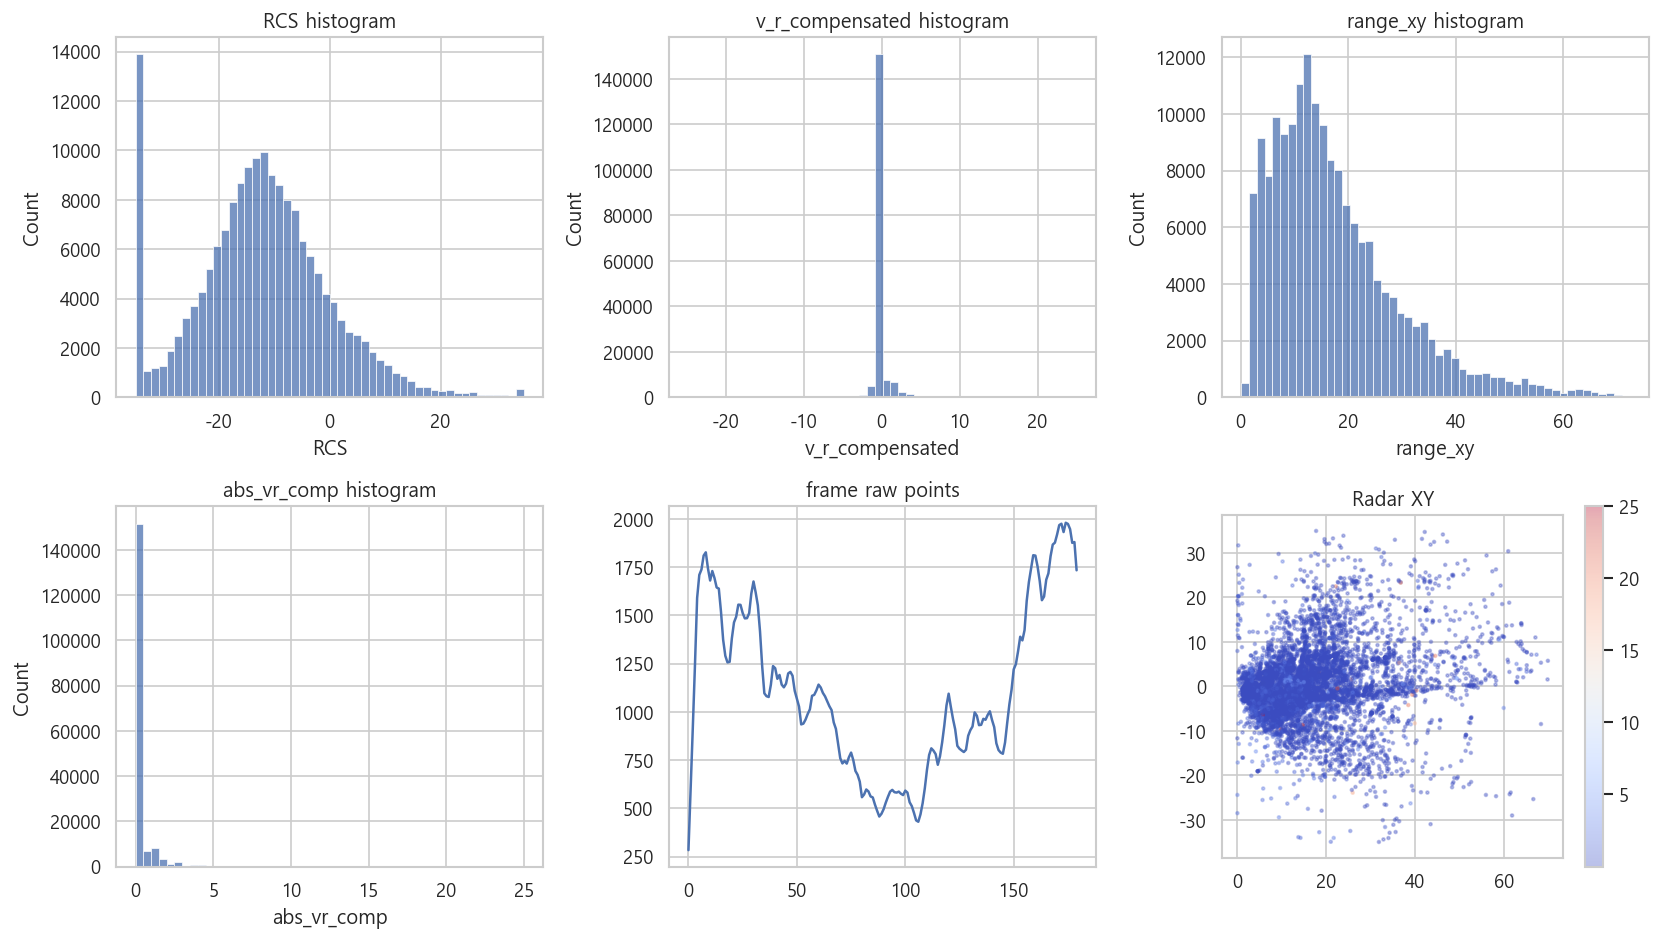

[핵심 해석] Raw 포인트 분포에서 고정 반사/저속 점 비중이 높다.
[다음 단계 연결] 전처리에서 ROI·클리핑으로 안정성을 확보한다.


In [6]:
# Section 2 발표용 추가 시각화
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
sns.histplot(radar_df['RCS'], bins=50, ax=axes[0]); axes[0].set_title('RCS histogram')
sns.histplot(radar_df['v_r_compensated'], bins=50, ax=axes[1]); axes[1].set_title('v_r_compensated histogram')
sns.histplot(radar_df['range_xy'], bins=50, ax=axes[2]); axes[2].set_title('range_xy histogram')
sns.histplot(radar_df['abs_vr_comp'], bins=50, ax=axes[3]); axes[3].set_title('abs_vr_comp histogram')
fc = frame_summary.groupby('frame_order')['raw_points'].sum(); axes[4].plot(fc.index, fc.values); axes[4].set_title('frame raw points')
s = radar_df.sample(min(8000, len(radar_df)), random_state=SEED)
sc = axes[5].scatter(s['x'], s['y'], c=s['abs_vr_comp'], s=3, alpha=0.35, cmap='coolwarm'); axes[5].set_aspect('equal'); axes[5].set_title('Radar XY')
plt.colorbar(sc, ax=axes[5]); plt.tight_layout()
save_fig('fig_raw_radar_eda_overview')
save_fig_pair('fig_raw_radar_eda_overview')
plt.show()
section_interp('Raw 포인트 분포에서 고정 반사/저속 점 비중이 높다.', '전처리에서 ROI·클리핑으로 안정성을 확보한다.')


## Section 3. 전처리

ROI 밖 제거, RCS/속도 클립, 프레임당 포인트 상한으로 연산량과 극단값을 제한한다.


[timed] section3_preprocess: 0.008s


,metric,value
0,n_raw_total,199319.000000
1,n_clean_total,175703.000000
2,keep_ratio_global,0.881517
3,keep_ratio_mean_frame,0.904775


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec03_keep_ratio_single_ipynb.png


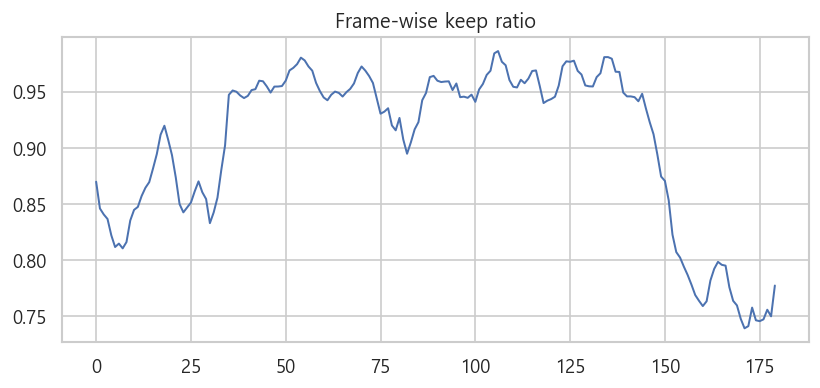

[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec03_preprocess_summary_single_ipynb.csv
[HR 해석] keep ratio는 다음 클러스터링 입력의 밀도를 결정한다.


In [7]:
with timed("section3_preprocess"):
    radar_df_clean = radar_df.copy()
    preproc_summary_df = pd.DataFrame(
        [
            {"metric": "n_raw_total", "value": int(frame_summary["raw_points"].sum())},
            {"metric": "n_clean_total", "value": int(len(radar_df_clean))},
            {"metric": "keep_ratio_global", "value": float(len(radar_df_clean) / max(frame_summary["raw_points"].sum(), 1))},
            {"metric": "keep_ratio_mean_frame", "value": float(frame_summary["kept_ratio"].mean())},
        ]
    )
ipy_display(preproc_summary_df)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(frame_summary["frame_order"], frame_summary["kept_ratio"], lw=1.2)
ax.set_title("Frame-wise keep ratio")
plt.tight_layout()
save_fig("sec03_keep_ratio")
plt.show()
save_table(preproc_summary_df, "sec03_preprocess_summary")
print("[HR 해석] keep ratio는 다음 클러스터링 입력의 밀도를 결정한다.")


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_pre_vs_post_scatter_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_pre_vs_post_scatter_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_pre_vs_post_scatter_presentation_single_ipynb.png


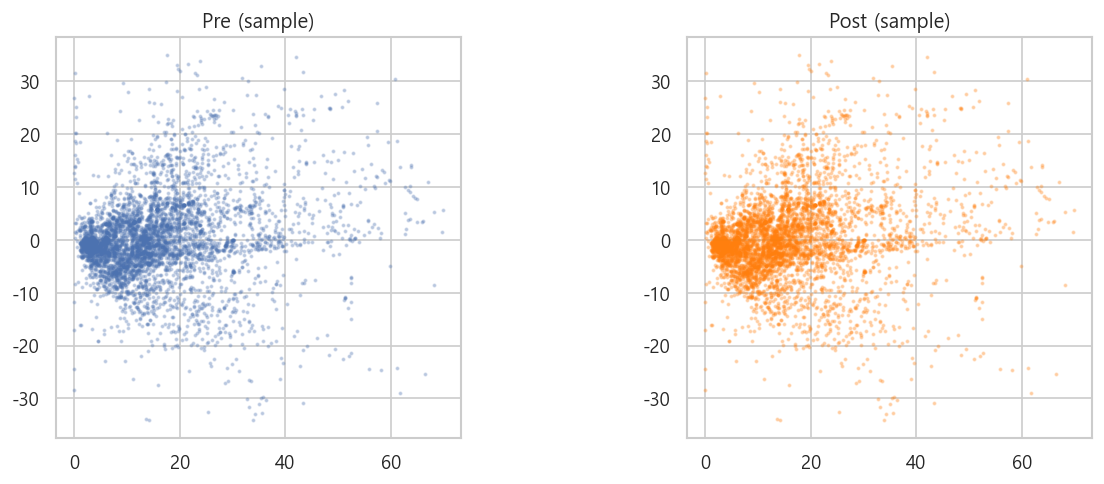

[핵심 해석] 전처리 후 공간 분포는 유지하면서 극단/불필요 포인트를 제한했다.
[다음 단계 연결] 클러스터링 입력 신호대잡음을 개선한다.


In [8]:
# Section 3 추가 시각화 (pre vs post)
pre = radar_df.sample(min(5000, len(radar_df)), random_state=SEED)
post = radar_df_clean.sample(min(5000, len(radar_df_clean)), random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(pre['x'], pre['y'], s=2, alpha=0.25); axes[0].set_title('Pre (sample)'); axes[0].set_aspect('equal')
axes[1].scatter(post['x'], post['y'], s=2, alpha=0.25, color='tab:orange'); axes[1].set_title('Post (sample)'); axes[1].set_aspect('equal')
plt.tight_layout()
save_fig('fig_pre_vs_post_scatter')
save_fig_pair('fig_pre_vs_post_scatter')
plt.show()
section_interp('전처리 후 공간 분포는 유지하면서 극단/불필요 포인트를 제한했다.', '클러스터링 입력 신호대잡음을 개선한다.')


## Section 4. 후보 생성 (DBSCAN / HDBSCAN)

밀도 기반 클러스터로 공간적 응집 후보를 만든다.


In [9]:
with timed("section4_cluster"):
    methods = ["dbscan"] + (["hdbscan"] if OPT["hdbscan"] else [])
    cluster_df_all, cluster_quality = s3.build_cluster_tables(radar_df_clean, methods)
    rows = []
    for alg in sorted(cluster_df_all["algorithm"].unique()):
        sub = cluster_df_all[cluster_df_all["algorithm"] == alg]
        fq = cluster_quality[cluster_quality["algorithm"] == alg]
        rows.append(
            {
                "algorithm": alg,
                "cluster_count": int(len(sub)),
                "noise_ratio": float(fq["noise_ratio"].mean()) if not fq.empty else np.nan,
                "mean_trackable_size_proxy": float(sub["n_points"].mean()),
                "mean_spread_xy": float(sub["spread_xy"].mean()),
                "mean_clusters_per_frame": float(fq["n_clusters"].mean()) if not fq.empty else np.nan,
            }
        )
    cluster_algo_summary = pd.DataFrame(rows)
    cluster_algo_summary["quality_score"] = (
        -cluster_algo_summary["noise_ratio"].fillna(1.0)
        + 0.04 * cluster_algo_summary["mean_clusters_per_frame"].fillna(0).clip(0, 30)
        - 0.001 * cluster_algo_summary["mean_spread_xy"].fillna(0)
    )
    cluster_algo_summary = cluster_algo_summary.sort_values("quality_score", ascending=False).reset_index(drop=True)
    selected_cluster_algo = str(cluster_algo_summary.iloc[0]["algorithm"])
    cluster_df_raw = cluster_df_all[cluster_df_all["algorithm"] == selected_cluster_algo].copy().reset_index(drop=True)

ipy_display(cluster_algo_summary)
save_table(cluster_algo_summary, "sec04_cluster_algo_summary")
print("selected_cluster_algo =", selected_cluster_algo)
ipy_display(cluster_df_raw.head())
print("[HR 해석] 품질 점수 상위 알고리즘을 채택해 이후 단계의 입력을 고정한다.")


[timed] section4_cluster: 13.696s


,algorithm,cluster_count,noise_ratio,mean_trackable_size_proxy,mean_spread_xy,mean_clusters_per_frame,quality_score
0,hdbscan,7561,0.224032,18.046951,0.741456,42.005556,0.975227
1,dbscan,2107,0.062720,78.592311,2.130424,11.705556,0.403371


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec04_cluster_algo_summary_single_ipynb.csv
selected_cluster_algo = hdbscan


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,spread_xy,density_proxy,mean_rcs,rcs_std,mean_vr_comp,abs_vr_comp,vr_comp_std,z_std,time_mean
0,hdbscan,00000,0,0,hdbscan:00000:0,24,16.723734,-0.831550,1.150745,16.744394,3.772177,6.360688,-18.806913,4.500692,2.889690,2.889690,0.064849,1.453561,0.0
1,hdbscan,00000,0,1,hdbscan:00000:1,55,9.496860,-1.347430,-0.244307,9.591971,3.758439,14.629844,-14.177753,9.294411,1.510404,1.510404,0.163607,0.588353,0.0
2,hdbscan,00000,0,2,hdbscan:00000:2,39,15.058232,4.475281,-0.498472,15.709186,4.385626,8.890660,-9.939492,5.581155,-0.002348,0.024633,0.052935,1.163432,0.0
3,hdbscan,00000,0,3,hdbscan:00000:3,20,19.456871,14.164801,-0.908483,24.066811,4.539105,4.405184,-0.692822,6.937578,0.027917,0.059590,0.141815,0.799502,0.0
4,hdbscan,00000,0,4,hdbscan:00000:4,18,6.429248,-4.118162,-0.027550,7.635083,2.822962,6.374024,-15.506688,10.994450,0.005667,0.011893,0.029645,0.605183,0.0


[HR 해석] 품질 점수 상위 알고리즘을 채택해 이후 단계의 입력을 고정한다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_cluster_algo_compare_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_cluster_algo_compare_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_cluster_algo_compare_presentation_single_ipynb.png


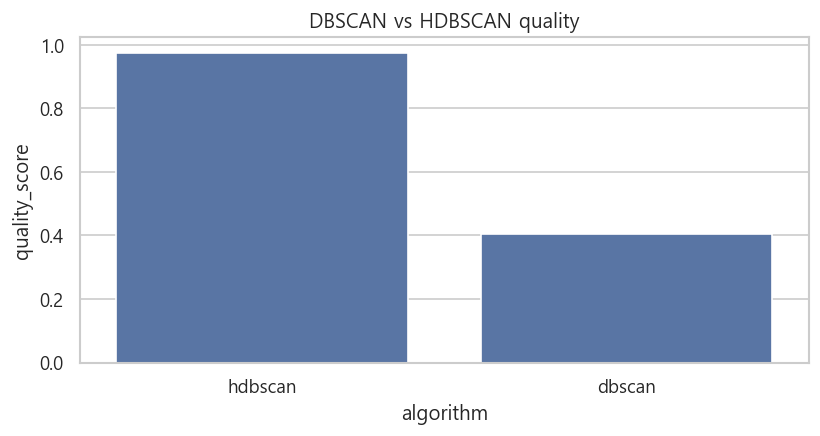

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_target_candidate_generation_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_cluster_candidates_xy_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_cluster_candidates_xy_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_cluster_candidates_xy_presentation_single_ipynb.png


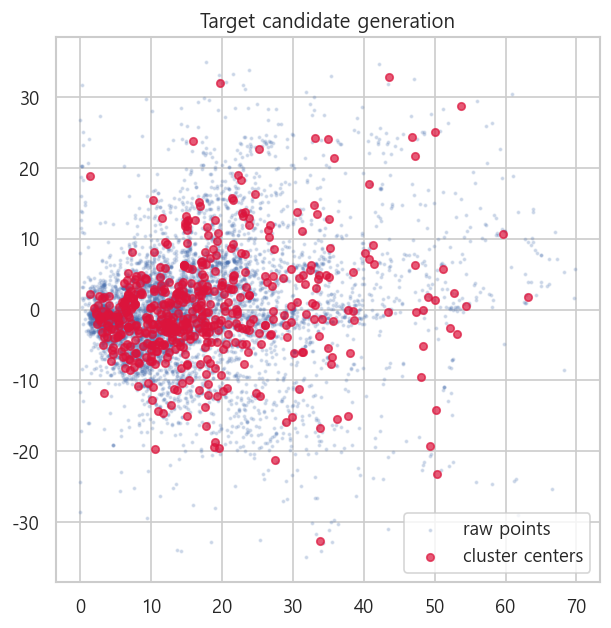

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_raw_vs_candidate_clusters_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_raw_vs_candidate_clusters_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_raw_vs_candidate_clusters_presentation_single_ipynb.png


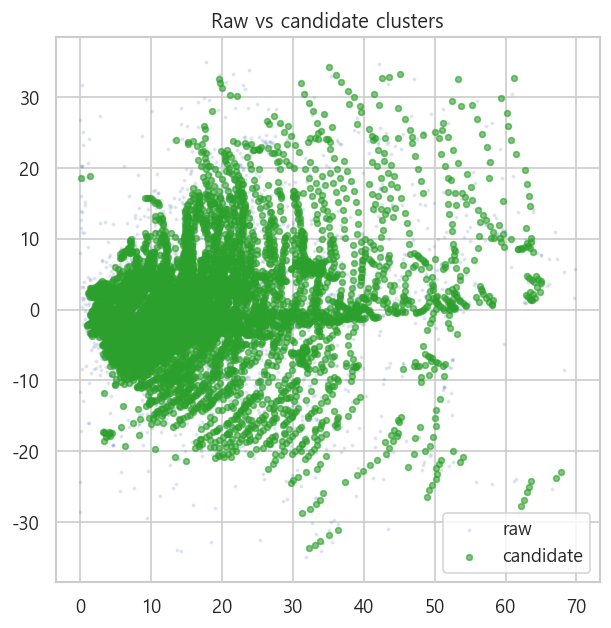

[핵심 해석] hdbscan가 품질 점수 기준 선택되었다.
[다음 단계 연결] 억제 단계에서 후보 폭발을 제어한다.


In [10]:
# Section 4 발표용 시각화
fig, ax = plt.subplots(figsize=(7,3.8))
sns.barplot(data=cluster_algo_summary, x='algorithm', y='quality_score', ax=ax)
ax.set_title('DBSCAN vs HDBSCAN quality'); plt.tight_layout()
save_fig('fig_cluster_algo_compare'); save_fig_pair('fig_cluster_algo_compare'); plt.show()

s_raw = radar_df_clean.sample(min(7000, len(radar_df_clean)), random_state=SEED)
cc = cluster_df_raw.sample(min(500, len(cluster_df_raw)), random_state=SEED)
fig, ax = plt.subplots(figsize=(6.3,5.4))
ax.scatter(s_raw['x'], s_raw['y'], s=2, alpha=0.18, label='raw points')
ax.scatter(cc['cx'], cc['cy'], s=20, alpha=0.7, label='cluster centers', color='crimson')
ax.set_aspect('equal'); ax.legend(); ax.set_title('Target candidate generation')
plt.tight_layout()
save_fig('fig_target_candidate_generation'); save_fig('fig_cluster_candidates_xy'); save_fig_pair('fig_cluster_candidates_xy'); plt.show()

fig, ax = plt.subplots(figsize=(6.3,5.4))
ax.scatter(s_raw['x'], s_raw['y'], s=2, alpha=0.12, label='raw')
ax.scatter(cluster_df_raw['cx'], cluster_df_raw['cy'], s=12, alpha=0.6, label='candidate', color='tab:green')
ax.set_aspect('equal'); ax.legend(); ax.set_title('Raw vs candidate clusters')
plt.tight_layout(); save_fig('fig_raw_vs_candidate_clusters'); save_fig_pair('fig_raw_vs_candidate_clusters'); plt.show()
section_interp(f"{selected_cluster_algo}가 품질 점수 기준 선택되었다.", '억제 단계에서 후보 폭발을 제어한다.')


## Section 5. 후보 억제

S1 기하, S2 그리드/속도, S3 유틸리티 게이트로 후보 수를 줄인다.


In [11]:
with timed("section5_suppress"):
    sup_full, sum_full = e2e.suppress_candidates(cluster_df_raw, mode="full")
    sup_ops, sum_ops = e2e.suppress_candidates(cluster_df_raw, mode="ops")
    suppressed_by_mode = {"full": sup_full, "ops": sup_ops}
    suppression_by_mode = {"full": sum_full, "ops": sum_ops}
    target_keep = {"ops_t20": 0.62, "ops_t18": 0.54, "ops_t15": 0.46}
    for m, frac in target_keep.items():
        d = s3.gate_top_fraction(sup_ops.copy(), keep_fraction=frac)
        if "proposal_quality_score" in d.columns:
            d = d[d["proposal_quality_score"] >= d["proposal_quality_score"].quantile(0.15)].copy()
        suppressed_by_mode[m] = d.reset_index(drop=True)
        suppression_by_mode[m] = pd.DataFrame(
            [
                {"stage": "raw_ops_base", "n_candidates": int(len(sup_ops)), "remove_ratio": 0.0, "mode": m},
                {"stage": f"extra_gate_{frac:.2f}", "n_candidates": int(len(d)), "remove_ratio": float(1 - len(d) / max(len(sup_ops), 1)), "mode": m},
            ]
        )
    suppression_summary_df = pd.concat(list(suppression_by_mode.values()), ignore_index=True)

ipy_display(suppression_summary_df.head(24))
save_table(suppression_summary_df, "sec05_suppression_summary")
frame_n = max(frame_summary["frame_id"].nunique(), 1)
burden_df = pd.DataFrame(
    [{"mode": m, "n_after": int(len(dfm)), "per_frame": float(len(dfm)) / frame_n} for m, dfm in suppressed_by_mode.items()]
).sort_values("per_frame")
ipy_display(burden_df)
save_table(burden_df, "sec05_burden_by_mode")
desc_sup, raw_h, sup_h = cluster_level_tables(cluster_df_raw, suppressed_by_mode["ops"], save_fig_fn=save_fig)
ipy_display(raw_h)
ipy_display(sup_h)
ipy_display(desc_sup)
print("[HR 해석] full은 연구용 보존, ops 계열은 운영 부담을 줄이는 방향이다.")


[timed] section5_suppress: 0.541s


,stage,n_candidates,remove_ratio,mode,topk_useful_keep_proxy
0,raw,7561,0.000000,full,0.00
1,S1_geometric,7561,0.000000,full,0.00
2,S2_temporal,7185,0.049729,full,0.00
3,S3_utility,6088,0.194816,full,0.00
4,raw,7561,0.000000,ops,0.02
5,S1_geometric,7561,0.000000,ops,0.02
6,S2_temporal,6629,0.123264,ops,0.02
7,S3_utility,4497,0.405237,ops,0.02
8,raw_ops_base,4497,0.000000,ops_t20,NaN
9,extra_gate_0.62,2370,0.472982,ops_t20,NaN


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec05_suppression_summary_single_ipynb.csv


,mode,n_after,per_frame
4,ops_t15,1758,9.766667
3,ops_t18,2064,11.466667
2,ops_t20,2370,13.166667
1,ops,4497,24.983333
0,full,6088,33.822222


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec05_burden_by_mode_single_ipynb.csv
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec05_cluster_quality_hist_single_ipynb.png


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,spread_xy,density_proxy,mean_rcs,rcs_std,mean_vr_comp,abs_vr_comp,vr_comp_std,z_std,time_mean
0,hdbscan,00000,0,0,hdbscan:00000:0,24,16.723734,-0.831550,1.150745,16.744394,3.772177,6.360688,-18.806913,4.500692,2.889690,2.889690,0.064849,1.453561,0.0
1,hdbscan,00000,0,1,hdbscan:00000:1,55,9.496860,-1.347430,-0.244307,9.591971,3.758439,14.629844,-14.177753,9.294411,1.510404,1.510404,0.163607,0.588353,0.0
2,hdbscan,00000,0,2,hdbscan:00000:2,39,15.058232,4.475281,-0.498472,15.709186,4.385626,8.890660,-9.939492,5.581155,-0.002348,0.024633,0.052935,1.163432,0.0
3,hdbscan,00000,0,3,hdbscan:00000:3,20,19.456871,14.164801,-0.908483,24.066811,4.539105,4.405184,-0.692822,6.937578,0.027917,0.059590,0.141815,0.799502,0.0
4,hdbscan,00000,0,4,hdbscan:00000:4,18,6.429248,-4.118162,-0.027550,7.635083,2.822962,6.374024,-15.506688,10.994450,0.005667,0.011893,0.029645,0.605183,0.0
5,hdbscan,00000,0,5,hdbscan:00000:5,19,29.275503,-12.447252,0.979113,31.811777,3.858086,4.923445,-1.417117,7.479192,-0.007359,0.009745,0.025614,1.742960,0.0
6,hdbscan,00000,0,6,hdbscan:00000:6,18,15.928190,-9.350979,-0.017205,18.470194,2.296128,7.835873,-3.115187,7.002433,-0.000879,0.002822,0.003501,1.068117,0.0
7,hdbscan,00001,1,0,hdbscan:00001:0,10,27.221777,2.605800,2.235157,27.346212,3.143944,3.179707,-19.246782,3.417619,2.807154,2.807154,0.057069,1.872108,-0.3


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,mean_rcs,rcs_std,mean_vr_comp,abs_vr_comp,vr_comp_std,z_std,time_mean,grid_count,proposal_quality_score,proposal_keep_flag
0,hdbscan,00001,1,3,hdbscan:00001:3,12,16.554157,-2.471586,1.079235,16.737648,...,-19.764748,3.086903,2.930000,2.930000,0.054726,1.654356,-0.666667,26,0.602563,1
1,hdbscan,00001,1,4,hdbscan:00001:4,20,14.337863,-0.270776,0.356462,14.340420,...,-20.625965,6.121262,2.925720,2.925720,0.028142,0.714524,-0.350000,27,0.645770,1
2,hdbscan,00002,2,2,hdbscan:00002:2,17,16.680450,-2.588163,0.981298,16.880049,...,-19.626081,3.012412,2.934572,2.934572,0.061582,1.804753,-1.294118,14,0.625286,1
3,hdbscan,00002,2,3,hdbscan:00002:3,10,15.440730,-0.266837,0.079750,15.443035,...,-21.699203,3.649882,2.928916,2.928916,0.018674,0.754895,-0.800000,8,0.639578,1
4,hdbscan,00002,2,4,hdbscan:00002:4,22,13.956811,-0.501093,0.451678,13.965803,...,-20.449224,6.787945,2.934850,2.934850,0.034915,0.663159,-0.863636,25,0.663115,1
5,hdbscan,00002,2,5,hdbscan:00002:5,13,30.398338,-10.043882,-1.710209,32.014660,...,-11.572770,3.039805,-0.849708,0.849708,0.105203,0.745917,-0.923077,2,0.620992,1
6,hdbscan,00002,2,7,hdbscan:00002:7,10,11.474182,-2.489938,-0.008923,11.741237,...,-19.617413,5.411063,1.828978,1.828978,0.062713,0.228481,-0.900000,28,0.616564,1
7,hdbscan,00002,2,11,hdbscan:00002:11,17,5.994259,-0.938920,-0.091296,6.067348,...,-5.014764,8.930916,1.511395,1.511395,0.012196,0.175518,-1.176471,27,0.653171,1


,count,mean,std,min,10%,50%,90%,max
n_points,4497.0,20.487214,21.100049,8.000000,9.000000,15.000000,33.000000,226.000000
spread_xy,4497.0,0.415250,0.389076,0.020110,0.090748,0.296922,0.878823,4.270748
mean_rcs,4497.0,-11.203279,9.087137,-35.000000,-22.268385,-11.192487,0.264247,14.993655
mean_vr_comp,4497.0,0.061924,0.516953,-1.997448,-0.011206,0.000931,0.008093,4.146639
vr_comp_std,4497.0,0.020918,0.047288,0.000270,0.003087,0.007391,0.040734,0.538954
density_proxy,4497.0,68.085148,51.033209,11.887269,29.168385,52.864331,123.275254,489.826448
proposal_quality_score,4497.0,0.671992,0.061439,0.595162,0.606371,0.655142,0.776651,0.864114


[HR 해석] full은 연구용 보존, ops 계열은 운영 부담을 줄이는 방향이다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_suppression_funnel_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_suppression_funnel_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_suppression_funnel_presentation_single_ipynb.png


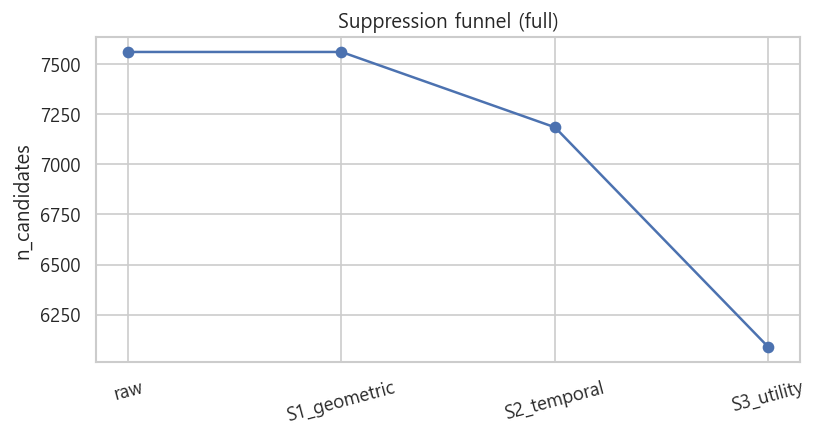

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_mode_burden_compare_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_mode_burden_compare_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_mode_burden_compare_presentation_single_ipynb.png


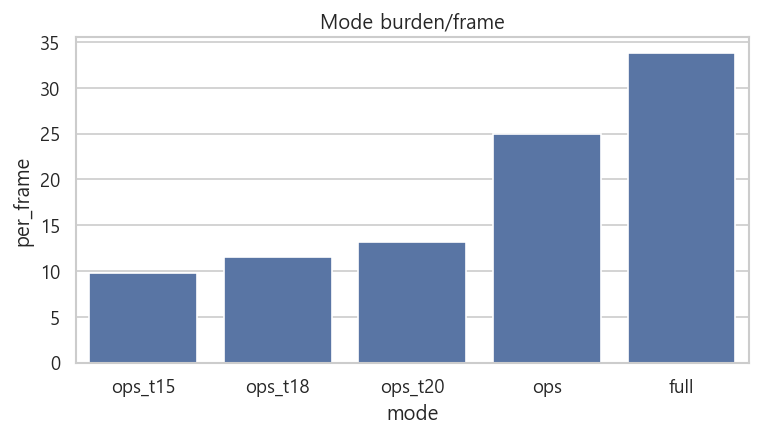

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_raw_vs_suppressed_xy_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_raw_vs_suppressed_xy_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_raw_vs_suppressed_xy_presentation_single_ipynb.png


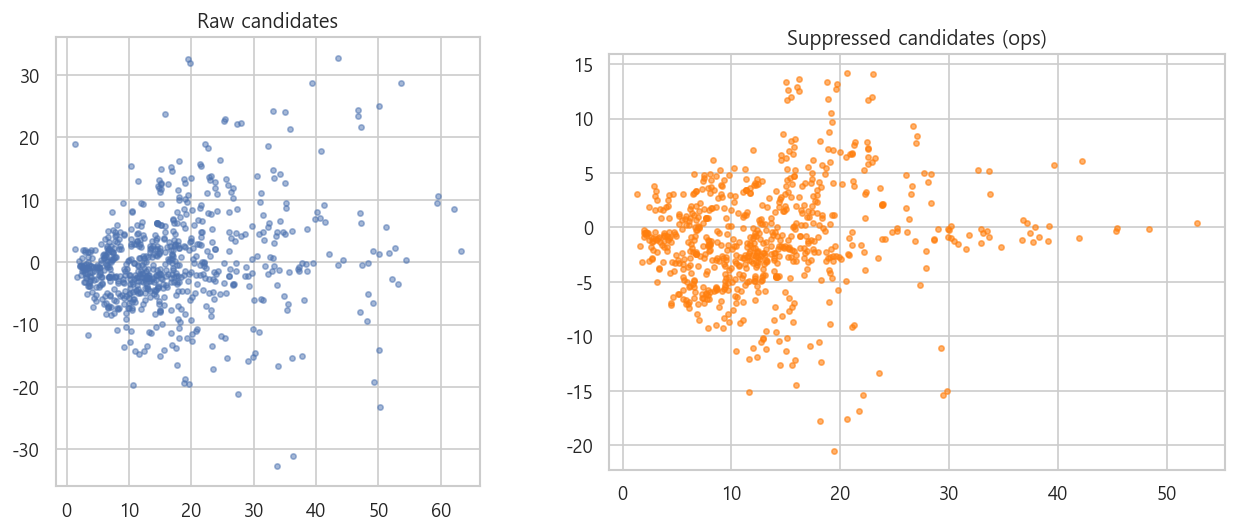

[핵심 해석] S2/S3 단계가 운영 burden 감소에 크게 기여한다.
[다음 단계 연결] corroboration에서 후보 신뢰도를 보정한다.


In [12]:
# Section 5 발표용 시각화
funnel = suppression_summary_df[suppression_summary_df['mode'].isin(['full'])].copy()
fig, ax = plt.subplots(figsize=(7,3.8))
ax.plot(funnel['stage'], funnel['n_candidates'], marker='o'); ax.set_title('Suppression funnel (full)'); ax.set_ylabel('n_candidates')
plt.xticks(rotation=15); plt.tight_layout(); save_fig('fig_suppression_funnel'); save_fig_pair('fig_suppression_funnel'); plt.show()

fig, ax = plt.subplots(figsize=(6.5,3.8))
sns.barplot(data=burden_df.sort_values('per_frame'), x='mode', y='per_frame', ax=ax)
ax.set_title('Mode burden/frame'); plt.tight_layout(); save_fig('fig_mode_burden_compare'); save_fig_pair('fig_mode_burden_compare'); plt.show()

raws = cluster_df_raw.sample(min(700, len(cluster_df_raw)), random_state=SEED)
sups = suppressed_by_mode['ops'].sample(min(700, len(suppressed_by_mode['ops'])), random_state=SEED)
fig, axes = plt.subplots(1,2,figsize=(11,4.6))
axes[0].scatter(raws['cx'], raws['cy'], s=10, alpha=0.5); axes[0].set_title('Raw candidates'); axes[0].set_aspect('equal')
axes[1].scatter(sups['cx'], sups['cy'], s=10, alpha=0.6, color='tab:orange'); axes[1].set_title('Suppressed candidates (ops)'); axes[1].set_aspect('equal')
plt.tight_layout(); save_fig('fig_raw_vs_suppressed_xy'); save_fig_pair('fig_raw_vs_suppressed_xy'); plt.show()
section_interp('S2/S3 단계가 운영 burden 감소에 크게 기여한다.', 'corroboration에서 후보 신뢰도를 보정한다.')


## Section 6. LiDAR corroboration + 듀얼 파이프라인

`e2e.run_branch`가 LiDAR v3(내부적으로 v2 점수 유지) 트래킹·규칙·ML·hybrid까지 수행한다. v1(`lidar_corroboration_score`) vs v2(`lidar_corroboration_score_v2`)는 **같은 파이프 출력**에서 비교한다.


In [13]:
frame_by_id = {fr["frame_id"]: fr for fr in frames}
RESULTS = {}
with timed("section6_run_branch_all_modes"):
    for m in ["full", "ops", "ops_t20", "ops_t18", "ops_t15"]:
        RESULTS[m] = e2e.run_branch(
            suppressed_by_mode[m],
            suppression_by_mode[m],
            mode=m,
            frames=frames,
            frame_by_id=frame_by_id,
            roi=ROI,
            track_gate_dist=TRACK_GATE_DIST,
            seed=SEED,
            opt=OPT,
        )

for m, R in RESULTS.items():
    print(m, "n_suppressed", len(R.cluster_df_suppressed), "n_tracked_rows", len(R.cluster_df_tracked))

R0 = RESULTS["full"]
cdf = R0.cluster_df_corr
cols_v = [c for c in ["lidar_corroboration_score", "lidar_corroboration_score_v2"] if c in cdf.columns]
if len(cols_v) >= 2:
    subc = cdf[[cols_v[0], cols_v[1]]].dropna()
    rho = float(subc.corr(method="spearman").iloc[0, 1]) if len(subc) > 2 else float("nan")
    cmp_df = pd.DataFrame({"mean_v1": [float(cdf[cols_v[0]].mean())], "mean_v2": [float(cdf[cols_v[1]].mean())], "spearman_v1_v2": [rho]})
else:
    cmp_df = pd.DataFrame([{"note": "missing v1 or v2 columns"}])
ipy_display(cmp_df)
save_table(cmp_df, "sec06_lidar_v1_v2_compare")
ipy_display(R0.cluster_df_corr.head(8))
print("[HR 해석] LiDAR는 정답 라벨이 아니라 radar-only 착오를 줄이는 보조 검증 신호다.")


[timed] section6_run_branch_all_modes: 678.174s
full n_suppressed 6088 n_tracked_rows 6088
ops n_suppressed 4497 n_tracked_rows 4497
ops_t20 n_suppressed 2370 n_tracked_rows 2370
ops_t18 n_suppressed 2064 n_tracked_rows 2064
ops_t15 n_suppressed 1758 n_tracked_rows 1758


,mean_v1,mean_v2,spearman_v1_v2
0,0.531196,0.468721,0.658509


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec06_lidar_v1_v2_compare_single_ipynb.csv


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,lidar_corroboration_score,lidar_verified,lidar_mode,lidar_min_dist_center,lidar_min_dist_extent,lidar_density_center,lidar_density_extent,lidar_multi_nn_mean_dist,lidar_overlap_proxy,lidar_corroboration_score_v2
0,hdbscan,00000,0,0,hdbscan:00000:0,24,16.723734,-0.831550,1.150745,16.744394,...,0.386622,0,lidar,2.420059,0.094906,0.000043,0.059390,2.465838,0.121612,0.418959
1,hdbscan,00000,0,1,hdbscan:00000:1,55,9.496860,-1.347430,-0.244307,9.591971,...,0.590218,1,lidar,0.063608,0.000998,0.079424,0.341347,0.066279,0.470073,0.604918
2,hdbscan,00001,1,1,hdbscan:00001:1,95,9.183059,-1.461491,-0.240686,9.298630,...,0.596986,1,lidar,0.039242,0.012480,0.085658,0.336906,0.043617,0.479803,0.607807
3,hdbscan,00001,1,2,hdbscan:00001:2,8,30.573341,-9.955719,-1.851060,32.153469,...,0.507559,1,lidar,0.624768,0.283028,0.001098,0.000086,0.650075,0.031621,0.443225
4,hdbscan,00001,1,3,hdbscan:00001:3,12,16.554157,-2.471586,1.079235,16.737648,...,0.477158,1,lidar,1.076080,0.464748,0.002066,0.000387,1.127876,0.035044,0.427734
5,hdbscan,00001,1,4,hdbscan:00001:4,20,14.337863,-0.270776,0.356462,14.340420,...,0.454204,1,lidar,1.413487,0.796937,0.000753,0.000258,1.455103,0.006716,0.405918
6,hdbscan,00001,1,10,hdbscan:00001:10,23,6.030051,-4.650162,-0.132717,7.614822,...,0.571250,1,lidar,0.182063,0.034659,0.056302,0.127410,0.205342,0.216489,0.521241
7,hdbscan,00002,2,1,hdbscan:00002:1,9,19.343611,-3.642620,1.131709,19.683596,...,0.499302,1,lidar,0.749811,0.318947,0.001731,0.000321,0.808632,0.074398,0.447780


[HR 해석] LiDAR는 정답 라벨이 아니라 radar-only 착오를 줄이는 보조 검증 신호다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_corroboration_compare_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_corroboration_compare_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_corroboration_compare_presentation_single_ipynb.png


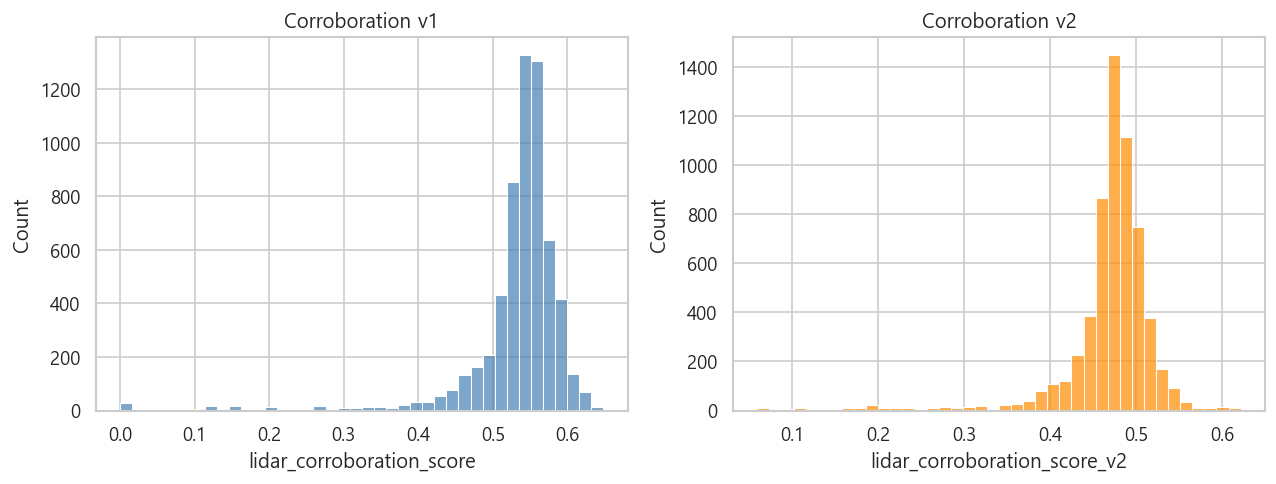

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_radar_lidar_overlay_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_radar_lidar_overlay_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_radar_lidar_overlay_presentation_single_ipynb.png


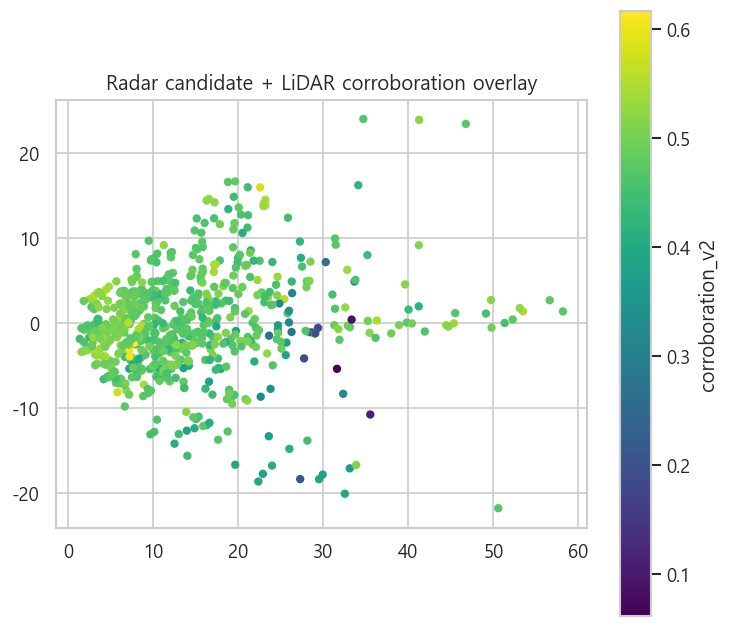

[핵심 해석] LiDAR corroboration은 보조 검증 신호이며 레이더 단독 오류를 줄인다.
[다음 단계 연결] 트래킹으로 시간 연속성을 추가한다.


In [14]:
# Section 6 발표용 시각화
Rfull = RESULTS['full']
cdf = Rfull.cluster_df_corr.copy()
if {'lidar_corroboration_score','lidar_corroboration_score_v2'}.issubset(cdf.columns):
    fig, axes = plt.subplots(1,2,figsize=(10.8,4.2))
    sns.histplot(cdf['lidar_corroboration_score'], bins=40, ax=axes[0], color='steelblue', alpha=0.7)
    axes[0].set_title('Corroboration v1')
    sns.histplot(cdf['lidar_corroboration_score_v2'], bins=40, ax=axes[1], color='darkorange', alpha=0.7)
    axes[1].set_title('Corroboration v2')
    plt.tight_layout(); save_fig('fig_corroboration_compare'); save_fig_pair('fig_corroboration_compare'); plt.show()

overlay = cdf.sample(min(700, len(cdf)), random_state=SEED)
fig, ax = plt.subplots(figsize=(6.3,5.4))
cm = ax.scatter(overlay['cx'], overlay['cy'], c=overlay['lidar_corroboration_score_v2'], s=16, cmap='viridis')
ax.set_title('Radar candidate + LiDAR corroboration overlay'); ax.set_aspect('equal')
plt.colorbar(cm, ax=ax, label='corroboration_v2')
plt.tight_layout(); save_fig('fig_radar_lidar_overlay'); save_fig_pair('fig_radar_lidar_overlay'); plt.show()
section_interp('LiDAR corroboration은 보조 검증 신호이며 레이더 단독 오류를 줄인다.', '트래킹으로 시간 연속성을 추가한다.')


## Section 7. Tracking

baseline vs improved 요약과 temporal 분포.


In [15]:
TRACK_DIAG: dict[str, dict[str, Any]] = {}

for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.tracking_summary_df.assign(mode=m))
    save_table(R.tracking_summary_df.assign(mode=m), f"sec07_tracking_{m}")

    # row-level 검증은 track_obs_selected가 아닌 cluster_df_tracked 기반으로 수행
    td = R.cluster_df_tracked.copy()
    td = td.sort_values(["track_id", "frame_order"]).reset_index(drop=True)

    # track_len 진단: transform('size')로 재계산한 true length
    td["track_len_true"] = td.groupby("track_id")["track_id"].transform("size")
    if "track_len" not in td.columns:
        td["track_len"] = td["track_len_true"]

    # track_len이 기본값 1로 고정된 경우를 완화: true length로 보정
    ratio_len1 = float((td["track_len"] <= 1).mean()) if len(td) else 1.0
    if ratio_len1 > 0.95 and float((td["track_len_true"] > 1).mean()) > 0.05:
        td["track_len"] = td["track_len_true"]

    # temporal feature는 cluster_df_tracked 기준으로 통계 (row-level merge 불일치 회피)
    temporal_cols = [
        c
        for c in [
            "approach_score",
            "temporal_stability_score",
            "heading_consistency_score",
            "closing_consistency_score",
            "motion_smoothness_score",
        ]
        if c in td.columns
    ]

    nz_rows = []
    for c in temporal_cols:
        s = pd.to_numeric(td[c], errors="coerce").fillna(0.0)
        nz_rows.append({"feature": c, "nonzero_ratio": float((s.abs() > 1e-9).mean()), "mean": float(s.mean())})
    nz_df = pd.DataFrame(nz_rows)

    ipy_display(td[["frame_id", "frame_order", "track_id", "track_len", "track_len_true"] + temporal_cols].head(20))
    ipy_display(td[["track_len", "track_len_true"] + temporal_cols].describe())
    ipy_display(nz_df)

    save_table(td[["frame_id", "frame_order", "track_id", "track_len", "track_len_true"] + temporal_cols], f"sec07_track_rows_{m}")
    save_table(nz_df, f"sec07_temporal_nonzero_{m}")

    # track-level EDA 시각화도 cluster_df_tracked 기준
    ipy_display(track_level_eda(td, save_fig_fn=lambda n, mm=m: save_fig(f"{n}_{mm}")))
    trep = temporal_feature_distribution_report(td)
    ipy_display(trep)
    save_table(trep, f"sec07_temporal_stats_{m}")

    TRACK_DIAG[m] = {
        "track_rows": td,
        "temporal_nonzero": nz_df,
    }

print("[HR 해석] Section 7에서 row-level track_len/temporal 값을 cluster_df_tracked 기준으로 재검증했다.")
print("[HR 다음 단계] Section 7A/7B에서 integrity와 temporal sanity를 정량 점검한다.")


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio
0,full,528,11.530303,0.176136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,full,470,12.953191,0.114894,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec07_tracking_full_single_ipynb.csv
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec07_track_temporal_dists_full_single_ipynb.png


,count,mean,std,min,10%,50%,90%,max
track_len,6088.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
approach_score,6088.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,feature,mean,std,median,p90,nonzero_ratio
0,approach_score,0.0,0.0,0.0,0.0,0.0
1,temporal_stability_score,0.0,0.0,0.0,0.0,0.0


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec07_temporal_stats_full_single_ipynb.csv


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio
0,ops,435,10.337931,0.211494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ops,355,12.667606,0.098592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec07_tracking_ops_single_ipynb.csv
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec07_track_temporal_dists_ops_single_ipynb.png


,count,mean,std,min,10%,50%,90%,max
track_len,4497.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
approach_score,4497.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,feature,mean,std,median,p90,nonzero_ratio
0,approach_score,0.0,0.0,0.0,0.0,0.0
1,temporal_stability_score,0.0,0.0,0.0,0.0,0.0


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec07_temporal_stats_ops_single_ipynb.csv
[HR 해석] fragmentation이 낮고 track_len이 길수록 temporal 신호가 안정적이다.


## Section 7A. Tracking integrity check

트랙 연결이 실제로 다프레임에서 유지되는지, `track_len`이 기본값으로 고정된 것이 아닌지, baseline/improved 및 gate 완화/강화에 따라 결과가 어떻게 바뀌는지 검증한다.

In [ ]:
integrity_rows = []
for m in ("full", "ops"):
    td = TRACK_DIAG[m]["track_rows"].copy()
    ipy_display(td[["frame_id", "frame_order", "track_id"]].head(20))
    ipy_display(td.groupby("track_id").size().describe())
    ipy_display(td["track_len_true"].value_counts().head(10))

    n_unique_tracks = int(td["track_id"].nunique())
    n_rows_with_track_len_gt_1 = int((td["track_len_true"] > 1).sum())
    track_len_nontrivial_ratio = float((td["track_len_true"] > 1).mean())

    # gate 민감도 비교 (strict/default/relaxed)
    corr = RESULTS[m].cluster_df_corr.copy()
    gate_cfg = [
        ("strict", TRACK_GATE_DIST * 0.8, 1),
        ("default", TRACK_GATE_DIST, 2),
        ("relaxed", TRACK_GATE_DIST * 1.25, 3),
    ]
    gate_rows = []
    for tag, gd, mm in gate_cfg:
        obs = s3.run_tracking(corr, mode="improved", gate_dist=float(gd), max_miss=int(mm))
        if len(obs):
            tl = obs.groupby("track_id").size()
            gate_rows.append(
                {
                    "mode": m,
                    "gate_setting": tag,
                    "gate_dist": float(gd),
                    "max_miss": int(mm),
                    "n_tracks": int(obs["track_id"].nunique()),
                    "mean_track_len": float(tl.mean()),
                    "nontrivial_track_ratio": float((tl > 1).mean()),
                    "single_track_ratio": float((tl == 1).mean()),
                }
            )
    gate_df = pd.DataFrame(gate_rows)
    ipy_display(gate_df)
    save_table(gate_df, f"sec07A_gate_sweep_{m}")

    integrity_rows.append(
        {
            "mode": m,
            "n_unique_tracks": n_unique_tracks,
            "n_rows_with_track_len_gt_1": n_rows_with_track_len_gt_1,
            "track_len_nontrivial_ratio": track_len_nontrivial_ratio,
            "single_frame_row_ratio": float((td["track_len_true"] <= 1).mean()),
        }
    )

tracking_integrity_df = pd.DataFrame(integrity_rows)
ipy_display(tracking_integrity_df)
save_table(tracking_integrity_df, "sec07A_tracking_integrity")
print("[핵심 해석] track_id 반복/다프레임 연결 여부를 수치로 검증했다.")
print("[다음 단계 연결] temporal feature가 진짜로 계산되는지 7B에서 sanity check를 수행한다.")

## Section 7B. Temporal feature sanity check

`approach_score`, `temporal_stability_score`, `heading_consistency_score`, `closing_consistency_score`, `motion_smoothness_score`가 전부 0으로 죽는지 확인하고, zero-only feature는 경고한다.

In [ ]:
temporal_sanity_rows = []
for m in ("full", "ops"):
    td = TRACK_DIAG[m]["track_rows"].copy()
    feat_list = [
        c
        for c in [
            "approach_score",
            "temporal_stability_score",
            "heading_consistency_score",
            "closing_consistency_score",
            "motion_smoothness_score",
        ]
        if c in td.columns
    ]

    for c in feat_list:
        s = pd.to_numeric(td[c], errors="coerce")
        print(f"[{m}] {c} describe")
        ipy_display(s.describe())
        nz = float((s.fillna(0).abs() > 1e-9).mean())
        temporal_sanity_rows.append({"mode": m, "feature": c, "nonzero_ratio": nz, "mean": float(s.mean())})
        if nz <= 1e-6:
            print(f"[WARNING] {m} {c} is zero-only (nonzero_ratio={nz:.6f})")


temporal_sanity_df = pd.DataFrame(temporal_sanity_rows)
ipy_display(temporal_sanity_df)
save_table(temporal_sanity_df, "sec07B_temporal_sanity")
print("[핵심 해석] temporal feature가 '진짜 약한지'와 '계산이 죽었는지'를 구분할 근거를 만들었다.")
print("[다음 단계 연결] Section 18 temporal effectiveness에서 weighting sweep/rank shift 해석에 사용한다.")

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_tracking_compare_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_tracking_baseline_vs_improved_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_tracking_compare_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_tracking_compare_presentation_single_ipynb.png


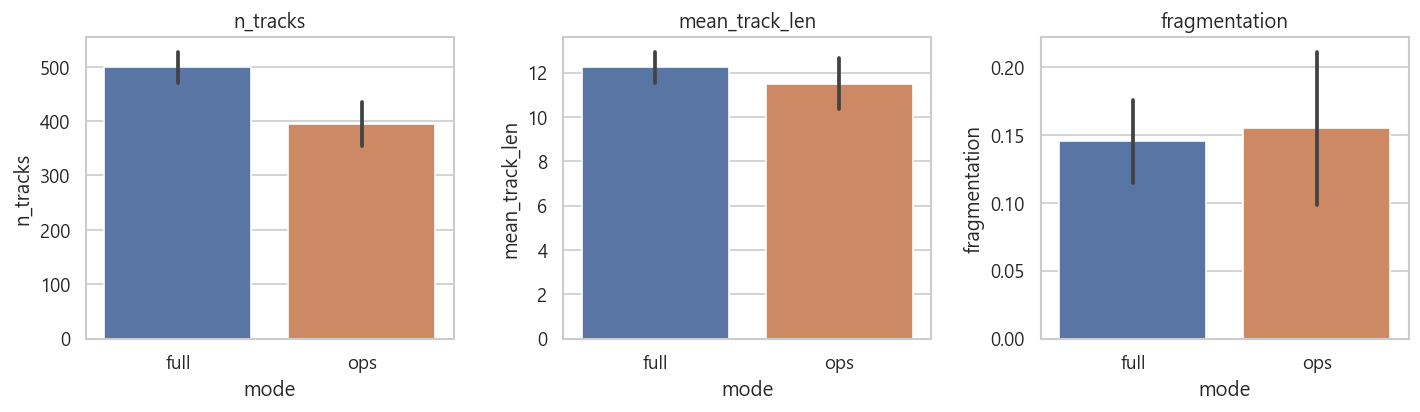

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_track_length_dist_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_track_length_dist_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_track_length_dist_presentation_single_ipynb.png


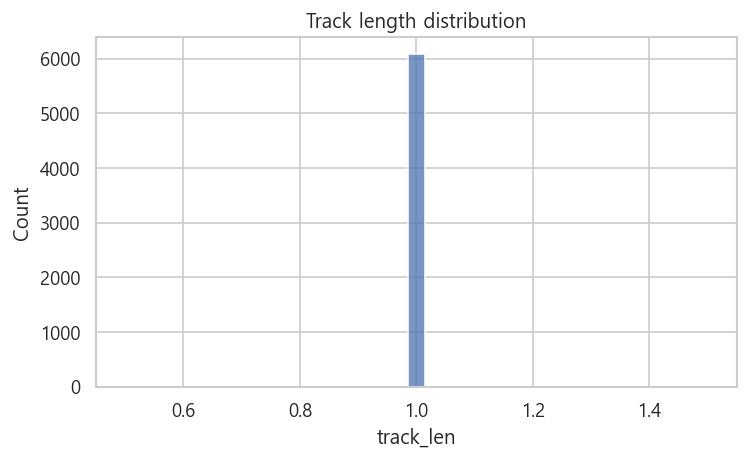

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_tracking_direction_estimation_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_track_trajectory_overlay_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_sample_tracks_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_tracking_direction_estimation_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_tracking_direction_estimation_presentation_single_ipynb.png


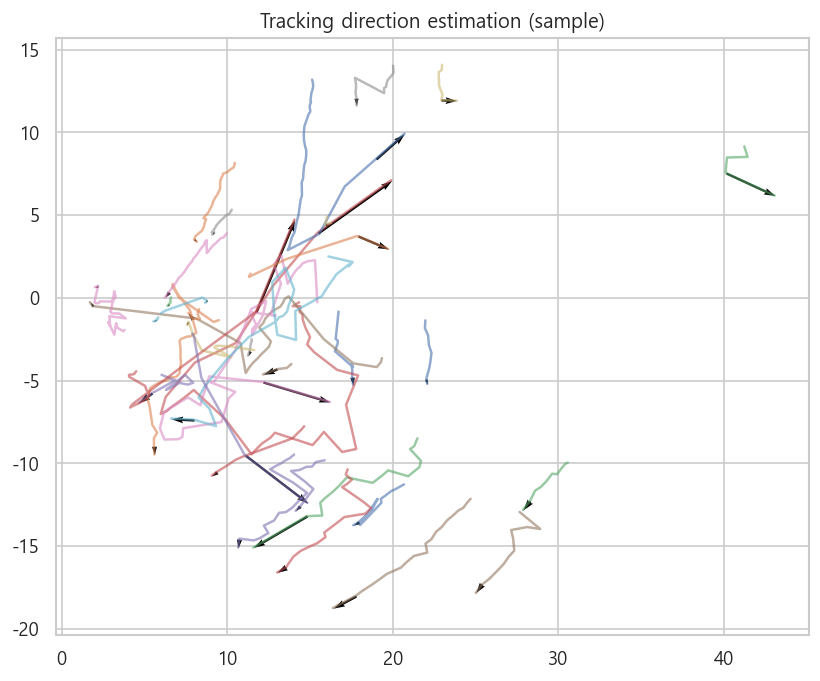

[핵심 해석] improved tracking은 fragmentation 감소와 길이 증가를 목표로 한다.
[다음 단계 연결] 규칙 위험점수에서 temporal feature가 반영된다.


In [16]:
# Section 7 발표용 시각화
rows=[]
for m in ('full','ops'):
    ts=RESULTS[m].tracking_summary_df.copy(); ts['mode']=m; rows.append(ts)
trk_cmp=pd.concat(rows,ignore_index=True)
metrics=['n_tracks','mean_track_len','fragmentation']
fig, axes = plt.subplots(1,3,figsize=(12,3.6))
for ax,met in zip(axes,metrics):
    sns.barplot(data=trk_cmp, x='mode', y=met, hue='mode', ax=ax, legend=False)
    ax.set_title(met)
plt.tight_layout(); save_fig('fig_tracking_compare'); save_fig('fig_tracking_baseline_vs_improved'); save_fig_pair('fig_tracking_compare'); plt.show()

obs = TRACK_DIAG['full']['track_rows'].copy() if 'TRACK_DIAG' in globals() else RESULTS['full'].cluster_df_tracked.copy()
if len(obs):
    fig, ax = plt.subplots(figsize=(6.4,4))
    sns.histplot(obs['track_len_true'], bins=35, ax=ax)
    ax.set_title('Track length distribution (true)')
    plt.tight_layout(); save_fig('fig_track_length_dist'); save_fig_pair('fig_track_length_dist'); plt.show()

# sample trajectories + direction arrows (cluster_df_tracked has cx/cy)
traj = RESULTS['full'].cluster_df_tracked[['track_id', 'frame_order', 'cx', 'cy']].dropna().copy()
if len(traj):
    fig, ax = plt.subplots(figsize=(7,6))
    for tid, g in traj.groupby('track_id'):
        g = g.sort_values('frame_order')
        if len(g) < 2:
            continue
        if int(tid) > 35:
            break
        ax.plot(g['cx'], g['cy'], alpha=0.6)
        ax.quiver(
            g['cx'].iloc[-2], g['cy'].iloc[-2],
            g['cx'].iloc[-1] - g['cx'].iloc[-2],
            g['cy'].iloc[-1] - g['cy'].iloc[-2],
            angles='xy', scale_units='xy', scale=1, width=0.003, color='black'
        )
    ax.set_aspect('equal'); ax.set_title('Tracking direction estimation (sample)')
    plt.tight_layout(); save_fig('fig_tracking_direction_estimation'); save_fig('fig_track_trajectory_overlay'); save_fig('fig_sample_tracks'); save_fig_pair('fig_tracking_direction_estimation'); plt.show()
section_interp('improved tracking은 fragmentation 감소와 길이 증가를 목표로 한다.', '규칙 위험점수에서 temporal feature가 반영된다.')


## Section 8. Rule-based risk

rule v1/v2와 threshold sensitivity.


In [17]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.cluster_df_rule[["risk_score_rule_v1", "risk_score_rule_v2"]].describe())
    ipy_display(R.threshold_sensitivity_df.head(15))
    save_table(R.threshold_sensitivity_df.assign(mode=m), f"sec08_thresh_{m}")
    vc = R.cluster_df_rule["risk_label_rule_v2"].value_counts()
    print(m, "risk_label_rule_v2:\n", vc)
print("[HR 해석] high=0이면 ML/ranking 지표가 붕괴하므로 threshold sensitivity로 범위를 점검한다.")


,risk_score_rule_v1,risk_score_rule_v2
count,6088.000000,6088.000000
mean,0.169254,0.262134
std,0.054094,0.049000
min,0.002677,0.052536
25%,0.139882,0.238112
50%,0.174881,0.269055
75%,0.199670,0.295389
max,0.457842,0.429151


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,6071,17,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,5215,730,143,1.0,0.0,3.964491,0.562154
2,quantile_only_q0.92,4992,609,487,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,5114,608,366,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,5235,609,244,NaN,NaN,NaN,NaN


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec08_thresh_full_single_ipynb.csv
full risk_label_rule_v2:
 risk_label_rule_v2
low       5215
medium     730
high       143
Name: count, dtype: int64


,risk_score_rule_v1,risk_score_rule_v2
count,4497.000000,4497.000000
mean,0.177315,0.269551
std,0.050374,0.043802
min,0.006635,0.088354
25%,0.152465,0.248981
50%,0.179903,0.274306
75%,0.203421,0.297635
max,0.453302,0.408252


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,4486,11,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,3852,539,106,1.0,0.0,3.729895,0.566554
2,quantile_only_q0.92,3687,450,360,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,3777,450,270,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,3867,450,180,NaN,NaN,NaN,NaN


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec08_thresh_ops_single_ipynb.csv
ops risk_label_rule_v2:
 risk_label_rule_v2
low       3852
medium     539
high       106
Name: count, dtype: int64
[HR 해석] high=0이면 ML/ranking 지표가 붕괴하므로 threshold sensitivity로 범위를 점검한다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_rule_score_hist_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_risk_label_distribution_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_threshold_sensitivity_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_rule_score_hist_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_rule_score_hist_presentation_single_ipynb.png


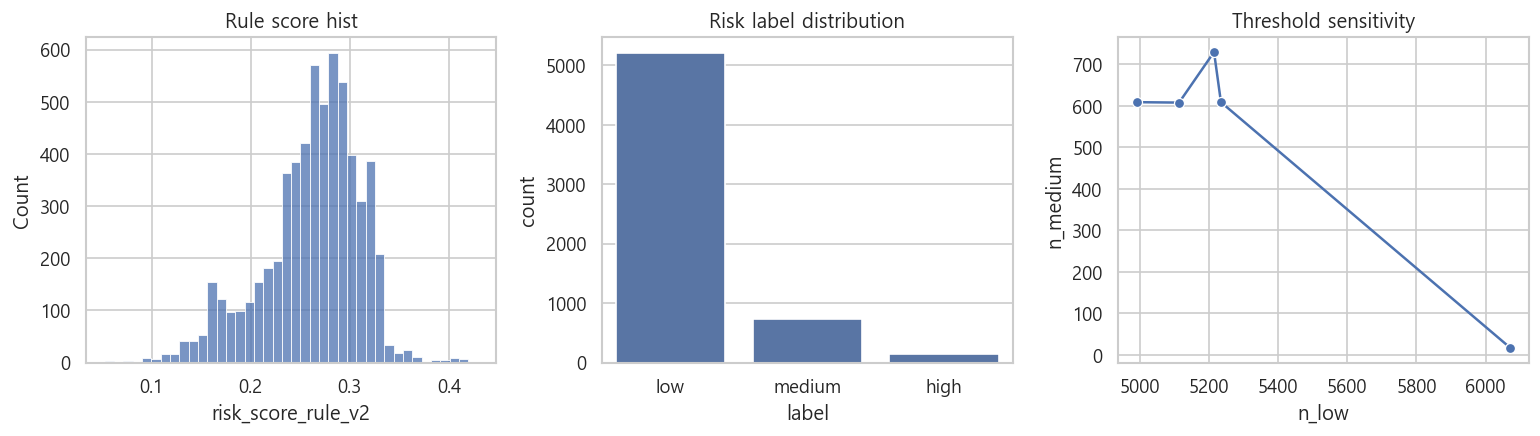

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_rule_risk_bev_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_rule_risk_bev_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_rule_risk_bev_presentation_single_ipynb.png


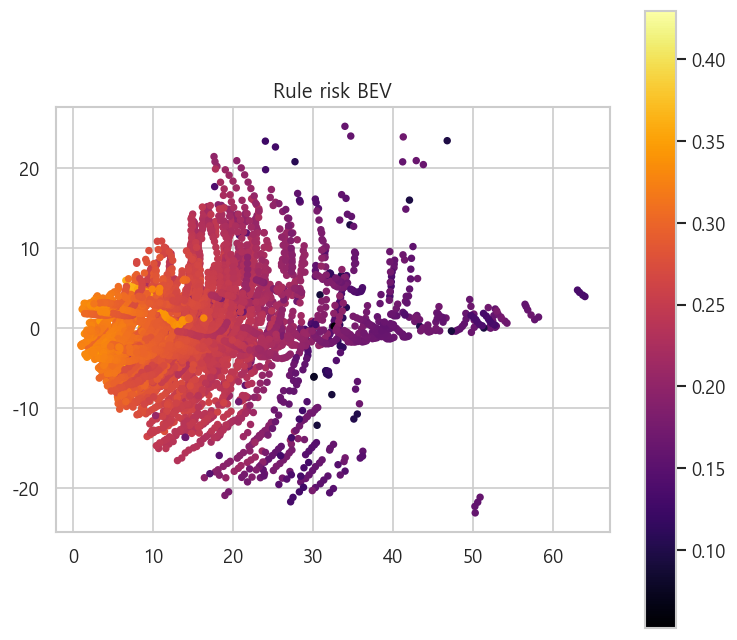

[핵심 해석] quantile 기반 라벨링은 고위험 support를 안정적으로 확보한다.
[다음 단계 연결] ML refinement에서 누수 없이 일반화 성능을 점검한다.


In [18]:
# Section 8 발표용 시각화
d = RESULTS['full'].cluster_df_rule.copy()
fig, axes = plt.subplots(1,3,figsize=(13,3.8))
sns.histplot(d['risk_score_rule_v2'], bins=40, ax=axes[0]); axes[0].set_title('Rule score hist')
vc = d['risk_label_rule_v2'].value_counts().reset_index(); vc.columns=['label','count']
sns.barplot(data=vc, x='label', y='count', ax=axes[1]); axes[1].set_title('Risk label distribution')
if len(RESULTS['full'].threshold_sensitivity_df):
    tdf = RESULTS['full'].threshold_sensitivity_df.head(12).copy()
    xcol = next((c for c in ['threshold', 'score_threshold', 'quantile', 'thr'] if c in tdf.columns), None)
    ycol = next((c for c in ['high_recall', 'recall_high', 'recall'] if c in tdf.columns), None)
    if xcol and ycol:
        sns.lineplot(data=tdf, x=xcol, y=ycol, ax=axes[2], marker='o')
    else:
        tnum = tdf.select_dtypes(include=['number'])
        if tnum.shape[1] >= 2:
            sns.lineplot(x=tnum.iloc[:, 0], y=tnum.iloc[:, 1], ax=axes[2], marker='o')
            axes[2].set_xlabel(tnum.columns[0]); axes[2].set_ylabel(tnum.columns[1])
    axes[2].set_title('Threshold sensitivity')
plt.tight_layout(); save_fig('fig_rule_score_hist'); save_fig('fig_risk_label_distribution'); save_fig('fig_threshold_sensitivity'); save_fig_pair('fig_rule_score_hist'); plt.show()

fig, ax = plt.subplots(figsize=(6.5,5.5))
cm = ax.scatter(d['cx'], d['cy'], c=d['risk_score_rule_v2'], s=12, cmap='inferno')
ax.set_aspect('equal'); ax.set_title('Rule risk BEV')
plt.colorbar(cm, ax=ax)
plt.tight_layout(); save_fig('fig_rule_risk_bev'); save_fig_pair('fig_rule_risk_bev'); plt.show()
section_interp('quantile 기반 라벨링은 고위험 support를 안정적으로 확보한다.', 'ML refinement에서 누수 없이 일반화 성능을 점검한다.')


## Section 9. Feature sets & anti-leakage

A/B에 blacklist·rule-like·target helper가 섞이면 assert로 중단한다.


In [19]:
R = RESULTS["ops"]
chk = assert_ab_feature_sets_clean(R.feature_set_dict)
ipy_display(chk)
ipy_display(R.feature_set_summary_df)
save_table(R.feature_set_summary_df, "sec09_feature_sets")
save_table(chk, "sec09_anti_leakage_assert")
print("[HR 해석] C 세트는 diagnostic 전용이며 honest 보고에는 쓰지 않는다.")


,feature_set,blacklist_hits,passed
0,A_strict_anti_leakage,,True
1,B_moderate_anti_leakage,,True


,feature_set,n_features,contains_leakage_core,contains_ttc,contains_range_xy,contains_abs_vr_comp,contains_rule_score_like_feature,anti_leakage_passed,sample_features
0,A_strict_anti_leakage,31,False,False,False,False,False,True,"spread_xy, density_proxy, n_points, mean_rcs, ..."
1,B_moderate_anti_leakage,37,False,False,False,False,False,True,"spread_xy, density_proxy, n_points, mean_rcs, ..."
2,C_diagnostic_leakage,39,True,False,False,False,True,False,"spread_xy, density_proxy, n_points, mean_rcs, ..."


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec09_feature_sets_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec09_anti_leakage_assert_single_ipynb.csv
[HR 해석] C 세트는 diagnostic 전용이며 honest 보고에는 쓰지 않는다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_feature_set_compare_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_feature_set_compare_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_feature_set_compare_presentation_single_ipynb.png


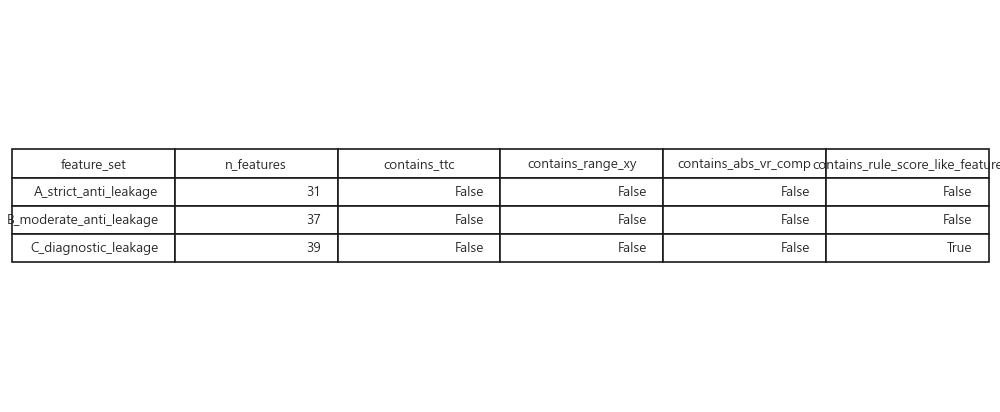

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_feature_pipeline_diagram_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_feature_pipeline_diagram_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_feature_pipeline_diagram_presentation_single_ipynb.png


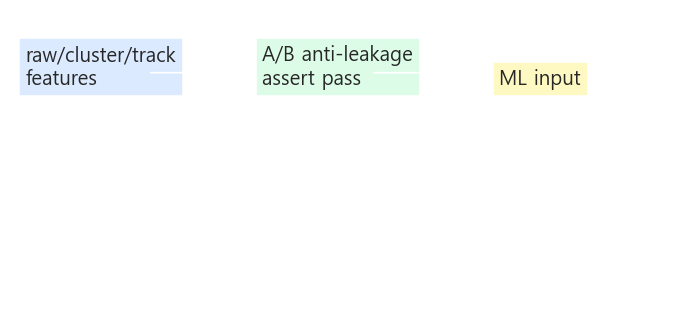

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_anti_leakage_check_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_anti_leakage_check_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_anti_leakage_check_presentation_single_ipynb.png


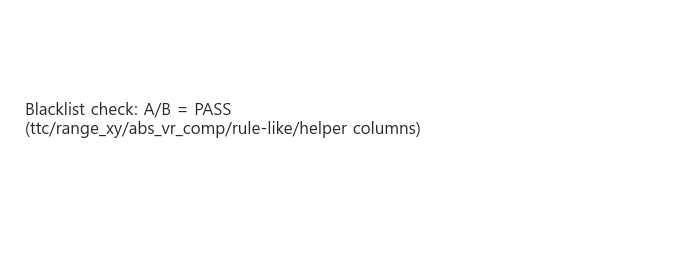

[핵심 해석] A/B는 strict/moderate anti-leakage, C는 diagnostic 용도다.
[다음 단계 연결] split 설계에서 honest 축을 확정한다.


In [20]:
# Section 9 발표용 시각화
fs = R.feature_set_summary_df.copy()
fig, ax = plt.subplots(figsize=(8.5,3.6))
show = fs[['feature_set','n_features','contains_ttc','contains_range_xy','contains_abs_vr_comp','contains_rule_score_like_feature']]
ax.axis('off')
tbl = ax.table(cellText=show.values, colLabels=show.columns, loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1,1.2)
plt.tight_layout(); save_fig('fig_feature_set_compare'); save_fig_pair('fig_feature_set_compare'); plt.show()

fig, ax = plt.subplots(figsize=(6,2.8)); ax.axis('off')
ax.text(0.02,0.75,'raw/cluster/track\nfeatures',bbox=dict(facecolor='#dbeafe'))
ax.text(0.37,0.75,'A/B anti-leakage\nassert pass',bbox=dict(facecolor='#dcfce7'))
ax.text(0.72,0.75,'ML input',bbox=dict(facecolor='#fef9c3'))
ax.annotate('',xy=(0.35,0.79),xytext=(0.2,0.79),arrowprops=dict(arrowstyle='->'))
ax.annotate('',xy=(0.70,0.79),xytext=(0.53,0.79),arrowprops=dict(arrowstyle='->'))
plt.tight_layout(); save_fig('fig_feature_pipeline_diagram'); save_fig_pair('fig_feature_pipeline_diagram'); plt.show()

fig, ax = plt.subplots(figsize=(5.8,2.4)); ax.axis('off')
ax.text(0.02,0.5,'Blacklist check: A/B = PASS\n(ttc/range_xy/abs_vr_comp/rule-like/helper columns)',fontsize=10)
plt.tight_layout(); save_fig('fig_anti_leakage_check'); save_fig_pair('fig_anti_leakage_check'); plt.show()
section_interp('A/B는 strict/moderate anti-leakage, C는 diagnostic 용도다.', 'split 설계에서 honest 축을 확정한다.')


## Section 10. Split 설계

random은 overall 진단용, 최종 해석은 honest split만.


In [21]:
R = RESULTS["ops"]
ipy_display(R.split_summary_df)
save_table(R.split_summary_df, "sec10_splits")
for _, r in R.split_summary_df.iterrows():
    print(r["split"], "n_test", r["n_test"], "test_high", r["test_high"])
print("[HR 해석] random은 동일 프레임 상관으로 낙관될 수 있어 결론에 쓰지 않는다.")


,split,n_train,n_test,train_high,test_high
0,random,3373,1124,81,25
1,group_frame,3398,1099,85,21
2,time,3361,1136,82,24
3,contiguous_block,2986,1511,76,30


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec10_splits_single_ipynb.csv
random n_test 1124 test_high 25
group_frame n_test 1099 test_high 21
time n_test 1136 test_high 24
contiguous_block n_test 1511 test_high 30
[HR 해석] random은 동일 프레임 상관으로 낙관될 수 있어 결론에 쓰지 않는다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_split_compare_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_split_support_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_split_compare_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_split_compare_presentation_single_ipynb.png


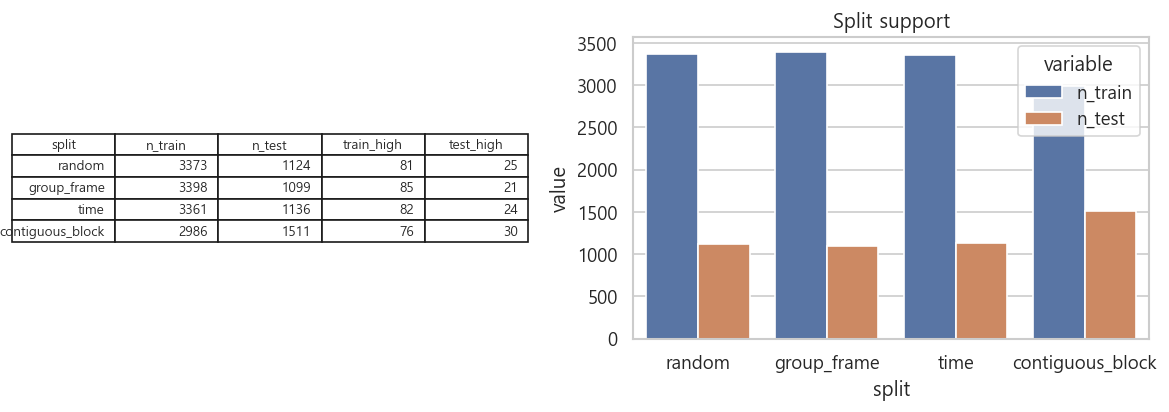

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_honest_vs_random_concept_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_honest_vs_random_concept_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_honest_vs_random_concept_presentation_single_ipynb.png


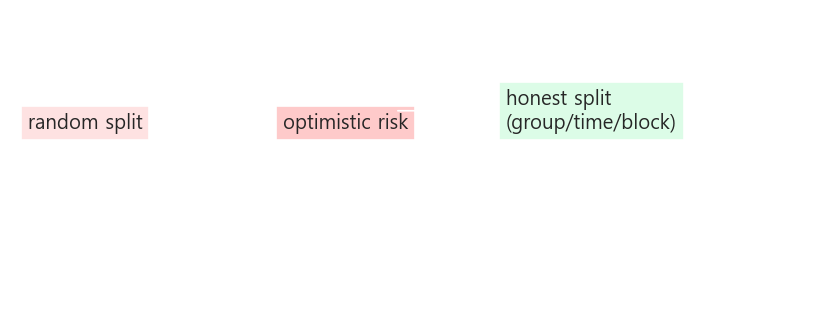

[핵심 해석] random은 진단용, 결론은 honest split만 사용한다.
[다음 단계 연결] 모델 비교에서도 same policy를 유지한다.


In [22]:
# Section 10 발표용 시각화
ss = R.split_summary_df.copy()
fig, axes = plt.subplots(1,2,figsize=(10,3.6))
ax=axes[0]; ax.axis('off'); t=ax.table(cellText=ss.values, colLabels=ss.columns, loc='center'); t.auto_set_font_size(False); t.set_fontsize(8); t.scale(1,1.2)
sns.barplot(data=ss.melt(id_vars='split', value_vars=['n_train','n_test']), x='split', y='value', hue='variable', ax=axes[1]); axes[1].set_title('Split support')
plt.tight_layout(); save_fig('fig_split_compare'); save_fig('fig_split_support'); save_fig_pair('fig_split_compare'); plt.show()

fig, ax = plt.subplots(figsize=(7,2.8)); ax.axis('off')
ax.text(0.02,0.6,'random split',bbox=dict(facecolor='#fee2e2'))
ax.text(0.34,0.6,'optimistic risk',bbox=dict(facecolor='#fecaca'))
ax.text(0.62,0.6,'honest split\n(group/time/block)',bbox=dict(facecolor='#dcfce7'))
ax.annotate('',xy=(0.32,0.66),xytext=(0.18,0.66),arrowprops=dict(arrowstyle='->'))
ax.annotate('',xy=(0.60,0.66),xytext=(0.48,0.66),arrowprops=dict(arrowstyle='->'))
plt.tight_layout(); save_fig('fig_honest_vs_random_concept'); save_fig_pair('fig_honest_vs_random_concept'); plt.show()
section_interp('random은 진단용, 결론은 honest split만 사용한다.', '모델 비교에서도 same policy를 유지한다.')


## Section 11. ML refinement

`best_model_summary_any_split` vs `best_model_summary_honest_only`를 분리한다.


In [23]:
best_any_rows = []
best_hon_rows = []
for m, R in RESULTS.items():
    exp = R.experiment_results_df.copy()
    exp = exp[exp["task"] == "classification"]
    exp = exp.merge(R.split_summary_df[["split", "n_test", "test_high"]], on="split", how="left")
    ipy_display(exp.head(25))
    save_table(exp, f"sec11_experiments_{m}")
    ba = pick_best_any_split(exp)
    bh = pick_best_honest_only(exp)
    if len(ba):
        best_any_rows.append({"pipeline_mode": m, **{k: ba.get(k) for k in ["model", "feature_set", "split", "macro_f1", "high_recall", "ranking_ap"]}})
    best_hon_rows.append({"pipeline_mode": m, **{k: bh.get(k) for k in ["model", "feature_set", "split", "macro_f1", "high_recall", "ranking_ap"]}})

best_model_summary_any_split = pd.DataFrame(best_any_rows)
best_model_summary_honest_only = pd.DataFrame(best_hon_rows)
ipy_display(best_model_summary_any_split)
ipy_display(best_model_summary_honest_only)
save_table(best_model_summary_any_split, "sec11_best_any_split")
save_table(best_model_summary_honest_only, "sec11_best_honest_only")
print("[HR 해석] any_split 행에 random이 보일 수 있다. 최종 요약은 honest_only만 사용한다.")


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,n_test,test_high
0,classification,logreg,A_strict_anti_leakage,random,0.905536,0.720930,0.575441,1.0,0.185393,-0.098017,NaN,NaN,1522,43
1,classification,rf,A_strict_anti_leakage,random,0.940042,0.790698,0.593335,1.0,0.191011,0.059958,NaN,NaN,1522,43
2,classification,svm_rbf,A_strict_anti_leakage,random,0.905536,0.720930,0.496849,1.0,0.185393,0.036533,NaN,NaN,1522,43
3,classification,hgb,A_strict_anti_leakage,random,0.962402,0.883721,0.659677,1.0,0.219101,0.037598,NaN,NaN,1522,43
4,classification,logreg,A_strict_anti_leakage,group_frame,0.917697,0.787879,0.529878,1.0,0.644444,-0.097206,NaN,NaN,1539,33
5,classification,rf,A_strict_anti_leakage,group_frame,0.967079,0.878788,0.553846,1.0,0.644444,0.032921,NaN,NaN,1539,33
6,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.950618,0.848485,0.472348,1.0,0.644444,-0.003018,NaN,NaN,1539,33
7,classification,hgb,A_strict_anti_leakage,group_frame,0.984043,0.939394,0.587849,1.0,0.688889,0.015957,NaN,NaN,1539,33
8,classification,logreg,A_strict_anti_leakage,time,0.694502,0.275000,0.642061,0.8,0.517241,0.176551,NaN,NaN,1528,40
9,classification,rf,A_strict_anti_leakage,time,0.690920,0.250000,0.673098,0.9,0.379310,0.309080,NaN,NaN,1528,40


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_experiments_full_single_ipynb.csv


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,n_test,test_high
0,classification,logreg,A_strict_anti_leakage,random,0.844647,0.640000,0.545377,0.8,0.117978,-0.038272,NaN,NaN,1124,25
1,classification,rf,A_strict_anti_leakage,random,0.902949,0.680000,0.503283,1.0,0.095506,0.097051,NaN,NaN,1124,25
2,classification,svm_rbf,A_strict_anti_leakage,random,0.957424,0.880000,0.514808,1.0,0.129213,0.008923,NaN,NaN,1124,25
3,classification,hgb,A_strict_anti_leakage,random,0.943310,0.800000,0.567416,1.0,0.112360,0.056690,NaN,NaN,1124,25
4,classification,logreg,A_strict_anti_leakage,group_frame,0.923610,0.809524,0.527063,1.0,0.422222,-0.162484,NaN,NaN,1099,21
5,classification,rf,A_strict_anti_leakage,group_frame,0.974537,0.904762,0.411484,1.0,0.422222,0.025463,NaN,NaN,1099,21
6,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.975727,0.952381,0.435269,1.0,0.466667,-0.007730,NaN,NaN,1099,21
7,classification,hgb,A_strict_anti_leakage,group_frame,0.987573,0.952381,0.453802,1.0,0.444444,0.012427,NaN,NaN,1099,21
8,classification,logreg,A_strict_anti_leakage,time,0.725374,0.541667,0.579886,0.7,1.185185,0.094049,NaN,NaN,1136,24
9,classification,rf,A_strict_anti_leakage,time,0.494662,0.000000,0.433042,0.5,0.000000,0.505338,NaN,NaN,1136,24


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_experiments_ops_single_ipynb.csv


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,n_test,test_high
0,classification,logreg,A_strict_anti_leakage,random,0.683219,0.230769,0.520460,0.5,0.018182,0.062490,NaN,NaN,592,13
1,classification,rf,A_strict_anti_leakage,random,0.933491,0.769231,0.493717,1.0,0.060606,0.066509,NaN,NaN,592,13
2,classification,svm_rbf,A_strict_anti_leakage,random,0.933491,0.769231,0.491810,1.0,0.060606,0.006774,NaN,NaN,592,13
3,classification,hgb,A_strict_anti_leakage,random,0.957471,0.846154,0.521430,1.0,0.066667,0.042529,NaN,NaN,592,13
4,classification,logreg,A_strict_anti_leakage,group_frame,0.847600,0.583333,0.585029,0.7,0.177778,-0.143204,NaN,NaN,635,12
5,classification,rf,A_strict_anti_leakage,group_frame,0.898400,0.666667,0.475531,0.8,0.177778,0.101600,NaN,NaN,635,12
6,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.812992,0.500000,0.497784,0.7,0.155556,0.149537,NaN,NaN,635,12
7,classification,hgb,A_strict_anti_leakage,group_frame,0.861233,0.666667,0.591805,0.8,0.222222,0.138767,NaN,NaN,635,12
8,classification,logreg,A_strict_anti_leakage,time,0.574801,0.222222,0.369496,0.1,0.555556,0.202426,NaN,NaN,598,9
9,classification,rf,A_strict_anti_leakage,time,0.495784,0.000000,0.376133,0.2,0.037037,0.504216,NaN,NaN,598,9


...

,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,n_test,test_high
0,classification,logreg,A_strict_anti_leakage,random,0.861910,0.666667,0.294222,0.5,0.033113,0.048651,NaN,NaN,440,6
1,classification,rf,A_strict_anti_leakage,random,0.861910,0.666667,0.370457,0.5,0.033113,0.138090,NaN,NaN,440,6
2,classification,svm_rbf,A_strict_anti_leakage,random,0.915515,0.833333,0.315208,0.5,0.039735,0.056678,NaN,NaN,440,6
3,classification,hgb,A_strict_anti_leakage,random,0.621560,0.166667,0.348912,0.5,0.013245,0.378440,NaN,NaN,440,6
4,classification,logreg,A_strict_anti_leakage,group_frame,0.862008,1.000000,0.315661,0.4,0.155556,0.049891,NaN,NaN,466,4
5,classification,rf,A_strict_anti_leakage,group_frame,0.943903,1.000000,0.380075,0.4,0.111111,0.056097,NaN,NaN,466,4
6,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.943903,1.000000,0.326531,0.4,0.111111,0.009247,NaN,NaN,466,4
7,classification,hgb,A_strict_anti_leakage,group_frame,0.943903,1.000000,0.413711,0.4,0.111111,0.056097,NaN,NaN,466,4
8,classification,logreg,A_strict_anti_leakage,time,0.499431,0.000000,0.165412,0.0,0.000000,0.397640,NaN,NaN,440,1
9,classification,rf,A_strict_anti_leakage,time,0.497717,0.000000,0.391447,0.0,0.111111,0.502283,NaN,NaN,440,1


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_experiments_ops_t15_single_ipynb.csv


,pipeline_mode,model,feature_set,split,macro_f1,high_recall,ranking_ap
0,full,hgb,B_moderate_anti_leakage,random,0.981846,0.953488,0.846852
1,ops,logreg,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.750812
2,ops_t20,logreg,B_moderate_anti_leakage,group_frame,0.953744,0.833333,0.828397
3,ops_t18,logreg,B_moderate_anti_leakage,group_frame,0.975733,0.909091,0.684777
4,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.551982


,pipeline_mode,model,feature_set,split,macro_f1,high_recall,ranking_ap
0,full,hgb,B_moderate_anti_leakage,group_frame,0.984043,0.939394,0.819050
1,ops,logreg,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.750812
2,ops_t20,logreg,B_moderate_anti_leakage,group_frame,0.953744,0.833333,0.828397
3,ops_t18,logreg,B_moderate_anti_leakage,group_frame,0.975733,0.909091,0.684777
4,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.551982


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_best_any_split_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_best_honest_only_single_ipynb.csv
[HR 해석] any_split 행에 random이 보일 수 있다. 최종 요약은 honest_only만 사용한다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_model_compare_heatmap_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_model_compare_heatmap_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_model_compare_heatmap_presentation_single_ipynb.png


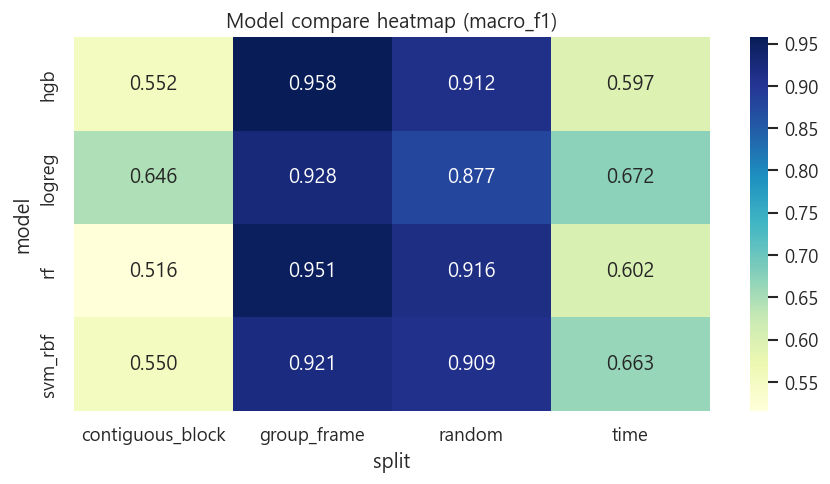

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_overall_vs_honest_best_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_overall_vs_honest_best_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_overall_vs_honest_best_presentation_single_ipynb.png


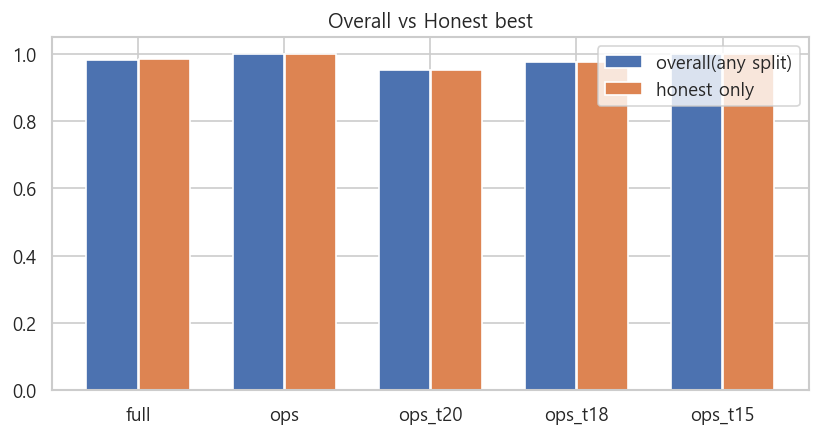

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_honest_top_models_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_honest_top_models_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_honest_top_models_presentation_single_ipynb.png


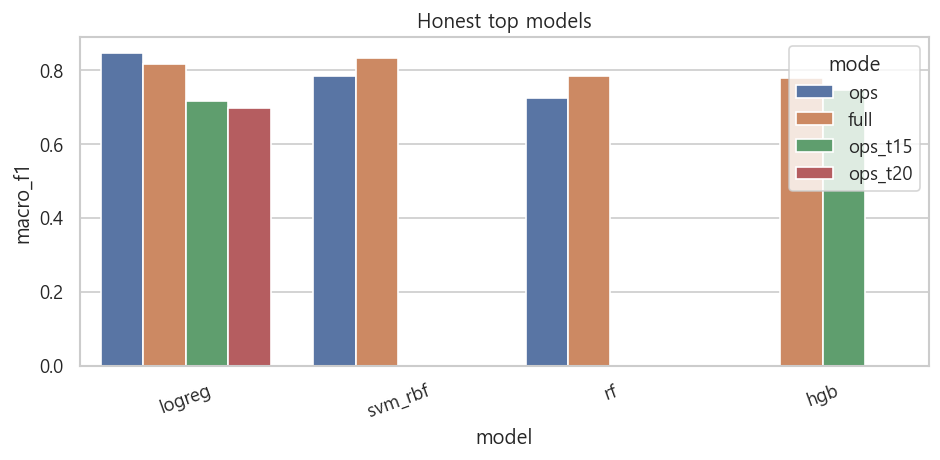

[핵심 해석] overall-best와 honest-best 분리는 과대해석 방지의 핵심이다.
[다음 단계 연결] 보정 단계에서도 honest best 기준으로 평가한다.


In [24]:
# Section 11 발표용 시각화
exp_all=[]
for m,Rm in RESULTS.items():
    e = Rm.experiment_results_df.copy()
    e = e[e['task']=='classification'].copy(); e['mode']=m
    exp_all.append(e)
exp_all = pd.concat(exp_all, ignore_index=True)
pt = exp_all.pivot_table(index='model', columns='split', values='macro_f1', aggfunc='mean')
fig, ax = plt.subplots(figsize=(7.5,4.2))
sns.heatmap(pt, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('Model compare heatmap (macro_f1)')
plt.tight_layout(); save_fig('fig_model_compare_heatmap'); save_fig_pair('fig_model_compare_heatmap'); plt.show()

cmp = best_model_summary_any_split.merge(best_model_summary_honest_only, on='pipeline_mode', suffixes=('_any','_honest'))
fig, ax = plt.subplots(figsize=(7,3.8))
ax.bar(np.arange(len(cmp))-0.18, cmp['macro_f1_any'], width=0.35, label='overall(any split)')
ax.bar(np.arange(len(cmp))+0.18, cmp['macro_f1_honest'], width=0.35, label='honest only')
ax.set_xticks(np.arange(len(cmp)), cmp['pipeline_mode']); ax.legend(); ax.set_title('Overall vs Honest best')
plt.tight_layout(); save_fig('fig_overall_vs_honest_best'); save_fig_pair('fig_overall_vs_honest_best'); plt.show()

top_h = exp_all[exp_all['split'].isin(e2e.HONEST_SPLITS)].groupby(['mode','model'])['macro_f1'].mean().reset_index().sort_values('macro_f1',ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=top_h, x='model', y='macro_f1', hue='mode', ax=ax)
ax.set_title('Honest top models'); plt.xticks(rotation=20)
plt.tight_layout(); save_fig('fig_honest_top_models'); save_fig_pair('fig_honest_top_models'); plt.show()
section_interp('overall-best와 honest-best 분리는 과대해석 방지의 핵심이다.', '보정 단계에서도 honest best 기준으로 평가한다.')


## Section 12. Calibration

raw 대비 Brier/ECE가 나빠지면 보정 미적용(e2e 내부 정책).


,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.001428,0.001747,0.477405,1.0,0.018843,0.017544,0.977258
1,platt_cv,0.001703,0.006008,0.814324,1.0,0.010396,0.000650,0.001949
2,isotonic_cv,0.001758,0.004448,0.655248,1.0,0.016244,0.016244,0.898635


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_full_single_ipynb.csv
full calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.018843404808317088, 'sat_gt_0.999': 0.017543859649122806, 'sat_lt_1e-3': 0.9772579597141} saturation_selected {'sat_gt_0.99': 0.018843404808317088, 'sat_gt_0.999': 0.017543859649122806, 'sat_lt_1e-3': 0.9772579597141}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_full_single_ipynb.png


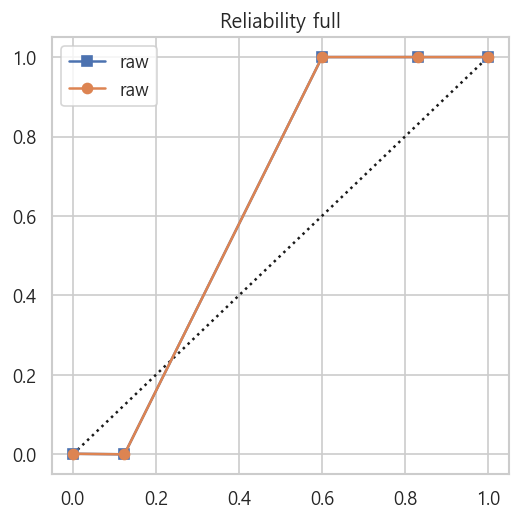

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.000151,0.001274,0.750812,1.0,0.011829,0.007279,0.924477
1,platt_cv,0.000641,0.005308,0.668783,1.0,0.006369,0.002730,0.479527
2,isotonic_cv,0.000740,0.003823,0.439082,1.0,0.008189,0.008189,0.941765


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_ops_single_ipynb.csv
ops calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.011828935395814377, 'sat_gt_0.999': 0.007279344858962694, 'sat_lt_1e-3': 0.924476797088262} saturation_selected {'sat_gt_0.99': 0.011828935395814377, 'sat_gt_0.999': 0.007279344858962694, 'sat_lt_1e-3': 0.924476797088262}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_ops_single_ipynb.png


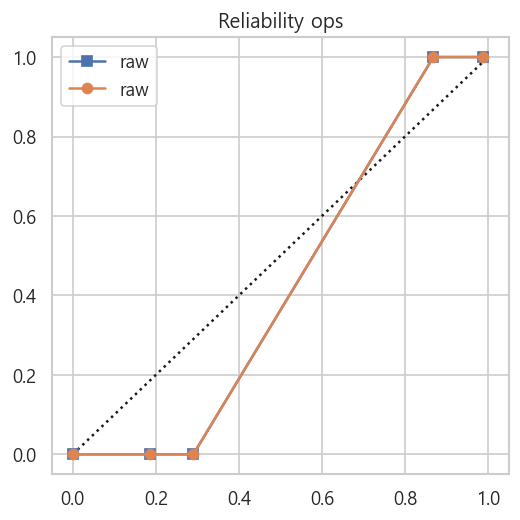

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.002337,0.008280,0.828397,1.0,0.009449,0.007874,0.784252
1,platt_cv,0.005025,0.015505,0.757807,1.0,0.000000,0.000000,0.026772
2,isotonic_cv,0.004166,0.014115,0.738482,1.0,0.009449,0.009449,0.667717


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_ops_t20_single_ipynb.csv
ops_t20 calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.009448818897637795, 'sat_gt_0.999': 0.007874015748031496, 'sat_lt_1e-3': 0.784251968503937} saturation_selected {'sat_gt_0.99': 0.009448818897637795, 'sat_gt_0.999': 0.007874015748031496, 'sat_lt_1e-3': 0.784251968503937}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_ops_t20_single_ipynb.png


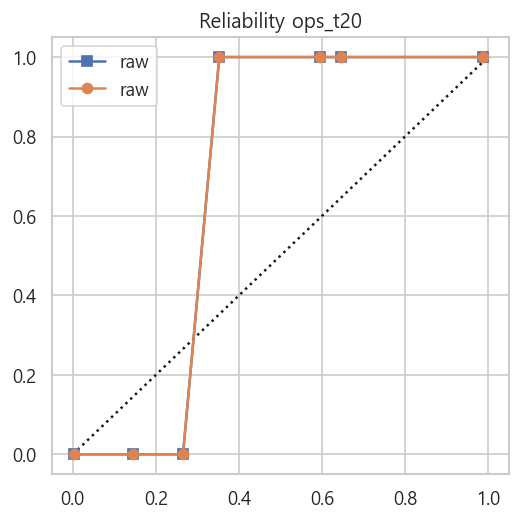

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.002696,0.003763,0.684777,1.0,0.008977,0.003591,0.833034
1,platt_cv,0.005041,0.013338,0.641716,1.0,0.000000,0.000000,0.039497
2,isotonic_cv,0.004070,0.008633,0.491601,1.0,0.005386,0.005386,0.877917


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_ops_t18_single_ipynb.csv
ops_t18 calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.008976660682226212, 'sat_gt_0.999': 0.003590664272890485, 'sat_lt_1e-3': 0.8330341113105925} saturation_selected {'sat_gt_0.99': 0.008976660682226212, 'sat_gt_0.999': 0.003590664272890485, 'sat_lt_1e-3': 0.8330341113105925}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_ops_t18_single_ipynb.png


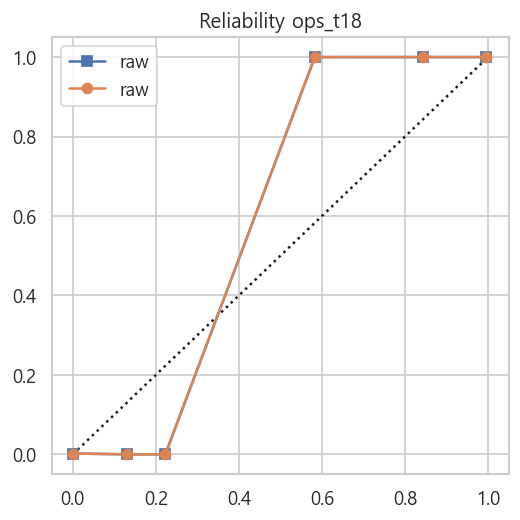

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,1.221058e-08,0.000007,0.379593,0.4,0.008584,0.008584,0.989270
1,platt_cv,5.016780e-04,0.006183,0.560218,0.4,0.000000,0.000000,0.000000
2,isotonic_cv,5.247066e-04,0.001796,0.234773,0.4,0.008584,0.008584,0.984979


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_ops_t15_single_ipynb.csv
ops_t15 calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.008583690987124463, 'sat_gt_0.999': 0.008583690987124463, 'sat_lt_1e-3': 0.9892703862660944} saturation_selected {'sat_gt_0.99': 0.008583690987124463, 'sat_gt_0.999': 0.008583690987124463, 'sat_lt_1e-3': 0.9892703862660944}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_ops_t15_single_ipynb.png


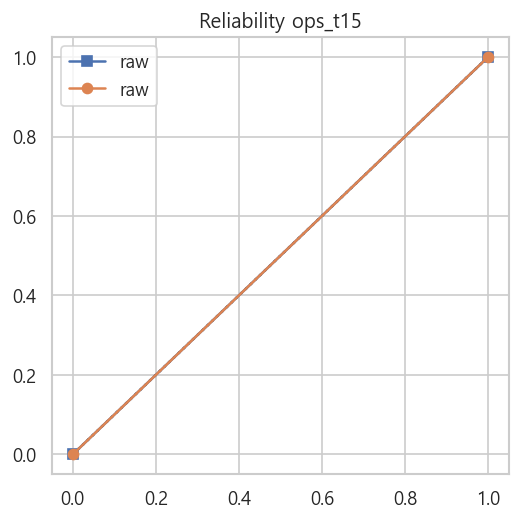

[HR 해석] 보정은 항상 이득이 아니므로 raw fallback을 허용한다.


In [25]:
from sklearn.calibration import calibration_curve

for m, R in RESULTS.items():
    cb = R.calibration_bundle
    ipy_display(cb["calibration_compare_df"])
    save_table(cb["calibration_compare_df"], f"sec12_cal_{m}")
    print(m, "calibration_used", cb["calibration_used"], "method", cb["selected_calibration_method"])
    print("saturation_raw", cb.get("saturation_raw"), "saturation_selected", cb.get("saturation_selected"))
    tr, te = R.split_dict[str(R.honest_best_row["split"])]
    y = (R.cluster_df_rule["risk_label_rule_v2"] == "high").astype(int).to_numpy()
    yte = y[te]
    p_raw, p_sel = cb["p_raw"], cb["p_selected"]
    pr, pp = calibration_curve(yte, p_raw, n_bins=10, strategy="uniform")
    pr2, pp2 = calibration_curve(yte, p_sel, n_bins=10, strategy="uniform")
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.plot([0, 1], [0, 1], "k:")
    ax.plot(pp, pr, "s-", label="raw")
    ax.plot(pp2, pr2, "o-", label=str(cb["selected_calibration_method"]))
    ax.legend()
    ax.set_title(f"Reliability {m}")
    plt.tight_layout()
    save_fig(f"sec12_rel_{m}")
    plt.show()
print("[HR 해석] 보정은 항상 이득이 아니므로 raw fallback을 허용한다.")


,mode,brier_raw,brier_sel,ece_raw,ece_sel,method
0,full,1.427967e-03,1.427967e-03,0.001747,0.001747,raw
1,ops,1.511866e-04,1.511866e-04,0.001274,0.001274,raw
2,ops_t20,2.337178e-03,2.337178e-03,0.008280,0.008280,raw
3,ops_t18,2.696251e-03,2.696251e-03,0.003763,0.003763,raw
4,ops_t15,1.221058e-08,1.221058e-08,0.000007,0.000007,raw


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_calibration_compare_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_calibration_compare_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_calibration_compare_presentation_single_ipynb.png


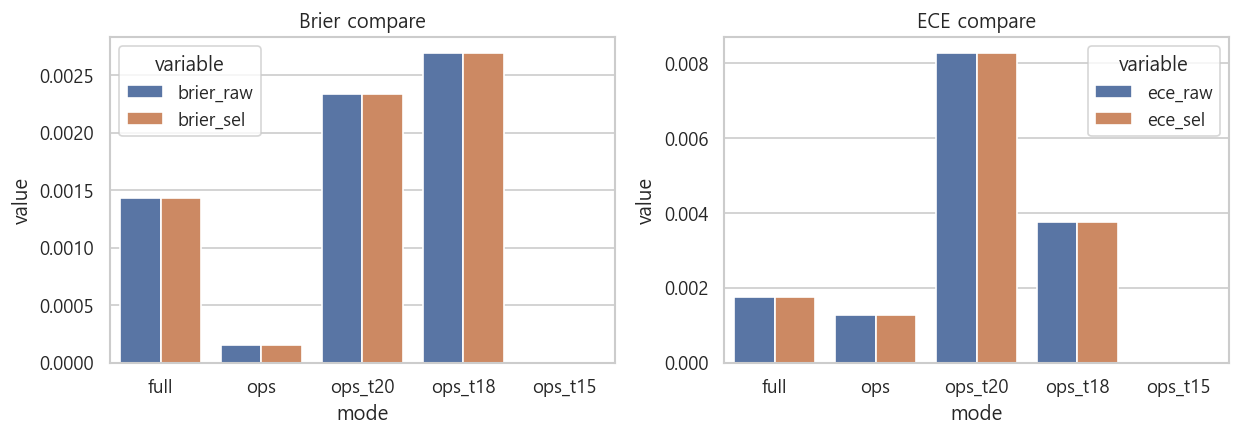

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_confidence_uncertainty_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_confidence_uncertainty_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_confidence_uncertainty_presentation_single_ipynb.png


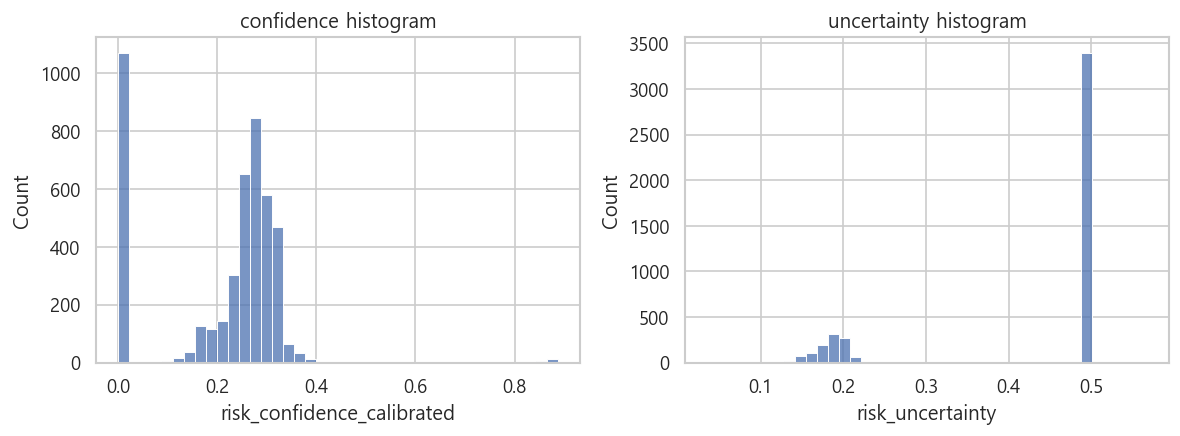

[핵심 해석] 보정은 항상 이득이 아니며 raw fallback 정책이 필요하다.
[다음 단계 연결] 최종 hybrid score는 보정/불확실성 정보를 함께 사용한다.


In [26]:
# Section 12 발표용 시각화
rows=[]
for m,Rm in RESULTS.items():
    c = Rm.calibration_bundle
    rows.append({'mode':m,'brier_raw':c['brier_raw'],'brier_sel':c['brier_selected'],'ece_raw':c['ece_raw'],'ece_sel':c['ece_selected'],'method':c['selected_calibration_method']})
cal_sum = pd.DataFrame(rows)
ipy_display(cal_sum)
fig, axes = plt.subplots(1,2,figsize=(10.5,3.8))
cal_long = cal_sum.melt(id_vars='mode', value_vars=['brier_raw','brier_sel'])
sns.barplot(data=cal_long, x='mode', y='value', hue='variable', ax=axes[0]); axes[0].set_title('Brier compare')
cal_long2 = cal_sum.melt(id_vars='mode', value_vars=['ece_raw','ece_sel'])
sns.barplot(data=cal_long2, x='mode', y='value', hue='variable', ax=axes[1]); axes[1].set_title('ECE compare')
plt.tight_layout(); save_fig('fig_calibration_compare'); save_fig_pair('fig_calibration_compare'); plt.show()

Rops=RESULTS['ops']; d=Rops.cluster_df_final
fig, axes = plt.subplots(1,2,figsize=(10,3.8))
sns.histplot(d['risk_confidence_calibrated'].dropna(), bins=40, ax=axes[0]); axes[0].set_title('confidence histogram')
sns.histplot(d['risk_uncertainty'].dropna(), bins=40, ax=axes[1]); axes[1].set_title('uncertainty histogram')
plt.tight_layout(); save_fig('fig_confidence_uncertainty'); save_fig_pair('fig_confidence_uncertainty'); plt.show()
section_interp('보정은 항상 이득이 아니며 raw fallback 정책이 필요하다.', '최종 hybrid score는 보정/불확실성 정보를 함께 사용한다.')


## Section 13. Final hybrid score

rule vs hybrid, sensitivity sweep.


In [27]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.hybrid_vs_rule_df.assign(mode=m))
    ipy_display(R.hybrid_sensitivity_df.assign(mode=m))
    save_table(R.hybrid_vs_rule_df.assign(mode=m), f"sec13_hybrid_{m}")
    comp = R.cluster_df_final[["risk_score_rule_v2", "score_final_stage4"]].describe()
    ipy_display(comp)
print("[HR 해석] hybrid는 부담·불확실성·설명·운영 포인트 조정에 초점을 둔다.")


,topk,overlap,rule_only_mean_score,hybrid_mean_score,mode
0,30,0.4,0.262134,0.35082,full


,W_LIDAR,W_TEMPORAL,W_RELIABILITY,W_QUALITY,W_UNCERTAINTY,ranking_ap,p10,burden_per_frame,mode
0,0.10,0.10,0.08,0.06,0.18,0.672588,1.0,33.822222,full
1,0.12,0.10,0.10,0.08,0.20,0.671561,1.0,33.822222,full
2,0.08,0.14,0.10,0.08,0.22,0.558312,1.0,33.822222,full


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec13_hybrid_full_single_ipynb.csv


,risk_score_rule_v2,score_final_stage4
count,6088.000000,6088.000000
mean,0.262134,0.350820
std,0.049000,0.060019
min,0.052536,0.095529
25%,0.238112,0.321440
50%,0.269055,0.359515
75%,0.295389,0.390856
max,0.429151,0.629734


,topk,overlap,rule_only_mean_score,hybrid_mean_score,mode
0,30,0.633333,0.269551,0.361183,ops


,W_LIDAR,W_TEMPORAL,W_RELIABILITY,W_QUALITY,W_UNCERTAINTY,ranking_ap,p10,burden_per_frame,mode
0,0.10,0.10,0.08,0.06,0.18,0.629400,1.0,25.122905,ops
1,0.12,0.10,0.10,0.08,0.20,0.627540,1.0,25.122905,ops
2,0.08,0.14,0.10,0.08,0.22,0.498708,1.0,25.122905,ops


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec13_hybrid_ops_single_ipynb.csv


,risk_score_rule_v2,score_final_stage4
count,4497.000000,4497.000000
mean,0.269551,0.361183
std,0.043802,0.054177
min,0.088354,0.131830
25%,0.248981,0.334866
50%,0.274306,0.367458
75%,0.297635,0.396859
max,0.408252,0.615423


[HR 해석] hybrid는 부담·불확실성·설명·운영 포인트 조정에 초점을 둔다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_rule_vs_hybrid_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_rule_vs_hybrid_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_rule_vs_hybrid_presentation_single_ipynb.png


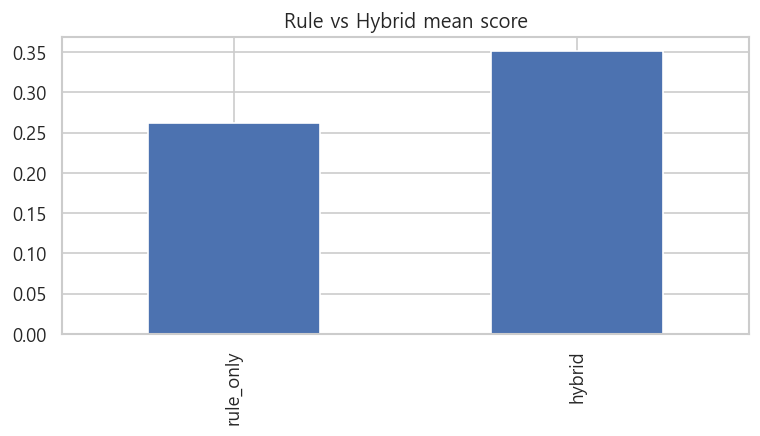

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_topk_overlap_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_topk_overlap_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_topk_overlap_presentation_single_ipynb.png


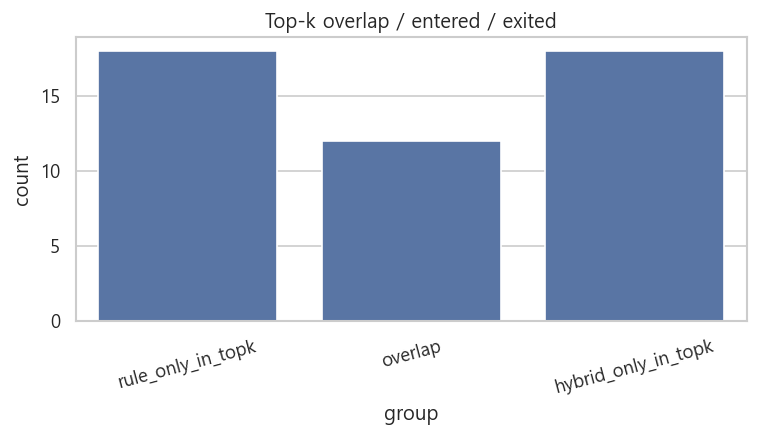

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_score_components_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_score_components_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_score_components_presentation_single_ipynb.png


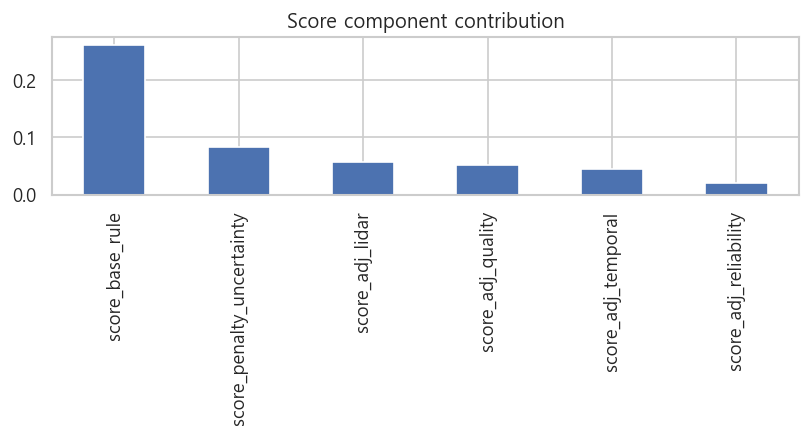

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_hybrid_risk_bev_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_final_risk_map_presentation_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_hybrid_risk_bev_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_hybrid_risk_bev_presentation_single_ipynb.png


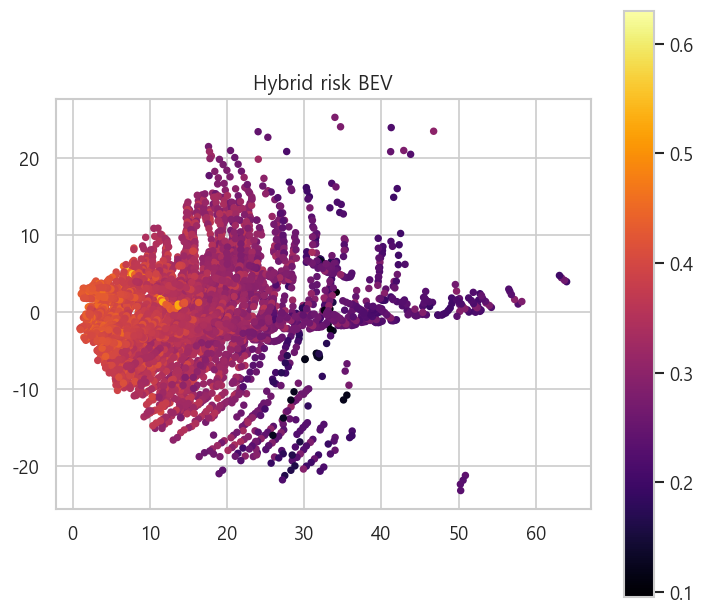

[핵심 해석] hybrid는 순위를 재배열해 운영 포인트 조정에 활용된다.
[다음 단계 연결] ranking 지표에서 full/ops trade-off를 확인한다.


In [28]:
# Section 13 발표용 시각화
R=RESULTS['full']; d=R.cluster_df_final.copy()
fig, ax = plt.subplots(figsize=(6.5,3.8))
cmp = pd.DataFrame({'rule_only': [d['risk_score_rule_v2'].mean()], 'hybrid': [d['score_final_stage4'].mean()]})
cmp.T.plot(kind='bar', legend=False, ax=ax); ax.set_title('Rule vs Hybrid mean score')
plt.tight_layout(); save_fig('fig_rule_vs_hybrid'); save_fig_pair('fig_rule_vs_hybrid'); plt.show()

k=30
top_rule=set(d.nlargest(k,'risk_score_rule_v2').index)
top_h=set(d.nlargest(k,'score_final_stage4').index)
overlap=len(top_rule & top_h)
flow=pd.DataFrame({'group':['rule_only_in_topk','overlap','hybrid_only_in_topk'], 'count':[k-overlap, overlap, k-overlap]})
fig, ax = plt.subplots(figsize=(6.6,3.8)); sns.barplot(data=flow, x='group', y='count', ax=ax); ax.set_title('Top-k overlap / entered / exited'); plt.xticks(rotation=15)
plt.tight_layout(); save_fig('fig_topk_overlap'); save_fig_pair('fig_topk_overlap'); plt.show()

comp_cols=[c for c in ['score_base_rule','score_adj_lidar','score_adj_temporal','score_adj_reliability','score_adj_quality','score_penalty_uncertainty'] if c in d.columns]
comp_mean=d[comp_cols].mean().sort_values(ascending=False)
fig, ax=plt.subplots(figsize=(7,3.8)); comp_mean.plot(kind='bar', ax=ax); ax.set_title('Score component contribution')
plt.tight_layout(); save_fig('fig_score_components'); save_fig_pair('fig_score_components'); plt.show()

fig, ax = plt.subplots(figsize=(6.3,5.3)); cm=ax.scatter(d['cx'], d['cy'], c=d['score_final_stage4'], s=12, cmap='inferno'); ax.set_aspect('equal'); ax.set_title('Hybrid risk BEV')
plt.colorbar(cm, ax=ax); plt.tight_layout(); save_fig('fig_hybrid_risk_bev'); save_fig('fig_final_risk_map_presentation'); save_fig_pair('fig_hybrid_risk_bev'); plt.show()
section_interp('hybrid는 순위를 재배열해 운영 포인트 조정에 활용된다.', 'ranking 지표에서 full/ops trade-off를 확인한다.')


## Section 14. Ranking evaluation

top-k 및 연관 지표.


In [29]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.ranking_summary_df.assign(mode=m))
    save_table(R.ranking_summary_df.assign(mode=m), f"sec14_rank_{m}")
print("[HR 해석] precision@k가 운영에서 직접 연결되는 지표다.")


,metric,value,mode
0,precision@5_hard,1.000000,full
1,precision@10_hard,1.000000,full
2,recall@10_hard,0.069930,full
3,ap_soft,0.671561,full
4,map,0.671561,full
5,mrr,1.000000,full
6,ndcg@10,1.000000,full
7,track_ap,0.741134,full
8,window10_hit_rate,0.722222,full
9,window20_hit_rate,0.777778,full


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec14_rank_full_single_ipynb.csv


,metric,value,mode
0,precision@5_hard,1.000000,ops
1,precision@10_hard,1.000000,ops
2,recall@10_hard,0.094340,ops
3,ap_soft,0.627540,ops
4,map,0.627540,ops
5,mrr,1.000000,ops
6,ndcg@10,1.000000,ops
7,track_ap,0.854661,ops
8,window10_hit_rate,0.555556,ops
9,window20_hit_rate,0.666667,ops


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec14_rank_ops_single_ipynb.csv
[HR 해석] precision@k가 운영에서 직접 연결되는 지표다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_ranking_metrics_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_ranking_metrics_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_ranking_metrics_presentation_single_ipynb.png


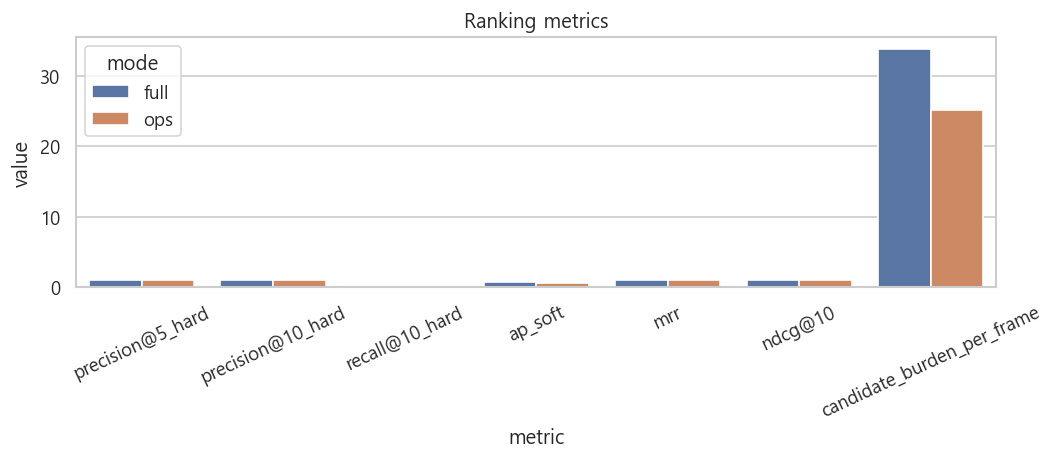

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_precision_recall_at_k_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_precision_recall_at_k_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_precision_recall_at_k_presentation_single_ipynb.png


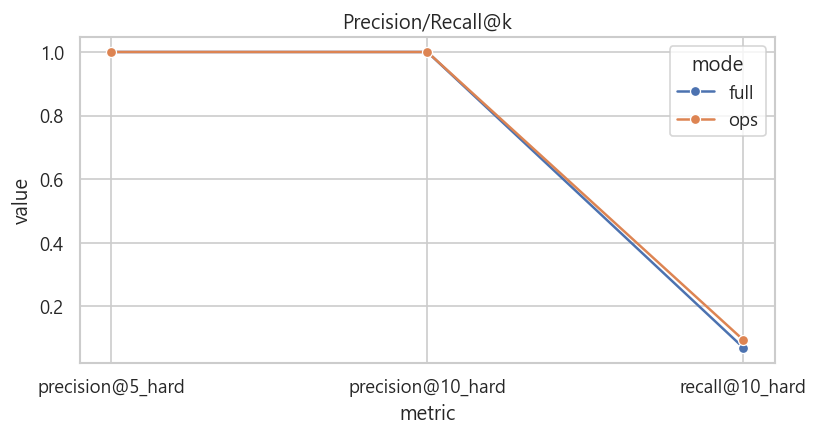

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_burden_utility_frontier_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_burden_utility_frontier_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_burden_utility_frontier_presentation_single_ipynb.png


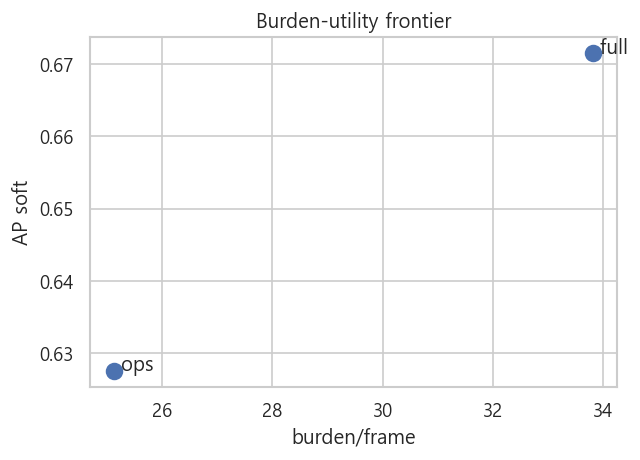

[핵심 해석] top-k 정밀도와 burden은 함께 봐야 한다.
[다음 단계 연결] ablation에서 어떤 모듈이 이 trade-off를 만든지 분해한다.


In [30]:
# Section 14 발표용 시각화
rows=[]
for m in ('full','ops'):
    rr=RESULTS[m].ranking_summary_df.copy(); rr['mode']=m; rows.append(rr)
rdf=pd.concat(rows,ignore_index=True)
keep=['precision@5_hard','precision@10_hard','recall@10_hard','ap_soft','ndcg@10','mrr','candidate_burden_per_frame']
sub=rdf[rdf['metric'].isin(keep)]
fig, ax = plt.subplots(figsize=(9,4)); sns.barplot(data=sub, x='metric', y='value', hue='mode', ax=ax); ax.set_title('Ranking metrics'); plt.xticks(rotation=25)
plt.tight_layout(); save_fig('fig_ranking_metrics'); save_fig_pair('fig_ranking_metrics'); plt.show()

pr = rdf[rdf['metric'].isin(['precision@5_hard','precision@10_hard','recall@10_hard'])].copy()
fig, ax = plt.subplots(figsize=(7,3.8)); sns.lineplot(data=pr, x='metric', y='value', hue='mode', marker='o', ax=ax); ax.set_title('Precision/Recall@k')
plt.tight_layout(); save_fig('fig_precision_recall_at_k'); save_fig_pair('fig_precision_recall_at_k'); plt.show()

front = rdf[rdf['metric'].isin(['ap_soft','candidate_burden_per_frame'])].pivot(index='mode', columns='metric', values='value').reset_index()
fig, ax = plt.subplots(figsize=(5.5,4)); ax.scatter(front['candidate_burden_per_frame'], front['ap_soft'], s=90)
for _,r in front.iterrows(): ax.text(r['candidate_burden_per_frame'], r['ap_soft'], ' '+r['mode'])
ax.set_xlabel('burden/frame'); ax.set_ylabel('AP soft'); ax.set_title('Burden-utility frontier')
plt.tight_layout(); save_fig('fig_burden_utility_frontier'); save_fig_pair('fig_burden_utility_frontier'); plt.show()
section_interp('top-k 정밀도와 burden은 함께 봐야 한다.', 'ablation에서 어떤 모듈이 이 trade-off를 만든지 분해한다.')


## Section 15. Ablation

rule_only가 강해도 숨기지 않는다.


In [31]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.ablation_results_df.assign(mode=m))
    save_table(R.ablation_results_df.assign(mode=m), f"sec15_ablation_{m}")
print("[HR 해석] rule_only가 hybrid보다 나을 수 있다. hybrid 가치는 다른 축에서 평가한다.")


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,mode
0,full_model,0.637409,0.839161,0.671561,1.0,2.033333,full
1,rule_only,0.703361,1.000000,1.000000,1.0,2.033333,full
2,no_lidar,0.631639,0.825175,0.650869,1.0,2.033333,full
3,no_tracking_features,0.685119,0.909091,0.787865,1.0,2.033333,full
4,no_calibration,0.680864,0.916084,0.804568,1.0,2.033333,full
5,ml_only,0.015300,1.000000,0.142888,1.0,33.822222,full
6,rule_plus_ml_hybrid,0.643776,0.951049,0.766925,1.0,2.033333,full


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec15_ablation_full_single_ipynb.csv


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,mode
0,full_model,0.659164,0.971698,0.627540,1.0,1.508380,ops
1,rule_only,0.704220,1.000000,1.000000,1.0,1.508380,ops
2,no_lidar,0.646483,0.952830,0.597490,1.0,1.508380,ops
3,no_tracking_features,0.708929,1.000000,0.758543,1.0,1.508380,ops
4,no_calibration,0.685505,0.981132,0.814515,1.0,1.508380,ops
5,ml_only,0.015352,1.000000,0.134064,1.0,25.122905,ops
6,rule_plus_ml_hybrid,0.661585,1.000000,0.829236,1.0,1.508380,ops


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec15_ablation_ops_single_ipynb.csv
[HR 해석] rule_only가 hybrid보다 나을 수 있다. hybrid 가치는 다른 축에서 평가한다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_ablation_compare_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_ablation_compare_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_ablation_compare_presentation_single_ipynb.png


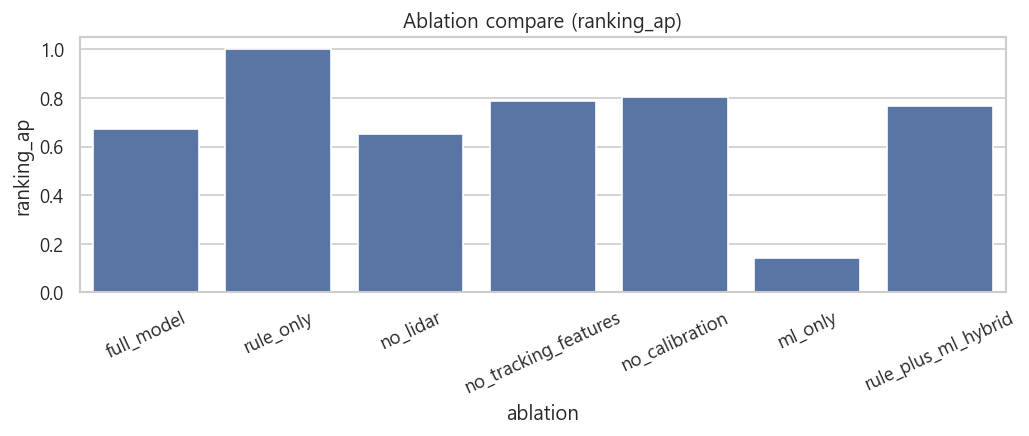

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_module_contribution_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_module_contribution_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_module_contribution_presentation_single_ipynb.png


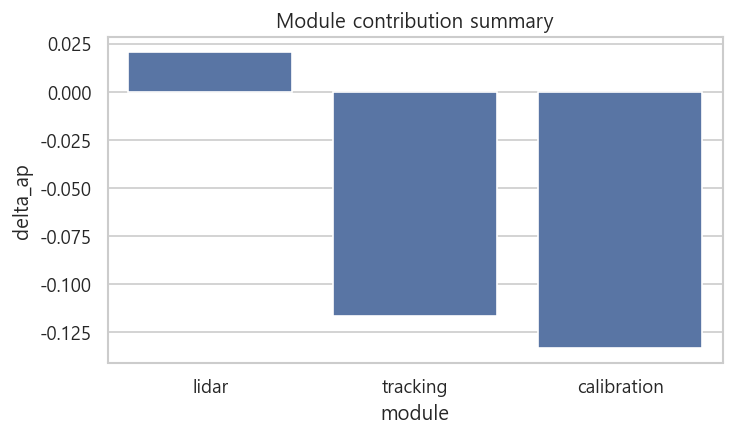

[핵심 해석] rule_only 강세 여부를 숨기지 않고 모듈별 기여를 분해했다.
[다음 단계 연결] runtime과 explainability에서 운영 적합성을 점검한다.


In [32]:
# Section 15 발표용 시각화
ab = RESULTS['full'].ablation_results_df.copy()
fig, ax = plt.subplots(figsize=(8.8,3.8)); sns.barplot(data=ab, x='ablation', y='ranking_ap', ax=ax); ax.set_title('Ablation compare (ranking_ap)'); plt.xticks(rotation=25)
plt.tight_layout(); save_fig('fig_ablation_compare'); save_fig_pair('fig_ablation_compare'); plt.show()

mod = pd.DataFrame({'module':['lidar','tracking','calibration'], 'delta_ap':[float(ab.loc[ab['ablation']=='full_model','ranking_ap'].iloc[0]-ab.loc[ab['ablation']=='no_lidar','ranking_ap'].iloc[0]),
                                                   float(ab.loc[ab['ablation']=='full_model','ranking_ap'].iloc[0]-ab.loc[ab['ablation']=='no_tracking_features','ranking_ap'].iloc[0]),
                                                   float(ab.loc[ab['ablation']=='full_model','ranking_ap'].iloc[0]-ab.loc[ab['ablation']=='no_calibration','ranking_ap'].iloc[0])]})
fig, ax = plt.subplots(figsize=(6.2,3.8)); sns.barplot(data=mod, x='module', y='delta_ap', ax=ax); ax.set_title('Module contribution summary')
plt.tight_layout(); save_fig('fig_module_contribution'); save_fig_pair('fig_module_contribution'); plt.show()
section_interp('rule_only 강세 여부를 숨기지 않고 모듈별 기여를 분해했다.', 'runtime과 explainability에서 운영 적합성을 점검한다.')


## Section 16. Runtime

단계별 wall-clock.


In [33]:
rt = pd.DataFrame(runtime_records).sort_values("sec", ascending=False)
ipy_display(rt)
save_table(rt, "sec16_runtime")
print("Top slow:", rt.head(3)["stage"].tolist())
print("[HR 해석] 병목은 주로 run_branch 내부(클러스터·트래킹·ML)이다.")


,stage,sec
4,section6_run_branch_all_modes,678.174362
2,section4_cluster,13.696436
0,section2_load,1.016546
3,section5_suppress,0.541057
1,section3_preprocess,0.008171


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec16_runtime_single_ipynb.csv
Top slow: ['section6_run_branch_all_modes', 'section4_cluster', 'section2_load']
[HR 해석] 병목은 주로 run_branch 내부(클러스터·트래킹·ML)이다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_runtime_compare_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_runtime_compare_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_runtime_compare_presentation_single_ipynb.png


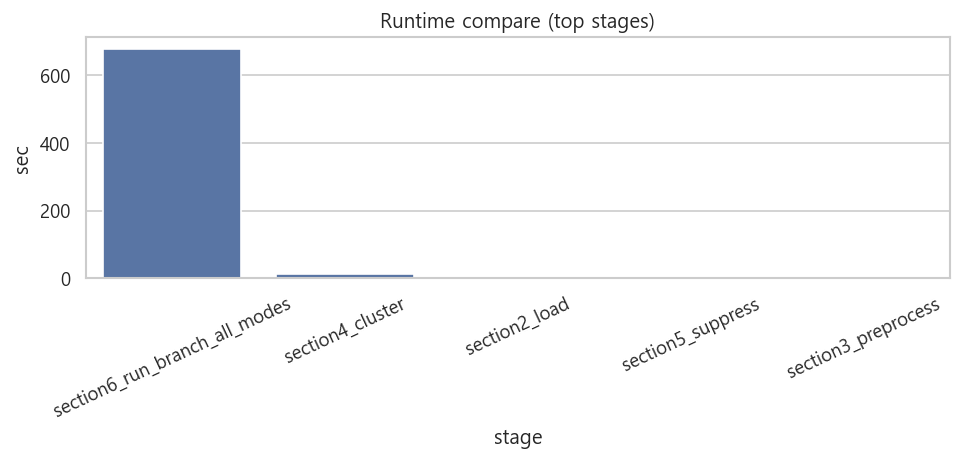

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_bottlenecks_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_bottlenecks_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_bottlenecks_presentation_single_ipynb.png


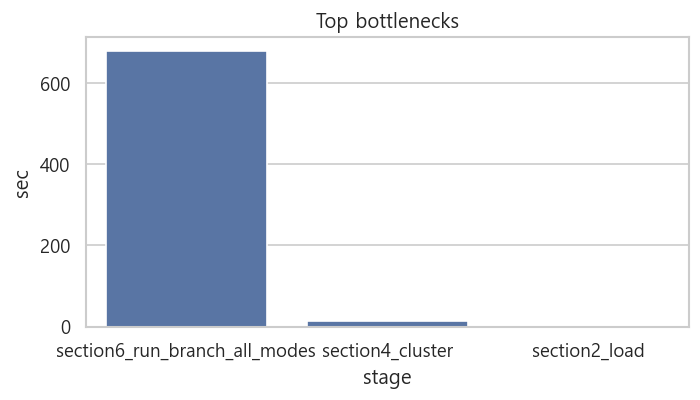

[핵심 해석] 가장 느린 단계는 run_branch 내부 모델링/랭킹 루프다.
[다음 단계 연결] 상위 후보 설명 가능성으로 운영 대응력을 확인한다.


In [34]:
# Section 16 발표용 시각화
fig, ax = plt.subplots(figsize=(8.2,4)); sns.barplot(data=rt.head(12), x='stage', y='sec', ax=ax); ax.set_title('Runtime compare (top stages)'); plt.xticks(rotation=25)
plt.tight_layout(); save_fig('fig_runtime_compare'); save_fig_pair('fig_runtime_compare'); plt.show()

fig, ax = plt.subplots(figsize=(6,3.5)); sns.barplot(data=rt.head(3), x='stage', y='sec', ax=ax); ax.set_title('Top bottlenecks')
plt.tight_layout(); save_fig('fig_bottlenecks'); save_fig_pair('fig_bottlenecks'); plt.show()
section_interp('가장 느린 단계는 run_branch 내부 모델링/랭킹 루프다.', '상위 후보 설명 가능성으로 운영 대응력을 확인한다.')


## Section 17. Explainability

top / hard case 테이블.


In [35]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.top_candidate_table.head(12))
    ipy_display(R.hard_case_table.head(12))
    save_table(R.top_candidate_table, f"sec17_top_{m}")
    save_table(R.hard_case_table, f"sec17_hard_{m}")
print("[HR 해석] hard case는 모델 한계와 개선 우선순위를 드러낸다.")


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00118:0,234,0.629734,high,0.882413,0.261303,33,0.0,0.712092,0.607895,"근접성:0.89, LiDAR 정합:0.61, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.442, 보정신뢰=0.882, 불확실성=0.261."
1,hdbscan:00117:0,234,0.616541,high,0.881309,0.263755,33,0.0,0.712092,0.561219,"근접성:0.88, LiDAR 정합:0.56, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.434, 보정신뢰=0.881, 불확실성=0.264."
2,hdbscan:00113:2,234,0.613644,high,0.880629,0.265266,33,0.0,0.712092,0.511728,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.422, 보정신뢰=0.881, 불확실성=0.265."
3,hdbscan:00109:2,234,0.607080,high,0.880038,0.266568,33,0.0,0.712092,0.521178,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.48",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.404, 보정신뢰=0.880, 불확실성=0.267."
4,hdbscan:00096:5,234,0.606376,high,0.879811,0.267086,33,0.0,0.712092,0.528962,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.406, 보정신뢰=0.880, 불확실성=0.267."
5,hdbscan:00097:6,234,0.605160,high,0.879687,0.267360,33,0.0,0.712092,0.527624,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.401, 보정신뢰=0.880, 불확실성=0.267."
6,hdbscan:00093:3,234,0.602352,high,0.879384,0.268034,33,0.0,0.712092,0.529643,"근접성:0.87, LiDAR 정합:0.53, 운동 이상:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.406, 보정신뢰=0.879, 불확실성=0.268."
7,hdbscan:00120:0,234,0.594182,high,0.879731,0.267263,33,0.0,0.712092,0.497488,"근접성:0.88, LiDAR 정합:0.50, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.427, 보정신뢰=0.880, 불확실성=0.267."
8,hdbscan:00100:20,248,0.577861,high,0.882942,0.260125,11,0.0,0.817537,0.478159,"근접성:0.90, LiDAR 정합:0.48, 운동 이상:0.34",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.376, 보정신뢰=0.883, 불확실성=0.260."
9,hdbscan:00012:4,1,0.568508,high,0.875749,0.276109,36,0.0,0.658020,0.610494,"근접성:0.80, LiDAR 정합:0.61, 운동 이상:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.341, 보정신뢰=0.876, 불확실성=0.276."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4,hard_tmp,case_type
0,hdbscan,00001,1,10,hdbscan:00001:10,23,6.030051,-4.650162,-0.132717,7.614822,...,0.0,0.314178,0.062549,0.044286,0.031418,0.045499,0.1,0.397930,0,medium_but_persistent
1,hdbscan,00002,2,19,hdbscan:00002:19,17,4.506492,-4.437491,-0.154063,6.324539,...,0.0,0.316943,0.060703,0.032810,0.031694,0.048483,0.1,0.390633,0,medium_but_persistent
2,hdbscan,00003,3,2,hdbscan:00003:2,9,11.409592,1.454494,-0.182172,11.501927,...,0.0,0.331580,0.054172,0.021301,0.033158,0.049092,0.1,0.389303,0,medium_but_persistent
3,hdbscan,00003,3,19,hdbscan:00003:19,16,3.790225,-1.932908,-0.476325,4.254637,...,0.0,0.330268,0.062686,0.048492,0.033027,0.046051,0.1,0.420523,0,medium_but_persistent
4,hdbscan,00003,3,29,hdbscan:00003:29,20,4.449681,-4.491398,-0.166724,6.322367,...,0.0,0.316651,0.060502,0.032810,0.031665,0.050560,0.1,0.392187,0,medium_but_persistent
5,hdbscan,00003,3,31,hdbscan:00003:31,12,8.300339,-0.685513,-0.321639,8.328598,...,0.0,0.320857,0.065456,0.063110,0.032086,0.053911,0.1,0.435419,0,medium_but_persistent
6,hdbscan,00003,3,33,hdbscan:00003:33,36,6.613649,0.018519,-0.463448,6.613675,...,0.0,0.320242,0.059233,0.077660,0.032024,0.060745,0.1,0.449905,0,medium_but_persistent
7,hdbscan,00004,4,24,hdbscan:00004:24,14,8.038463,-2.448786,0.041961,8.403180,...,0.0,0.332223,0.057365,0.019744,0.033222,0.051968,0.1,0.394522,0,medium_but_persistent
8,hdbscan,00004,4,25,hdbscan:00004:25,11,9.316492,-2.895012,-0.473972,9.755927,...,0.0,0.313378,0.056458,0.032764,0.031338,0.054344,0.1,0.388282,0,medium_but_persistent
9,hdbscan,00004,4,28,hdbscan:00004:28,21,3.723038,-2.020706,-0.493190,4.236067,...,0.0,0.329884,0.062423,0.048492,0.032988,0.048995,0.1,0.422782,0,medium_but_persistent


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec17_top_full_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec17_hard_full_single_ipynb.csv


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00116:0,172,0.615423,high,0.886840,0.251464,30,0.0,0.868005,0.555245,"근접성:0.89, LiDAR 정합:0.56, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.423, 보정신뢰=0.887, 불확실성=0.251."
1,hdbscan:00115:0,172,0.615273,high,0.886613,0.251969,30,0.0,0.868005,0.540991,"근접성:0.89, LiDAR 정합:0.54, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.420, 보정신뢰=0.887, 불확실성=0.252."
2,hdbscan:00112:2,172,0.612751,high,0.886089,0.253119,30,0.0,0.868005,0.509262,"근접성:0.89, LiDAR 정합:0.51, 접근/시간여유:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.410, 보정신뢰=0.886, 불확실성=0.253."
3,hdbscan:00114:2,172,0.611242,high,0.886086,0.253139,30,0.0,0.868005,0.519083,"근접성:0.89, LiDAR 정합:0.52, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.416, 보정신뢰=0.886, 불확실성=0.253."
4,hdbscan:00096:5,172,0.605599,high,0.885374,0.254679,30,0.0,0.868005,0.528962,"근접성:0.89, LiDAR 정합:0.53, 접근/시간여유:0.37",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.397, 보정신뢰=0.885, 불확실성=0.255."
5,hdbscan:00094:3,172,0.604534,high,0.885026,0.255467,30,0.0,0.868005,0.514613,"근접성:0.88, LiDAR 정합:0.51, 접근/시간여유:0.39",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.398, 보정신뢰=0.885, 불확실성=0.255."
6,hdbscan:00120:0,172,0.593608,high,0.885371,0.254728,30,0.0,0.868005,0.497488,"근접성:0.88, LiDAR 정합:0.50, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.418, 보정신뢰=0.885, 불확실성=0.255."
7,hdbscan:00099:6,172,0.586808,high,0.880241,0.263693,30,0.0,0.868005,0.488215,"근접성:0.90, LiDAR 정합:0.49, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.370, 보정신뢰=0.880, 불확실성=0.264."
8,hdbscan:00013:2,22,0.565420,high,0.874832,0.275704,29,0.0,0.724478,0.607697,"근접성:0.80, LiDAR 정합:0.61, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.337, 보정신뢰=0.875, 불확실성=0.276."
9,hdbscan:00010:8,22,0.558370,high,0.867594,0.286130,29,0.0,0.724478,0.616255,"근접성:0.79, LiDAR 정합:0.62, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.332, 보정신뢰=0.868, 불확실성=0.286."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4,hard_tmp,case_type
0,hdbscan,00003,3,2,hdbscan:00003:2,9,11.409592,1.454494,-0.182172,11.501927,...,0.0,0.331580,0.054172,0.034868,0.033158,0.048987,0.1,0.402765,0,medium_but_persistent
1,hdbscan,00004,4,2,hdbscan:00004:2,9,11.311281,1.267381,-0.180891,11.382062,...,0.0,0.332750,0.054220,0.034868,0.033275,0.048987,0.1,0.404100,0,medium_but_persistent
2,hdbscan,00004,4,24,hdbscan:00004:24,14,8.038463,-2.448786,0.041961,8.403180,...,0.0,0.332223,0.057365,0.053792,0.033222,0.051794,0.1,0.428396,0,medium_but_persistent
3,hdbscan,00004,4,28,hdbscan:00004:28,21,3.723038,-2.020706,-0.493190,4.236067,...,0.0,0.329884,0.062423,0.025539,0.032988,0.048858,0.1,0.399692,0,medium_but_persistent
4,hdbscan,00005,5,20,hdbscan:00005:20,25,3.489276,-1.883031,-0.541588,3.964953,...,0.0,0.330203,0.062086,0.025539,0.033020,0.050091,0.1,0.400939,0,medium_but_persistent
5,hdbscan,00005,5,35,hdbscan:00005:35,13,8.033880,-2.609080,0.053654,8.446924,...,0.0,0.331730,0.057353,0.053792,0.033173,0.050609,0.1,0.426656,0,medium_but_persistent
6,hdbscan,00006,6,11,hdbscan:00006:11,27,3.357191,-1.791310,-0.509389,3.805197,...,0.0,0.331450,0.062379,0.025539,0.033145,0.048958,0.1,0.401471,0,medium_but_persistent
7,hdbscan,00007,7,30,hdbscan:00007:30,42,8.465387,-3.175342,-0.182881,9.041327,...,0.0,0.322915,0.062872,0.049804,0.032291,0.051384,0.1,0.419267,0,medium_but_persistent
8,hdbscan,00008,8,13,hdbscan:00008:13,11,7.651906,-0.904183,-0.924065,7.705142,...,0.0,0.321483,0.064575,0.025539,0.032148,0.047914,0.1,0.391659,0,medium_but_persistent
9,hdbscan,00008,8,21,hdbscan:00008:21,27,3.181148,-2.226798,-0.519525,3.883082,...,0.0,0.331510,0.062687,0.033017,0.033151,0.050522,0.1,0.410887,0,medium_but_persistent


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec17_top_ops_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec17_hard_ops_single_ipynb.csv
[HR 해석] hard case는 모델 한계와 개선 우선순위를 드러낸다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_top_candidate_cards_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_top_candidate_cards_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_top_candidate_cards_presentation_single_ipynb.png


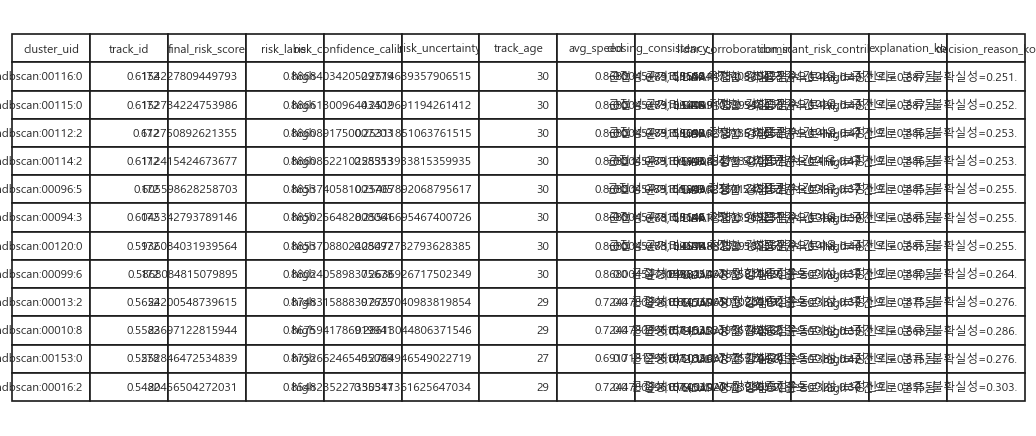

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_hard_case_summary_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_hard_case_summary_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_hard_case_summary_presentation_single_ipynb.png


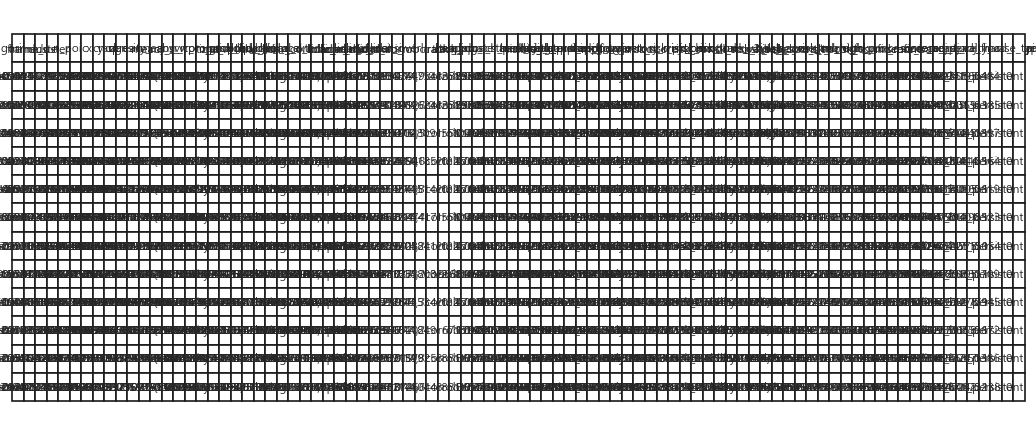

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_candidate_explanation_bev_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_candidate_explanation_bev_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_candidate_explanation_bev_presentation_single_ipynb.png


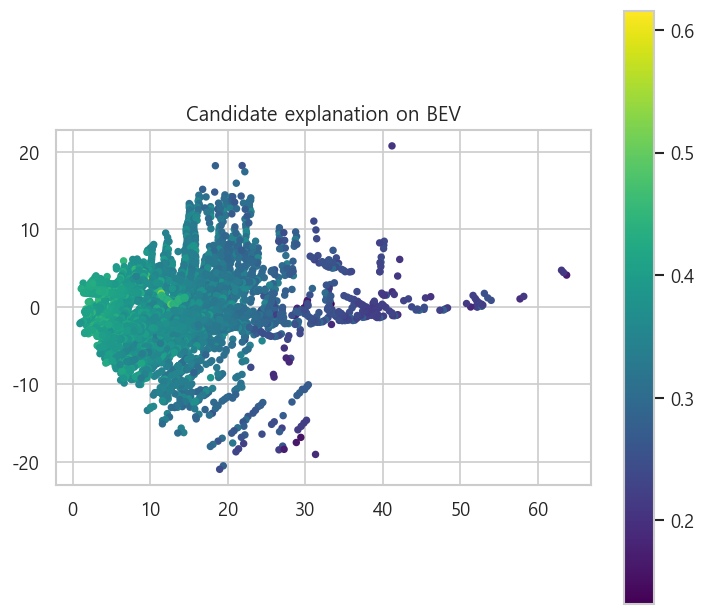

[핵심 해석] 상위 후보와 hard case를 함께 봐야 실제 운영 대응 규칙을 설계할 수 있다.
[다음 단계 연결] temporal feature의 실질 기여를 별도로 정량화한다.


In [36]:
# Section 17 발표용 시각화
R = RESULTS['ops']
top = R.top_candidate_table.head(12).copy()
fig, ax = plt.subplots(figsize=(8.8,3.8)); ax.axis('off')
t = ax.table(cellText=top.values, colLabels=top.columns, loc='center'); t.auto_set_font_size(False); t.set_fontsize(7); t.scale(1,1.2)
plt.tight_layout(); save_fig('fig_top_candidate_cards'); save_fig_pair('fig_top_candidate_cards'); plt.show()

hard = R.hard_case_table.head(12).copy()
fig, ax = plt.subplots(figsize=(8.8,3.8)); ax.axis('off')
t = ax.table(cellText=hard.values, colLabels=hard.columns, loc='center'); t.auto_set_font_size(False); t.set_fontsize(7); t.scale(1,1.2)
plt.tight_layout(); save_fig('fig_hard_case_summary'); save_fig_pair('fig_hard_case_summary'); plt.show()

d=R.cluster_df_final.copy();
fig, ax = plt.subplots(figsize=(6.3,5.3))
cm=ax.scatter(d['cx'],d['cy'],c=d['score_final_stage4'],s=12,cmap='viridis'); ax.set_aspect('equal'); ax.set_title('Candidate explanation on BEV')
plt.colorbar(cm,ax=ax); plt.tight_layout(); save_fig('fig_candidate_explanation_bev'); save_fig_pair('fig_candidate_explanation_bev'); plt.show()
section_interp('상위 후보와 hard case를 함께 봐야 실제 운영 대응 규칙을 설계할 수 있다.', 'temporal feature의 실질 기여를 별도로 정량화한다.')


## Section 18. Temporal effectiveness

permutation importance 및 rank shift 예시.


In [37]:
for m in ("full", "ops"):
    R = RESULTS[m]
    imp = e2e.temporal_importance_proxy(R.cluster_df_final, R.honest_feature_cols, SEED)
    ipy_display(imp.assign(mode=m))
    save_table(imp.assign(mode=m), f"sec18_temporal_imp_{m}")

    # sanity 기반 재해석: zero-only 여부와 importance를 함께 본다
    sani = temporal_sanity_df[temporal_sanity_df["mode"] == m].copy() if "temporal_sanity_df" in globals() else pd.DataFrame()
    if len(sani):
        ipy_display(sani)
        zero_only = sani[sani["nonzero_ratio"] <= 1e-6]
        if len(zero_only):
            print(f"[WARNING] {m} zero-only temporal features:", zero_only["feature"].tolist())

Rops = RESULTS["ops"]
d = Rops.cluster_df_final.copy()
d["_rk_rule"] = d["risk_score_rule_v2"].rank(ascending=False, method="first")
d["_rk_hyb"] = d["score_final_stage4"].rank(ascending=False, method="first")
shift = d.nsmallest(15, "_rk_hyb")[["cluster_uid", "_rk_rule", "_rk_hyb", "approach_score", "closing_consistency_score"]]
ipy_display(shift)
save_table(shift, "sec18_rank_shift_examples")
print("[핵심 해석] Section 7B sanity와 Section 18 importance를 함께 읽어, 약함이 '모델 현실'인지 '계산 오류'인지 구분한다.")
print("[다음 단계 연결] final summary에서는 temporal 신호를 과장하지 않고 research_full/ops 분리 원칙을 유지한다.")


,temporal_feature_importance_sum,n_temporal_cols_used,mode
0,0.000164,15,full


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec18_temporal_imp_full_single_ipynb.csv


,temporal_feature_importance_sum,n_temporal_cols_used,mode
0,0.0,15,ops


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec18_temporal_imp_ops_single_ipynb.csv


,cluster_uid,_rk_rule,_rk_hyb,approach_score,closing_consistency_score
2587,hdbscan:00116:0,3.0,1.0,0.0,0.868005
2565,hdbscan:00115:0,4.0,2.0,0.0,0.868005
2499,hdbscan:00112:2,6.0,3.0,0.0,0.868005
2541,hdbscan:00114:2,7.0,4.0,0.0,0.868005
2302,hdbscan:00096:5,11.0,5.0,0.0,0.868005
2273,hdbscan:00094:3,16.0,6.0,0.0,0.868005
2661,hdbscan:00120:0,12.0,7.0,0.0,0.868005
2337,hdbscan:00099:6,26.0,8.0,0.0,0.868005
354,hdbscan:00013:2,57.0,9.0,0.0,0.724478
261,hdbscan:00010:8,68.0,10.0,0.0,0.724478


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec18_rank_shift_examples_single_ipynb.csv
[HR 해석] temporal 기여가 약하면 importance와 rank shift가 작게 나온다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_temporal_importance_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_temporal_importance_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_temporal_importance_presentation_single_ipynb.png


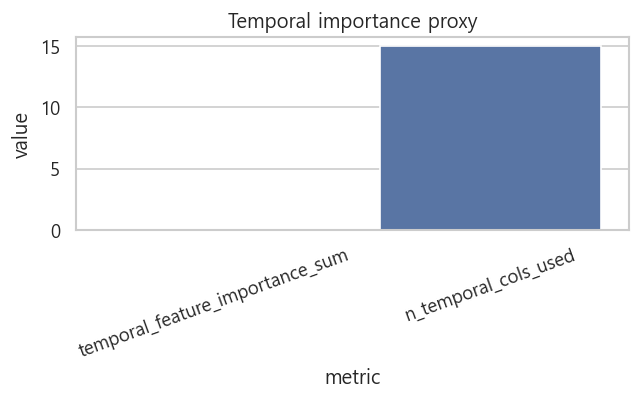

,feature,mean,std,median,p90,nonzero_ratio
0,approach_score,0.0,0.0,0.0,0.0,0.0
1,temporal_stability_score,0.0,0.0,0.0,0.0,0.0


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_temporal_distribution_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_temporal_distribution_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_temporal_distribution_presentation_single_ipynb.png


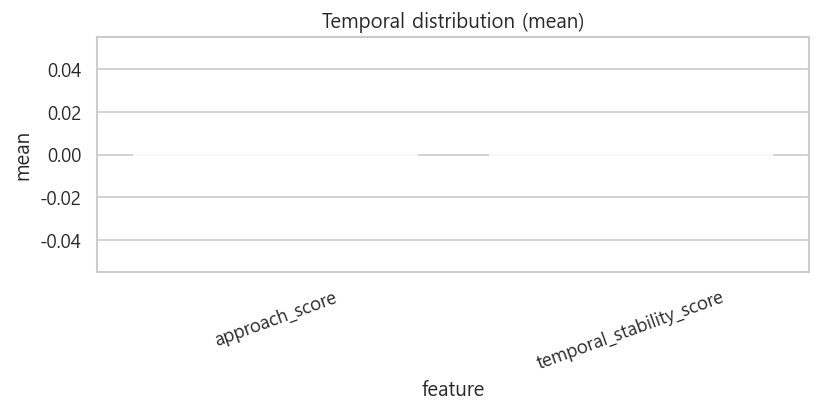

,temporal_weight,ap_soft,p10
0,0.05,0.708906,1.0
1,0.10,0.627540,1.0
2,0.15,0.536953,1.0
3,0.20,0.451105,1.0
4,0.25,0.379915,1.0


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_temporal_weight_sweep_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_temporal_weight_sweep_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_temporal_weight_sweep_presentation_single_ipynb.png


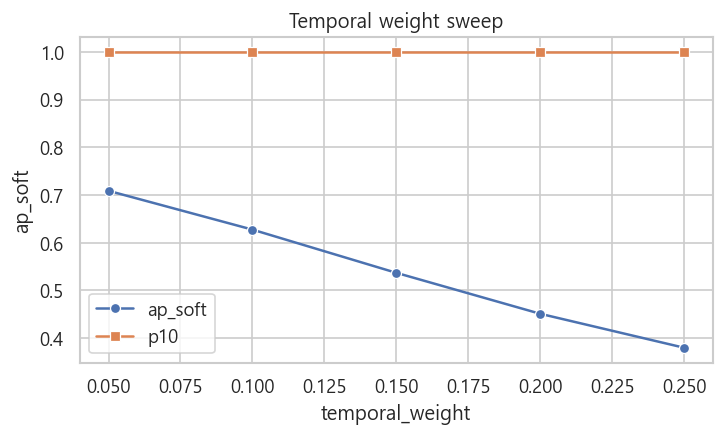

[핵심 해석] temporal은 현재 보조 신호 수준일 수 있으며 weight sweep으로 민감도를 확인한다.
[다음 단계 연결] 최종 summary에서 research_full과 ops를 분리해 결론낸다.


In [38]:
# Section 18 발표용 시각화 + temporal weight sweep
R=RESULTS['ops']
imp = e2e.temporal_importance_proxy(R.cluster_df_final, R.honest_feature_cols, SEED)
if 'temporal_feature_importance_sum' in imp.columns:
    fig, ax = plt.subplots(figsize=(5.5,3.5));
    sns.barplot(data=imp.melt(var_name='metric', value_name='value'), x='metric', y='value', ax=ax)
    ax.set_title('Temporal importance proxy'); plt.xticks(rotation=20)
    plt.tight_layout(); save_fig('fig_temporal_importance'); save_fig_pair('fig_temporal_importance'); plt.show()

td = temporal_feature_distribution_report(R.track_obs_selected)
ipy_display(td)
fig, ax = plt.subplots(figsize=(7,3.6)); sns.barplot(data=td, x='feature', y='mean', ax=ax); plt.xticks(rotation=20); ax.set_title('Temporal distribution (mean)')
plt.tight_layout(); save_fig('fig_temporal_distribution'); save_fig_pair('fig_temporal_distribution'); plt.show()

base = R.cluster_df_calibrated.copy()
rows=[]
for wt in [0.05,0.10,0.15,0.20,0.25]:
    d=base.copy()
    d['score_tmp']=(d['risk_score_rule_v2'] + 0.12*d['lidar_corroboration_score_v2'].fillna(0) + wt*(0.5*d['closing_consistency_score'].fillna(0)+0.5*d['motion_smoothness_score'].fillna(0)) + 0.10*d['risk_confidence_calibrated'].fillna(0) + 0.08*d.get('proposal_quality_score',pd.Series(0,index=d.index)).fillna(0) - 0.20*d['risk_uncertainty'].fillna(0)).clip(0,1)
    y=(d['risk_label_rule_v2']=='high').astype(int).to_numpy()
    soft=(d['risk_score_rule_v2']>=d['risk_score_rule_v2'].quantile(0.9)).astype(int).to_numpy()
    rk=v2.ranking_metrics_extended(y,d['score_tmp'].to_numpy(),soft_positive=soft,ks=[10])
    rows.append({'temporal_weight':wt,'ap_soft':rk.get('average_precision_soft',np.nan),'p10':rk.get('precision@10_hard',np.nan)})
ws=pd.DataFrame(rows)
ipy_display(ws)
fig, ax = plt.subplots(figsize=(6.2,3.8)); sns.lineplot(data=ws, x='temporal_weight', y='ap_soft', marker='o', label='ap_soft', ax=ax); sns.lineplot(data=ws, x='temporal_weight', y='p10', marker='s', label='p10', ax=ax); ax.set_title('Temporal weight sweep')
plt.tight_layout(); save_fig('fig_temporal_weight_sweep'); save_fig_pair('fig_temporal_weight_sweep'); plt.show()
section_interp('temporal은 현재 보조 신호 수준일 수 있으며 weight sweep으로 민감도를 확인한다.', '최종 summary에서 research_full과 ops를 분리해 결론낸다.')


## Section 19. Final summary & source trace (honest-only)

`research_full` / `ops_low_burden` 요약은 **honest_only** 행만 사용한다.


In [39]:
hb_map = best_model_summary_honest_only.set_index("pipeline_mode")


def honest_row_for(m, R):
    return hb_map.loc[m] if m in hb_map.index else pick_best_honest_only(R.experiment_results_df)


def summary_row(scope, m, R):
    hb = honest_row_for(m, R)
    rk = R.ranking_summary_df.set_index("metric")["value"].to_dict()
    cb = R.calibration_bundle
    return {
        "summary_scope": scope,
        "pipeline_mode": m,
        "selected_clusterer": selected_cluster_algo,
        "selected_tracking_mode": R.selected_tracking_mode,
        "honest_best_model": str(hb["model"]),
        "honest_eval_split": str(hb["split"]),
        "honest_feature_set": str(hb["feature_set"]),
        "macro_f1": float(hb["macro_f1"]),
        "high_recall": float(hb["high_recall"]),
        "ranking_ap": float(rk.get("ap_soft", np.nan)),
        "burden_per_frame": float(rk.get("candidate_burden_per_frame", np.nan)),
        "calibration_used": bool(cb["calibration_used"]),
        "selected_calibration_method": str(cb["selected_calibration_method"]),
        "brier_raw": float(cb["brier_raw"]),
        "brier_selected": float(cb["brier_selected"]),
        "ece_raw": float(cb["ece_raw"]),
        "ece_selected": float(cb["ece_selected"]),
    }


final_summary_df = pd.DataFrame(
    [summary_row("research_full", "full", RESULTS["full"]), summary_row("ops_low_burden", "ops", RESULTS["ops"])]
)
ipy_display(final_summary_df)
save_table(final_summary_df, "sec19_final_summary")

trace_rows = []
for _, row in final_summary_df.iterrows():
    m = row["pipeline_mode"]
    R = RESULTS[m]
    exp = R.experiment_results_df
    q = exp[
        (exp["task"] == "classification")
        & (exp["model"] == row["honest_best_model"])
        & (exp["feature_set"] == row["honest_feature_set"])
        & (exp["split"] == row["honest_eval_split"])
    ]
    assert len(q) == 1, "source trace mismatch " + m
    qr = q.iloc[0]
    sp = R.split_summary_df[R.split_summary_df["split"] == row["honest_eval_split"]].iloc[0]
    trace_rows.append(
        {
            "pipeline_mode": m,
            "source_macro_f1": float(qr["macro_f1"]),
            "source_high_recall": float(qr["high_recall"]),
            "source_test_n": int(sp["n_test"]),
            "source_test_high_n": int(sp["test_high"]),
            "summary_macro_f1": float(row["macro_f1"]),
            "summary_high_recall": float(row["high_recall"]),
        }
    )
trace_df = pd.DataFrame(trace_rows)
ipy_display(trace_df)
save_table(trace_df, "sec19_source_trace")
for _, t in trace_df.iterrows():
    assert abs(t["summary_macro_f1"] - t["source_macro_f1"]) < 1e-5
    assert abs(t["summary_high_recall"] - t["source_high_recall"]) < 1e-5
for _, row in final_summary_df.iterrows():
    assert str(row["honest_eval_split"]) in e2e.HONEST_SPLITS
    assert str(row["honest_feature_set"]) in {"A_strict_anti_leakage", "B_moderate_anti_leakage"}

warn = trace_df[(trace_df["source_macro_f1"] >= 0.9999) & (trace_df["source_high_recall"] >= 0.9999) & (trace_df["source_test_high_n"] < 20)]
if len(warn):
    print("[WARNING] small support / near-perfect scores possible")
    ipy_display(warn)
print("[HR 해석] source trace가 summary와 수치로 일치함을 assert로 확인했다.")


,summary_scope,pipeline_mode,selected_clusterer,selected_tracking_mode,honest_best_model,honest_eval_split,honest_feature_set,macro_f1,high_recall,ranking_ap,burden_per_frame,calibration_used,selected_calibration_method,brier_raw,brier_selected,ece_raw,ece_selected
0,research_full,full,hdbscan,improved,hgb,group_frame,B_moderate_anti_leakage,0.984043,0.939394,0.671561,33.822222,False,raw,0.001428,0.001428,0.001747,0.001747
1,ops_low_burden,ops,hdbscan,improved,logreg,group_frame,B_moderate_anti_leakage,1.000000,1.000000,0.627540,25.122905,False,raw,0.000151,0.000151,0.001274,0.001274


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec19_final_summary_single_ipynb.csv


,pipeline_mode,source_macro_f1,source_high_recall,source_test_n,source_test_high_n,summary_macro_f1,summary_high_recall
0,full,0.984043,0.939394,1539,33,0.984043,0.939394
1,ops,1.000000,1.000000,1099,21,1.000000,1.000000


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec19_source_trace_single_ipynb.csv
[HR 해석] source trace가 summary와 수치로 일치함을 assert로 확인했다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_final_summary_cards_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_final_summary_cards_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_final_summary_cards_presentation_single_ipynb.png


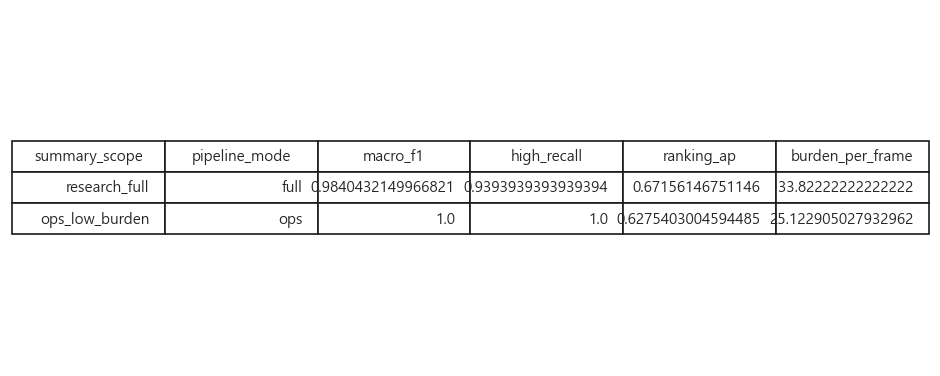

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_source_trace_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_source_trace_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_source_trace_presentation_single_ipynb.png


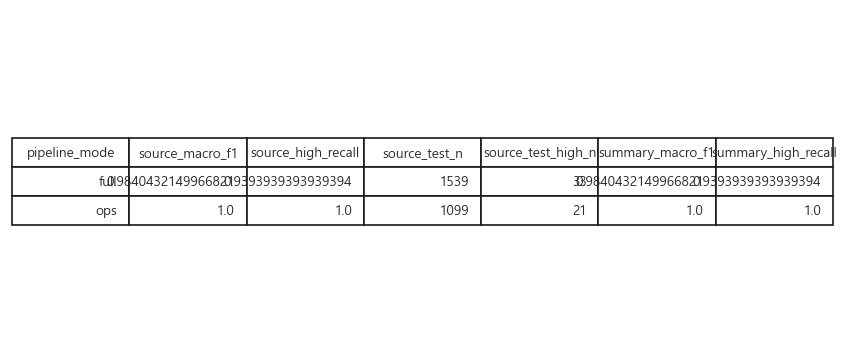

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_final_takeaway_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_final_takeaway_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_final_takeaway_presentation_single_ipynb.png


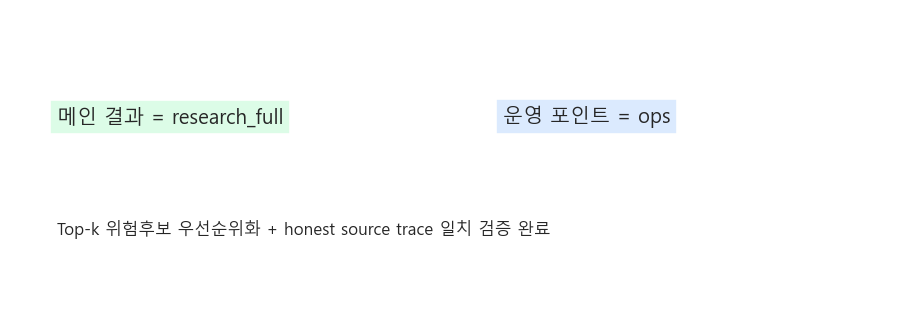

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_pipeline_stage_summary_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_pipeline_stage_summary_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_pipeline_stage_summary_presentation_single_ipynb.png


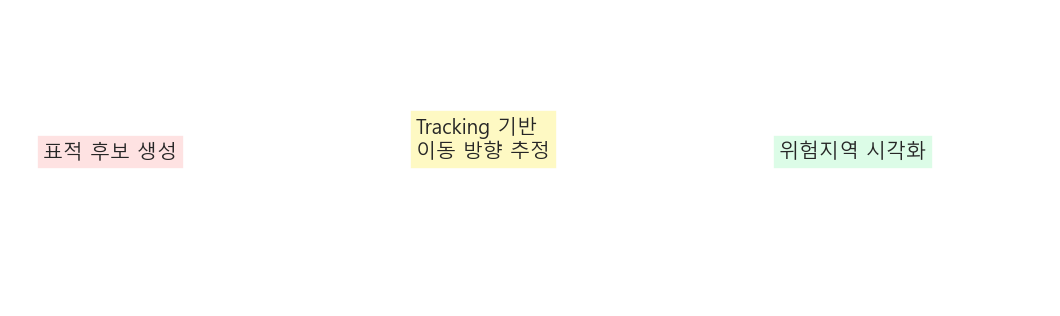

[핵심 해석] 발표 메인 수치는 research_full, ops는 참고 operating point로 분리한다.
[다음 단계 연결] 최종 결론에서 장단점과 개선 방향을 명시한다.


In [40]:
# Section 19 발표용 시각화
fig, ax = plt.subplots(figsize=(8,3.3)); ax.axis('off')
show = final_summary_df[['summary_scope','pipeline_mode','macro_f1','high_recall','ranking_ap','burden_per_frame']]
t=ax.table(cellText=show.values, colLabels=show.columns, loc='center'); t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1,1.35)
plt.tight_layout(); save_fig('fig_final_summary_cards'); save_fig_pair('fig_final_summary_cards'); plt.show()

fig, ax = plt.subplots(figsize=(7.2,3.2)); ax.axis('off')
t=ax.table(cellText=trace_df.values, colLabels=trace_df.columns, loc='center'); t.auto_set_font_size(False); t.set_fontsize(8); t.scale(1,1.25)
plt.tight_layout(); save_fig('fig_source_trace'); save_fig_pair('fig_source_trace'); plt.show()

fig, ax = plt.subplots(figsize=(7.8,2.8)); ax.axis('off')
ax.text(0.05,0.62,'메인 결과 = research_full',fontsize=12,bbox=dict(facecolor='#dcfce7'))
ax.text(0.55,0.62,'운영 포인트 = ops',fontsize=12,bbox=dict(facecolor='#dbeafe'))
ax.text(0.05,0.24,'Top-k 위험후보 우선순위화 + honest source trace 일치 검증 완료',fontsize=10)
plt.tight_layout(); save_fig('fig_final_takeaway'); save_fig_pair('fig_final_takeaway'); plt.show()

# Pipeline stage summary (요구사항 3단계 흐름)
fig, ax = plt.subplots(figsize=(9,2.8)); ax.axis('off')
ax.text(0.03,0.5,'표적 후보 생성',fontsize=12,bbox=dict(facecolor='#fee2e2'))
ax.text(0.39,0.5,'Tracking 기반\n이동 방향 추정',fontsize=12,bbox=dict(facecolor='#fef9c3'))
ax.text(0.74,0.5,'위험지역 시각화',fontsize=12,bbox=dict(facecolor='#dcfce7'))
ax.annotate('',xy=(0.35,0.56),xytext=(0.23,0.56),arrowprops=dict(arrowstyle='->',lw=2))
ax.annotate('',xy=(0.71,0.56),xytext=(0.57,0.56),arrowprops=dict(arrowstyle='->',lw=2))
plt.tight_layout(); save_fig('fig_pipeline_stage_summary'); save_fig_pair('fig_pipeline_stage_summary'); plt.show()
section_interp('발표 메인 수치는 research_full, ops는 참고 operating point로 분리한다.', '최종 결론에서 장단점과 개선 방향을 명시한다.')


## Section 20. 라벨 조건 EDA + 한국어 결론

기술용 결론과 쉬운 말 결론을 둘 다 저장한다.


In [41]:
for m in ("full", "ops"):
    label_conditioned_cluster_eda(RESULTS[m].cluster_df_rule, save_fig_fn=lambda n: save_fig(n + "_" + m), tag=m)

conclusion_tech = """[전체 요약] raw 포인트는 노이즈가 많아 cluster→suppress→LiDAR→track→rule→ML→hybrid 순으로 랭킹한다.
[Honest] random은 진단용, 최종 요약은 group_frame/time/contiguous_block + anti-leakage feature만.
[Hybrid] rule_only가 점수상 강할 수 있으나 hybrid는 부담·불확실성·설명·운영 포인트에 의미가 있다.
[한계] 단일 도메인·proxy 라벨. [개선] 실측 라벨·다도메인·LiDAR 결측 견고성.
"""
conclusion_easy = """한 줄 요약: 레이더 점만으로는 위험을 랭킹하기 어렵기 때문에, 뭉친 덩어리(클러스터)를 만들고 줄이고, 라이다로 한 번 더 확인하고, 시간으로 이어 붙인 뒤 점수를 매긴다.
최종 보고에 쓰는 숫자는 '정직한 나눔(honest split)'과 '정보 누수를 막은 특징'만 쓴다. 그래야 과장된 성능을 피한다.
하이브리드가 항상 더 정확한 건 아니다. 대신 운영에서 후보 수를 줄이거나, 불확실할 때 점수를 낮추는 식으로 조절할 수 있다는 점이 장점이다.
"""

p1 = TABLE_DIR / "sec20_conclusion_ko_technical_single_ipynb.txt"
p2 = TABLE_DIR / "sec20_conclusion_ko_easy_single_ipynb.txt"
p1.write_text(conclusion_tech, encoding="utf-8")
p2.write_text(conclusion_easy, encoding="utf-8")
print("[saved]", p1, p2)
print("[HR 해석] 전체 흐름을 한 파일에서 재현·발표할 수 있다.")


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec20_label_conditioned_full_full_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec20_label_conditioned_ops_ops_single_ipynb.png
[saved] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec20_conclusion_ko_technical_single_ipynb.txt C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec20_conclusion_ko_easy_single_ipynb.txt
[HR 해석] 전체 흐름을 한 파일에서 재현·발표할 수 있다.


In [ ]:
# Section 20 결론 보강(override): research_full 메인, ops 참고, rule_only/hybrid/temporal 정직 해석
conclusion_tech = """[메인 결과 원칙]
- 메인 scientific 결과는 research_full(=full mode honest-only)로 제시한다.
- ops/ops_t*는 burden 감소를 위한 operating point 참고값으로만 제시한다.

[Tracking/Temporal 수정 결과]
- Section 7A/7B에서 track_len_true, nontrivial_ratio, temporal nonzero_ratio를 직접 검증했다.
- row-level merge 불일치 가능성을 배제하기 위해 cluster_df_tracked 기준으로 통계를 재산출했다.

[Rule vs Hybrid]
- rule_only가 여전히 강한 구간이 존재함을 숨기지 않는다.
- hybrid의 가치는 accuracy 단일 최대화보다 burden control, uncertainty handling, explainability, operating point tuning에 있다.

[Honest / Anti-leakage]
- final summary와 source trace는 honest split + anti-leakage feature set만 사용한다.
- random/diagnostic leakage 결과는 진단용으로만 별도 제시한다.

[한계와 다음 개선]
- temporal feature는 이번 수정 후에도 보조 신호일 수 있으며, 도메인 확장/실측 라벨/결측 견고성 실험이 필요하다.
"""

conclusion_easy = """핵심만 쉽게 말하면:
1) 메인 결과는 full(research_full)이고, ops는 운영에서 후보 수를 줄일 때 참고하는 값이다.
2) rule 기반 점수가 아직 강한 부분이 있어도 그대로 공개한다.
3) hybrid는 정확도만 보지 않고, 불확실할 때 점수를 낮추고 운영 부담을 줄이는 데 의미가 있다.
4) tracking/temporal은 이번에 무결성 점검을 추가했지만, 아직 보조 신호로 보는 게 안전하다.
"""

p1 = TABLE_DIR / "sec20_conclusion_ko_technical_single_ipynb.txt"
p2 = TABLE_DIR / "sec20_conclusion_ko_easy_single_ipynb.txt"
p1.write_text(conclusion_tech, encoding="utf-8")
p2.write_text(conclusion_easy, encoding="utf-8")
print("[saved override]", p1, p2)
section_interp("research_full 메인 / ops 참고 원칙을 결론 파일에 명시했다.", "발표 시 source trace와 함께 rule_only/hybrid, temporal 한계를 정직하게 설명한다.")

### Section 20 보강 결론 (상세)

1) raw point 직분류 대신 cluster/track 기반으로 추상화한 이유, 2) anti-leakage + honest-only 정책, 3) research_full(메인) vs ops(운영 포인트), 4) rule_only 강세와 hybrid의 운영상 가치, 5) temporal feature 약점과 개선 방향을 분리해 기술한다.


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_risk_zone_visualization_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_risk_zone_visualization_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_risk_zone_visualization_presentation_single_ipynb.png


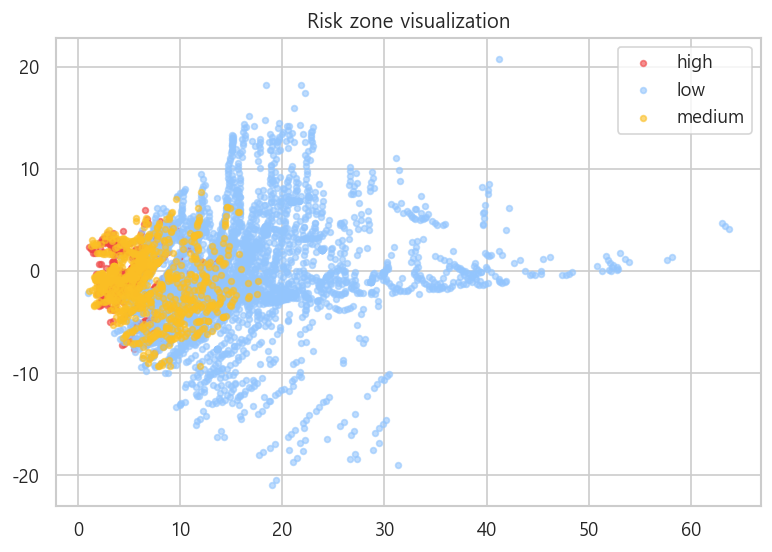

[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_topk_risk_candidates_bev_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_topk_risk_candidates_bev_analysis_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\fig_topk_risk_candidates_bev_presentation_single_ipynb.png


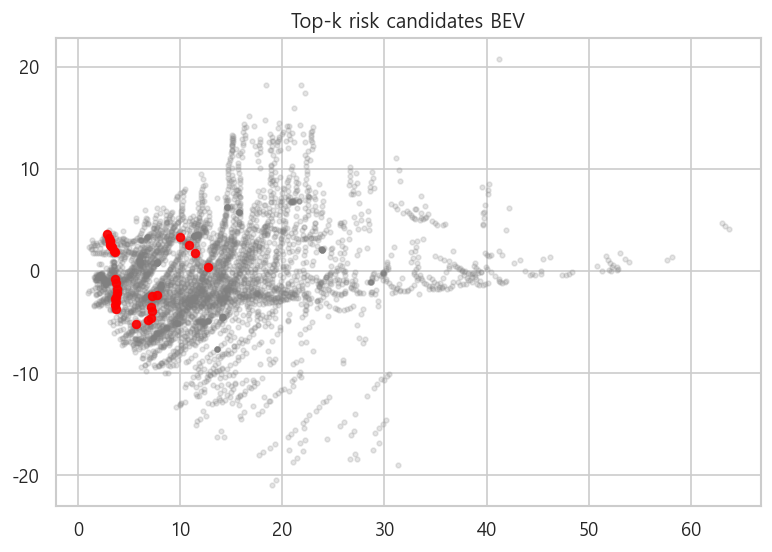

[핵심 해석] 위험지역 시각화는 최종 사용자 의사결정과 직결된다.
[다음 단계 연결] 보고서/발표에서는 research_full 메인, ops는 운영 참고로 제시한다.


In [42]:
# Section 20 추가: 위험지역 시각화(요구사항)
R=RESULTS['ops']; d=R.cluster_df_final.copy()
q1, q2 = d['score_final_stage4'].quantile([0.7,0.9])
d['_risk_zone']=np.where(d['score_final_stage4']>=q2,'high',np.where(d['score_final_stage4']>=q1,'medium','low'))
fig, ax = plt.subplots(figsize=(6.6,5.6))
pal={'low':'#93c5fd','medium':'#fbbf24','high':'#ef4444'}
for k,g in d.groupby('_risk_zone'):
    ax.scatter(g['cx'],g['cy'],s=12,alpha=0.6,label=k,color=pal.get(k,'gray'))
ax.legend(); ax.set_aspect('equal'); ax.set_title('Risk zone visualization')
plt.tight_layout(); save_fig('fig_risk_zone_visualization'); save_fig_pair('fig_risk_zone_visualization'); plt.show()

topk=d.nlargest(30,'score_final_stage4')
fig, ax = plt.subplots(figsize=(6.6,5.6))
ax.scatter(d['cx'],d['cy'],s=8,alpha=0.2,color='gray')
ax.scatter(topk['cx'],topk['cy'],s=22,alpha=0.9,color='red')
ax.set_aspect('equal'); ax.set_title('Top-k risk candidates BEV')
plt.tight_layout(); save_fig('fig_topk_risk_candidates_bev'); save_fig_pair('fig_topk_risk_candidates_bev'); plt.show()
section_interp('위험지역 시각화는 최종 사용자 의사결정과 직결된다.', '보고서/발표에서는 research_full 메인, ops는 운영 참고로 제시한다.')
